# Etapas

## Importações de libs e leitura dos dados

In [ ]:
!pip install pandas-ta

In [ ]:
# Load libraries
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pandas_ta as ta
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

#Libraries for Deep Learning Models
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from keras.layers import LSTM

#Libraries for Statistical Models
import statsmodels.api as sm

# Time series Models
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Error Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Feature Selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_regression

#Plotting
from pandas.plotting import scatter_matrix
from statsmodels.graphics.tsaplots import plot_acf

In [ ]:
import warnings
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore")

## Carregando os dados

In [ ]:
# Fonte dos dados: Investing

df = pd.read_csv('https://raw.githubusercontent.com/rodolfohgc/tech-challenge-pos-tech/refs/heads/main/base-1995-2025.csv', decimal=',', thousands='.', dtype={'Data': str})

In [ ]:
df.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,07.11.2025,154064,153339,154066,152368,"9,47B","0,47%"
1,06.11.2025,153339,153297,154352,153235,"9,39B","0,03%"
2,05.11.2025,153294,150709,153583,150296,"9,80B","1,72%"
3,04.11.2025,150704,150453,150888,149979,"7,54B","0,17%"
4,03.11.2025,150454,149551,150761,149551,"7,67B","0,61%"


## Análise exploratória dos dados

In [ ]:
df.shape

(7435, 7)

In [ ]:
df.describe()

,Último,Abertura,Máxima,Mínima
count,7435.000000,7435.000000,7435.000000,7435.000000
mean,55859.203093,55840.246268,56381.860121,55311.382650
std,38739.448602,38726.624138,39001.055445,38467.405586
min,3787.000000,3787.000000,3843.000000,3714.000000
25%,17089.000000,17088.000000,17343.000000,16883.000000
50%,53452.000000,53446.000000,54053.000000,52887.000000
75%,78480.000000,78328.500000,79405.000000,77499.500000
max,154064.000000,153339.000000,154352.000000,153235.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7435 entries, 0 to 7434
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Data      7435 non-null   object
 1   Último    7435 non-null   int64 
 2   Abertura  7435 non-null   int64 
 3   Máxima    7435 non-null   int64 
 4   Mínima    7435 non-null   int64 
 5   Vol.      7434 non-null   object
 6   Var%      7435 non-null   object
dtypes: int64(4), object(3)
memory usage: 406.7+ KB


Temos 3 colunas com o Dtype object. Não usaremos Vol e Var, então vamos lidar com a data nos próximos passos

## Verificação de nulidades

In [ ]:
df.isnull().sum()

,0
Data,0
Último,0
Abertura,0
Máxima,0
Mínima,0
Vol.,1
Var%,0


Como a única célula nula está na coluna de Volume, a qual não será utilizada no modelo, posso ignorar, pois depois descartarei a coluna

# Preparação dos dados
## Tratamentos de dados

In [ ]:
df = df.rename(columns={'Data': 'date', 'Último': 'close', 'Abertura': 'open', 'Máxima': 'high', 'Mínima': 'low'})

In [ ]:
df.index = pd.to_datetime(df['date'], format='%d.%m.%Y')
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7435 entries, 2025-11-07 to 1995-11-08
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    7435 non-null   object
 1   close   7435 non-null   int64 
 2   open    7435 non-null   int64 
 3   high    7435 non-null   int64 
 4   low     7435 non-null   int64 
 5   Vol.    7434 non-null   object
 6   Var%    7435 non-null   object
dtypes: int64(4), object(3)
memory usage: 464.7+ KB


In [ ]:
df.drop("Vol.", axis=1, inplace=True)
df.drop("Var%", axis=1, inplace=True)
df.drop("date", axis=1, inplace=True)

## Ordenação cronológica para timeseries

In [ ]:
df.sort_index(ascending=True, inplace=True)
df.head()

,close,open,high,low
date,,,,
1995-11-08,4117,4111,4173,4051
1995-11-09,4113,4117,4158,4072
1995-11-10,3958,4113,4126,3931
1995-11-13,3787,3953,3953,3760
1995-11-14,3797,3787,3843,3714


## Gráfico do fechamento

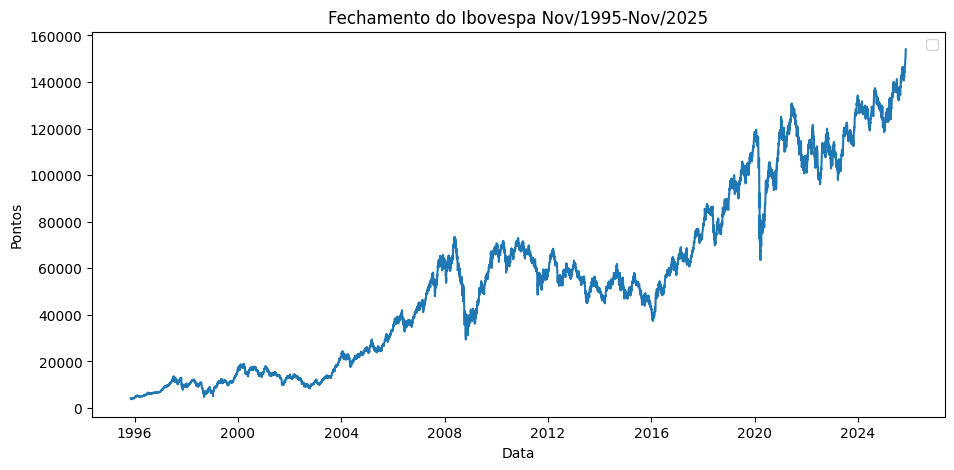

In [ ]:
# Visualização dos dados
plt.figure(figsize=(11, 5))
plt.plot(df.index, df["close"],)
plt.title("Fechamento do Ibovespa Nov/1995-Nov/2025")
plt.xlabel("Data")
plt.ylabel("Pontos")
plt.legend()
plt.show()

## Decomposição da TS

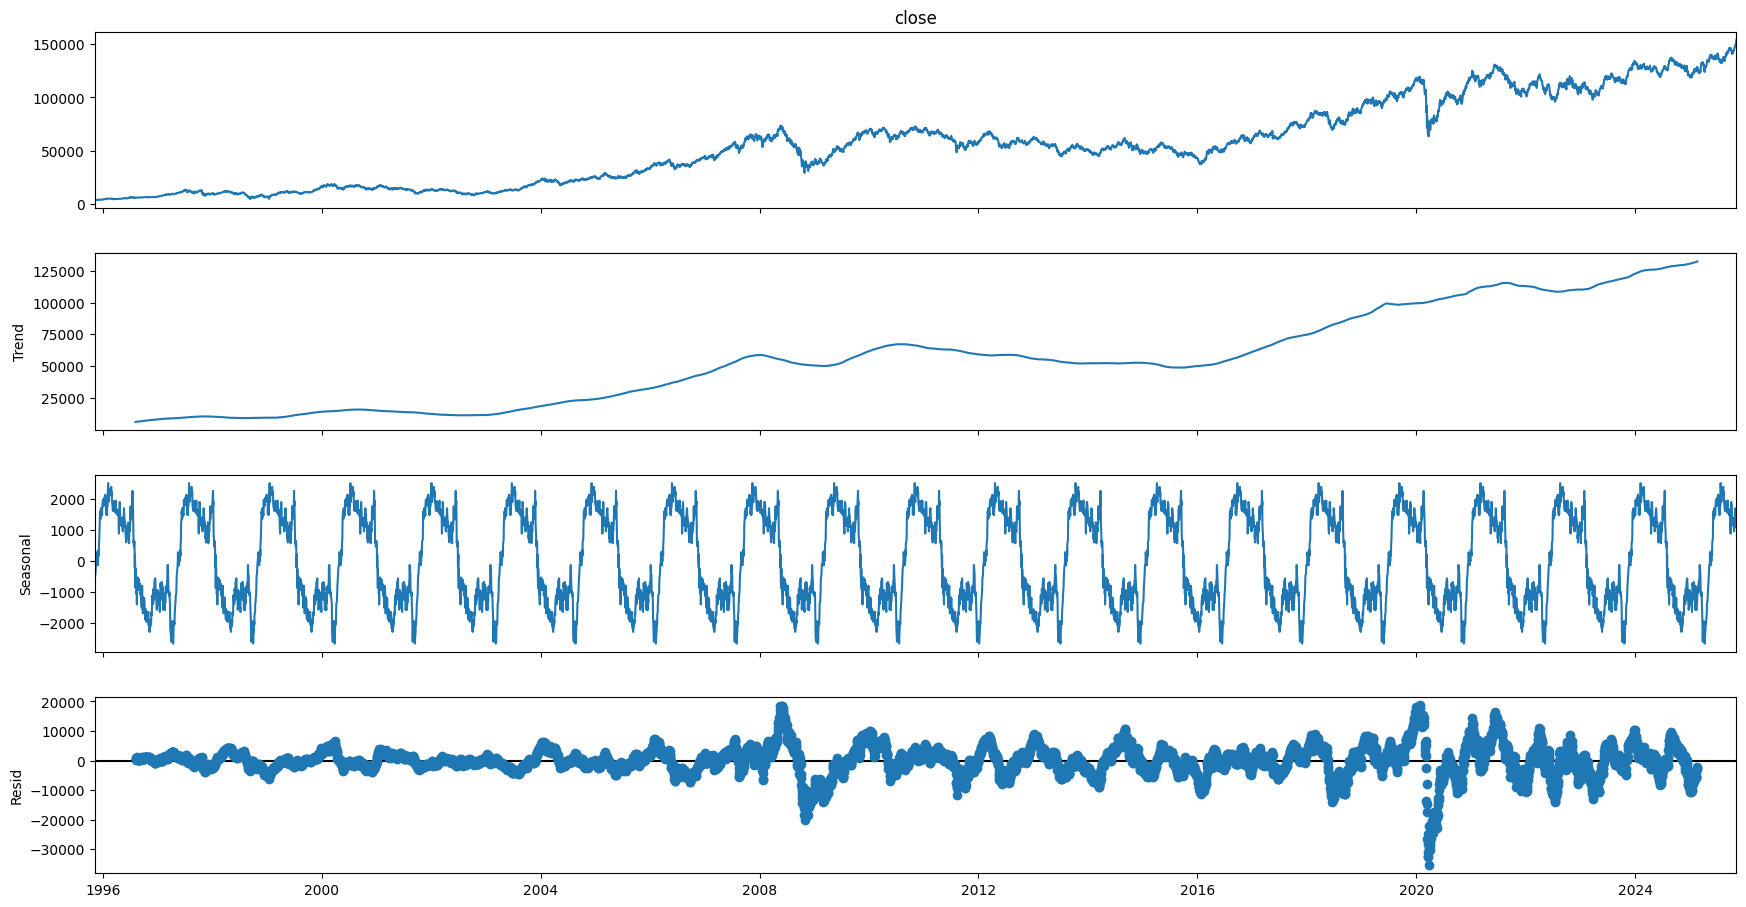

In [ ]:
result = seasonal_decompose(df["close"], model="additive", period=365)
fig = result.plot()
fig.set_size_inches(20, 10)

## Preparando dataframe para comparar modelos

In [ ]:
# Criando as features D-1
df['open_d-1'] = df['open'].shift(1)
df['close_d-1'] = df['close'].shift(1)
df['high_d-1'] = df['high'].shift(1)
df['low_d-1'] = df['low'].shift(1)

# Definindo as features (X)
# 'open' de hoje (D)
# 'open_d-1', 'close_d-1', 'high_d-1', 'low_d-1' de ontem (D-1)
X = df[['open', 'open_d-1', 'close_d-1', 'high_d-1', 'low_d-1']]

# Definindo o target (y) - 'close' de hoje (D)
y = df['close']

# Combinar X e y para remover as linhas com NaN resultantes do shift
# Usamos concat para facilitar o tratamento de NaNs
dataset = pd.concat([X, y.rename('target')], axis=1).dropna()

# Separar X e y novamente do dataset limpo
X = dataset[['open', 'open_d-1', 'close_d-1', 'high_d-1', 'low_d-1']]
Y = dataset['target']

print("DataFrame preparado com sucesso!")
print("Primeiras 5 linhas das Features (X):")
print(X.head())
print("\nPrimeiras 5 linhas do Target (Y):")
print(Y.head())
print(f"\nShape de X: {X.shape}")
print(f"Shape de Y: {Y.shape}")

DataFrame preparado com sucesso!
Primeiras 5 linhas das Features (X):
            open  open_d-1  close_d-1  high_d-1  low_d-1
date                                                    
1995-11-09  4117    4111.0     4117.0    4173.0   4051.0
1995-11-10  4113    4117.0     4113.0    4158.0   4072.0
1995-11-13  3953    4113.0     3958.0    4126.0   3931.0
1995-11-14  3787    3953.0     3787.0    3953.0   3760.0
1995-11-16  3800    3787.0     3797.0    3843.0   3714.0

Primeiras 5 linhas do Target (Y):
date
1995-11-09    4113
1995-11-10    3958
1995-11-13    3787
1995-11-14    3797
1995-11-16    4004
Name: target, dtype: int64

Shape de X: (7434, 5)
Shape de Y: (7434,)


In [ ]:
test_days = 30

X_train, X_test = X[:-test_days], X[-test_days:]
Y_train, Y_test = Y[:-test_days], Y[-test_days:]

print(f"Tamanho do conjunto de treino (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Tamanho do conjunto de treino (Y_train): {Y_train.shape}")
print(f"Tamanho do conjunto de teste (Y_test): {Y_test.shape}")

Tamanho do conjunto de treino (X_train): (7404, 5)
Tamanho do conjunto de teste (X_test): (30, 5)
Tamanho do conjunto de treino (Y_train): (7404,)
Tamanho do conjunto de teste (Y_test): (30,)


## Adicionando modelos para comparação

Vamos utilizar um algoritmo para realizar a comparação entre diversos modelos de machine learning de forma mais rápida e ir afunilando a decisão de acordo com os resultados obtidos com os modelos em configuração padrão

### Modelos de regressão e árvore de regressão

In [ ]:
seed = 42
models = []
models.append(('LR', LinearRegression()))
models.append(('LASSO', Lasso(random_state=seed)))
models.append(('EN', ElasticNet(random_state=seed)))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor(random_state=seed)))
models.append(('SVR', SVR()))

### Modelo de rede neural

In [ ]:
models.append(('MLP', MLPRegressor(random_state=seed)))

### Modelos ensemble

In [ ]:
# Boosting
models.append(('ABR', AdaBoostRegressor(random_state=seed)))
models.append(('GBR', GradientBoostingRegressor(random_state=seed)))
# Bagging
models.append(('RFR', RandomForestRegressor(random_state=seed)))
models.append(('ETR', ExtraTreesRegressor(random_state=seed)))

Abaixo, utilizamos o algoritmo para testar diversos modelos de regressão baseado no livro *Blueprints de Aprendizado de Máquina e Ciência de Dados para Finanças*, de Tatsat, Puri & Lookabaugh.

In [ ]:
num_folds = 10

# scikit is moving away from mean_squared_error.
# In order to avoid confusion, and to allow comparison with other models, we invert the final scores
scoring = 'neg_mean_squared_error'

names = []
kfold_results = []
test_results = []
train_results = []
for name, model in models:
    names.append(name)

    ## K Fold analysis:

    # Fix: Set shuffle=True to use random_state effectively
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
    #converted mean square error to positive. The lower the beter
    cv_results = -1* cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    kfold_results.append(cv_results)


    # Full Training period
    res = model.fit(X_train, Y_train)
    train_result = mean_squared_error(res.predict(X_train), Y_train)
    train_results.append(train_result)

    # Test results
    test_result = mean_squared_error(res.predict(X_test), Y_test)
    test_results.append(test_result)

    msg = "%s: %f (%f) %f %f" % (name, cv_results.mean(), cv_results.std(), train_result, test_result)
    print(msg)

LR: 893967.279078 (127754.036688) 886917.262691 976778.317359
LASSO: 905188.641252 (135960.128347) 903695.859524 963148.647001
EN: 905188.634475 (135960.105418) 903695.846208 963149.017302
KNN: 1063573.417351 (114939.995251) 702146.083214 10070838.230667
CART: 1914856.498249 (236180.857141) 0.000000 11825864.700000
SVR: 1368038102.115302 (47427257.130824) 1355898613.530543 8406450400.448495
MLP: 999363.178357 (154423.464485) 1044745.052672 1417862.834292
ABR: 4842770.577906 (504952.712623) 4314937.344024 53656846.390217
GBR: 1051079.757940 (144959.955036) 766361.918006 10798978.719535
RFR: 1088857.374666 (177795.098296) 151635.484955 10021836.563127
ETR: 1119526.786791 (158852.201688) 0.001038 9864515.799047


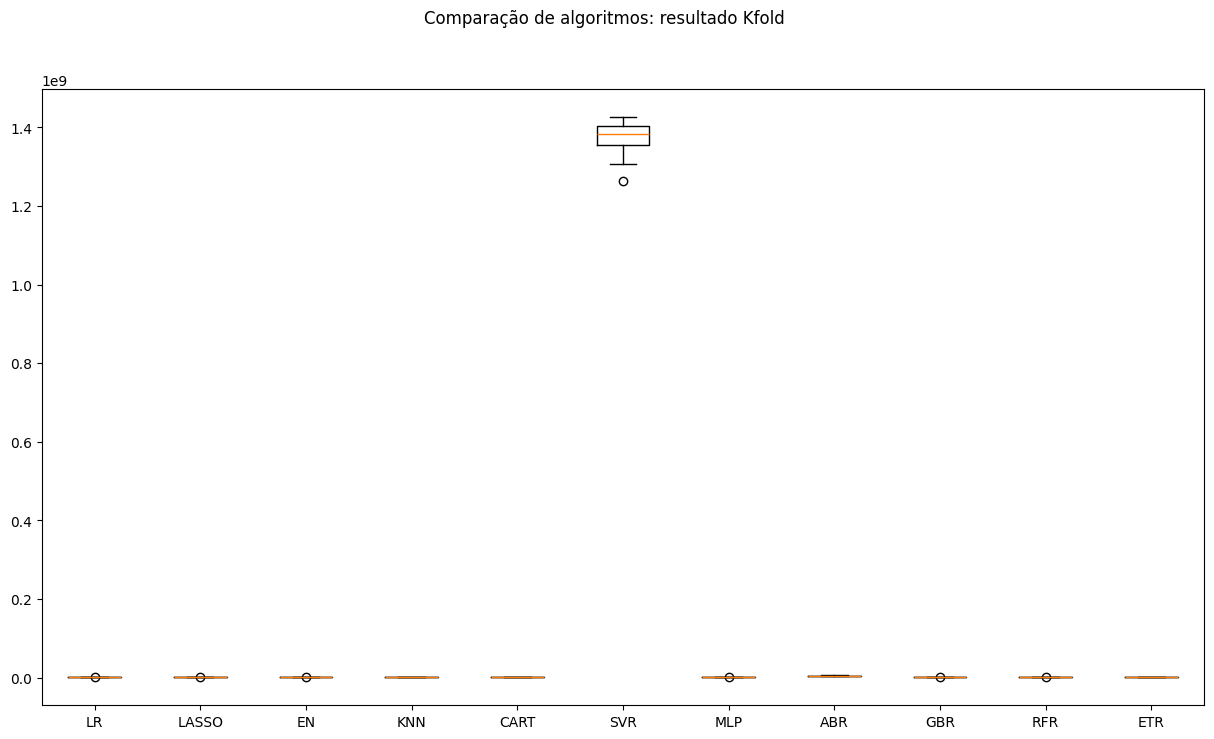

In [ ]:
fig = plt.figure()
fig.suptitle('Comparação de algoritmos: resultado Kfold')
ax = fig.add_subplot(111)
plt.boxplot(kfold_results)
ax.set_xticklabels(names)
fig.set_size_inches(15,8)
plt.show()

Como o SVR ficou muito longe dos resultados dos outros algoritmos. Vou desconsiderá-lo no plot

## Novo boxplot dos erros excluindo o resultado do SVR

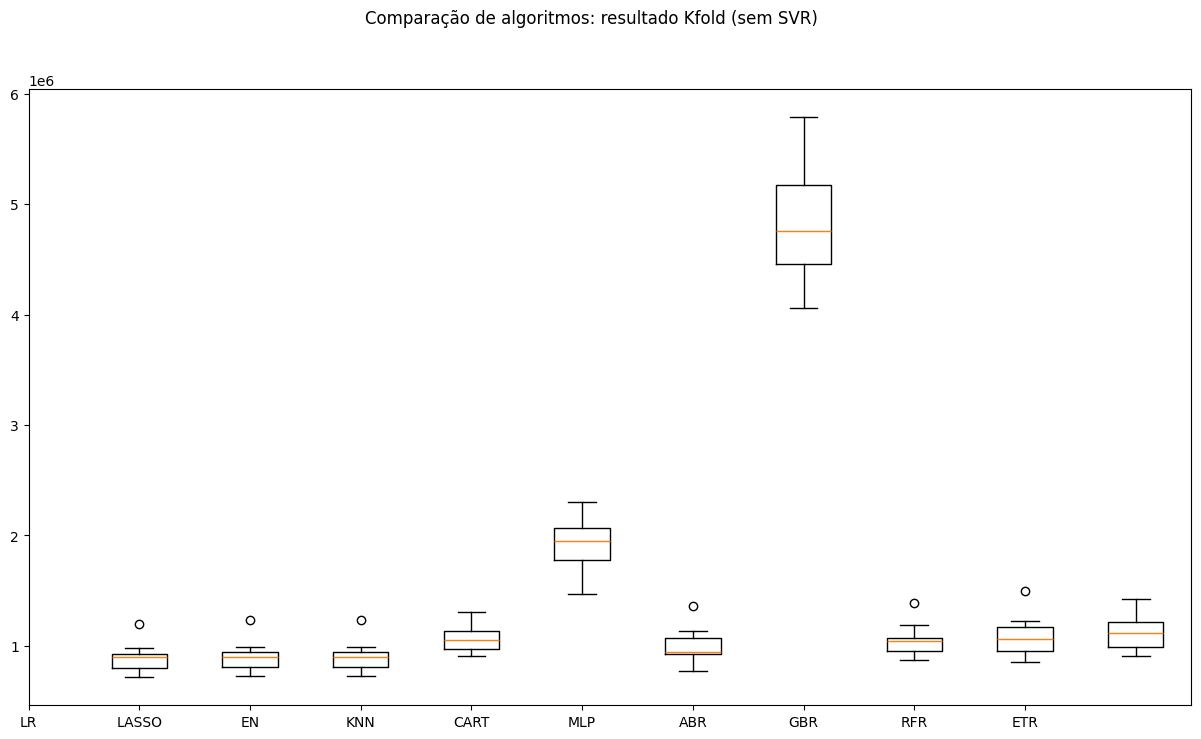

In [ ]:
svr_index = names.index('SVR')
# Remove 'SVR'dos resultados
names_filtered = [name for i, name in enumerate(names) if i != svr_index]
kfold_results_filtered = [result for i, result in enumerate(kfold_results) if i != svr_index]

fig = plt.figure()
fig.suptitle('Comparação de algoritmos: resultado Kfold (sem SVR)')
ax = fig.add_subplot(111)
plt.boxplot(kfold_results_filtered)
ax.set_xticks(np.arange(len(names_filtered))) # Define as posições dos ticks primeiro
ax.set_xticklabels(names_filtered) # Depois, aplica os rótulos
fig.set_size_inches(15,8)
plt.show()

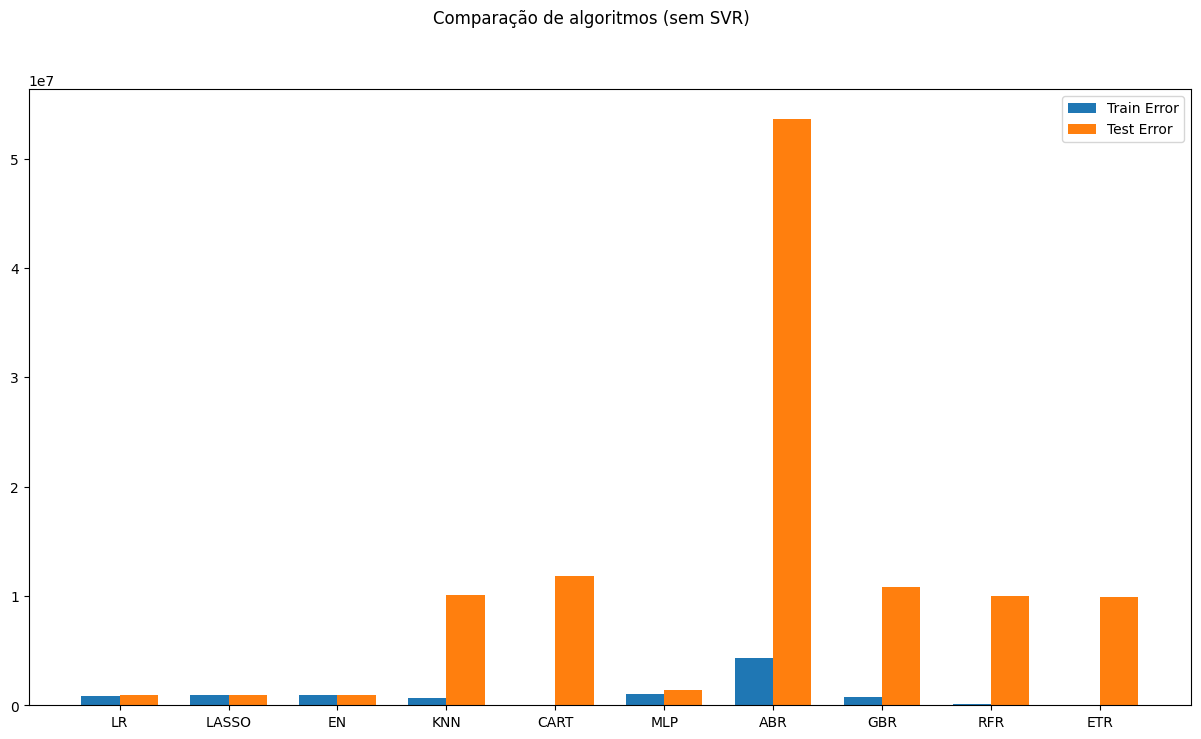

In [ ]:
# compare algorithms
fig = plt.figure()

# Get the index of 'SVR'
svr_index = names.index('SVR')

# Create filtered lists without SVR
names_plot = [name for i, name in enumerate(names) if i != svr_index]
train_results_plot = [result for i, result in enumerate(train_results) if i != svr_index]
test_results_plot = [result for i, result in enumerate(test_results) if i != svr_index]

ind = np.arange(len(names_plot))  # the x locations for the groups
width = 0.35  # the width of the bars

fig.suptitle('Comparação de algoritmos (sem SVR)')
ax = fig.add_subplot(111)
plt.bar(ind - width/2, train_results_plot,  width=width, label='Train Error')
plt.bar(ind + width/2, test_results_plot, width=width, label='Test Error')
fig.set_size_inches(15,8)
plt.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names_plot)
plt.show()

### Análise inicial:

No primeiro teste comparativo, os resultados do erro quadrático médio (MSE) no conjunto de teste (`test_results`) e na validação cruzada K-fold (`kfold_results`) foram calculados para diversos modelos:

*   **Modelos Lineares (LR, LASSO, ElasticNet):** Apresentaram os menores erros de teste e os resultados de K-fold mais consistentes, com desvios padrão relativamente baixos. Isso sugere que eles têm uma boa capacidade de generalização para este conjunto de dados. Os erros de treino e teste foram próximos, indicando um bom balanço entre viés e variância.
*   **KNN e Modelos Baseados em Árvores (CART, RFR, ETR, GBR, ABR):** Embora alguns desses modelos (como CART e ETR) tenham apresentado erro de treino muito próximo de zero (indicando que se ajustaram perfeitamente aos dados de treino), eles exibiram erros de teste significativamente mais altos e maior variabilidade nos resultados de K-fold (visível nos boxplots). Isso é um forte indicativo de **overfitting**, onde o modelo memoriza os dados de treino em vez de aprender padrões generalizáveis.
*   **MLP (Rede Neural Multicamadas):** Teve um erro de teste maior que os modelos lineares, mas menor que a maioria dos modelos baseados em árvores e KNN, posicionando-o em um intermediário em termos de desempenho de generalização inicial.
*   **SVR (Máquinas de Vetor de Suporte para Regressão):** Apresentou um desempenho extremamente ruim, com erros de treino e teste muito elevados. Isso pode ser devido à sensibilidade do SVR à escala das features ou à necessidade de ajuste de hiperparâmetros mais aprofundado, mas nas configurações padrão, ele não foi adequado para este problema.

**Visualização dos Erros:**

As visualizações dos boxplots (excluindo o SVR para melhor escala) e dos gráficos de barras de erro de treino vs. teste reforçam a análise acima. Os modelos lineares se destacam pela proximidade entre os erros de treino e teste, enquanto os modelos baseados em árvores mostram uma grande disparidade, confirmando o overfitting.

**Conclusão Parcial:**

A conclusão inicial é que os modelos lineares (LR, LASSO, ElasticNet) foram os mais promissores em termos de capacidade de generalização. O SVR foi descartado devido ao seu desempenho e os modelos baseados em árvores e KNN precisariam de otimização de hiperparâmetros significativa para mitigar o overfitting.

### Adicionando modelos de time series

Além dos modelos testados inicialmente, vamos testar também SARIMAX e LSTM

In [ ]:
np.random.seed(42)

modelSARIMAX=SARIMAX(endog=Y_train,exog=X_train,order=[1,0,0])
model_fit = modelSARIMAX.fit()

In [ ]:
tr_len = len(Y_train)
to_len = len(Y_train) + len(Y_test)

error_Training_SARIMAX = mean_squared_error(Y_train, model_fit.fittedvalues)
predicted = model_fit.predict(start = tr_len ,end = to_len - 1, exog = X_test)
error_Test_SARIMAX = mean_squared_error(Y_test,predicted)
error_Test_SARIMAX

976485.7218720529

In [ ]:
seq_len = 2 #Length of the seq for the LSTM

Y_train_LSTM, Y_test_LSTM = np.array(Y_train)[seq_len-1:], np.array(Y_test)
X_train_LSTM = np.zeros((X_train.shape[0]+1-seq_len, seq_len, X_train.shape[1]))
X_test_LSTM = np.zeros((X_test.shape[0], seq_len, X.shape[1]))
for i in range(seq_len):
    X_train_LSTM[:, i, :] = np.array(X_train)[i:X_train.shape[0]+i+1-seq_len, :]
    X_test_LSTM[:, i, :] = np.array(X)[X_train.shape[0]+i-1:X.shape[0]+i+1-seq_len, :]

In [ ]:
# Lstm Network
def create_LSTMmodel(neurons=12, learning_rate = 0.01, momentum=0.0):
        # create model
    model = Sequential()
    model.add(LSTM(50, input_shape=(X_train_LSTM.shape[1], X_train_LSTM.shape[2])))
    #More number of cells can be added if needed
    model.add(Dense(1))
    optimizer = SGD(learning_rate=learning_rate, momentum=momentum)
    model.compile(loss='mse', optimizer='adam')
    return model
LSTMModel = create_LSTMmodel(12, learning_rate = 0.01, momentum=0.0)
LSTMModel_fit = LSTMModel.fit(X_train_LSTM, Y_train_LSTM, validation_data=(X_test_LSTM, Y_test_LSTM),epochs=330, batch_size=72, verbose=0, shuffle=False)

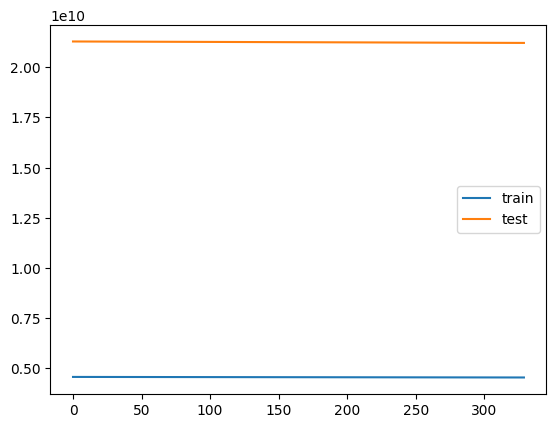

In [ ]:
#Visual plot to check if the error is reducing
plt.plot(LSTMModel_fit.history['loss'], label='train')
plt.plot(LSTMModel_fit.history['val_loss'], label='test')
plt.legend()
plt.show()

Analisando o gráfico de erro do LSTM na célula acima, observamos que:

*   **Erros Elevados:** Tanto a linha de `loss` (treino) quanto a de `val_loss` (validação/teste) permanecem em níveis muito altos ao longo das épocas.
*   **Ausência de Convergência ou Melhoria:** Não há uma clara tendência de queda nos erros, e eles não convergem para um valor baixo. Isso sugere que o modelo não está aprendendo eficientemente a partir dos dados.
*   **Discrepância:** Em alguns momentos, pode-se notar uma grande distância entre as curvas de treino e validação, ou ambas permanecem elevadas, indicando que o modelo não está se ajustando bem aos dados ou que os dados estão em uma escala que dificulta o aprendizado do LSTM.

**Conclusão:** Este gráfico indica que o modelo LSTM, sem a transformação logarítmica, está performando muito mal, provavelmente devido à grande variação na escala dos valores do Ibovespa, que dificultam a convergência da rede neural. Isso levou à decisão de aplicar a transformação logarítmica nos preços para tentar estabilizar o treinamento, como foi feito nas células subsequentes.

In [ ]:
error_Training_LSTM = mean_squared_error(Y_train_LSTM, LSTMModel.predict(X_train_LSTM))
predicted = LSTMModel.predict(X_test_LSTM)
error_Test_LSTM = mean_squared_error(Y_test_LSTM,predicted)

232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [ ]:
test_results.append(error_Test_SARIMAX)
test_results.append(error_Test_LSTM)

train_results.append(error_Training_SARIMAX)
train_results.append(error_Training_LSTM)

names.append("SARIMAX")
names.append("LSTM")

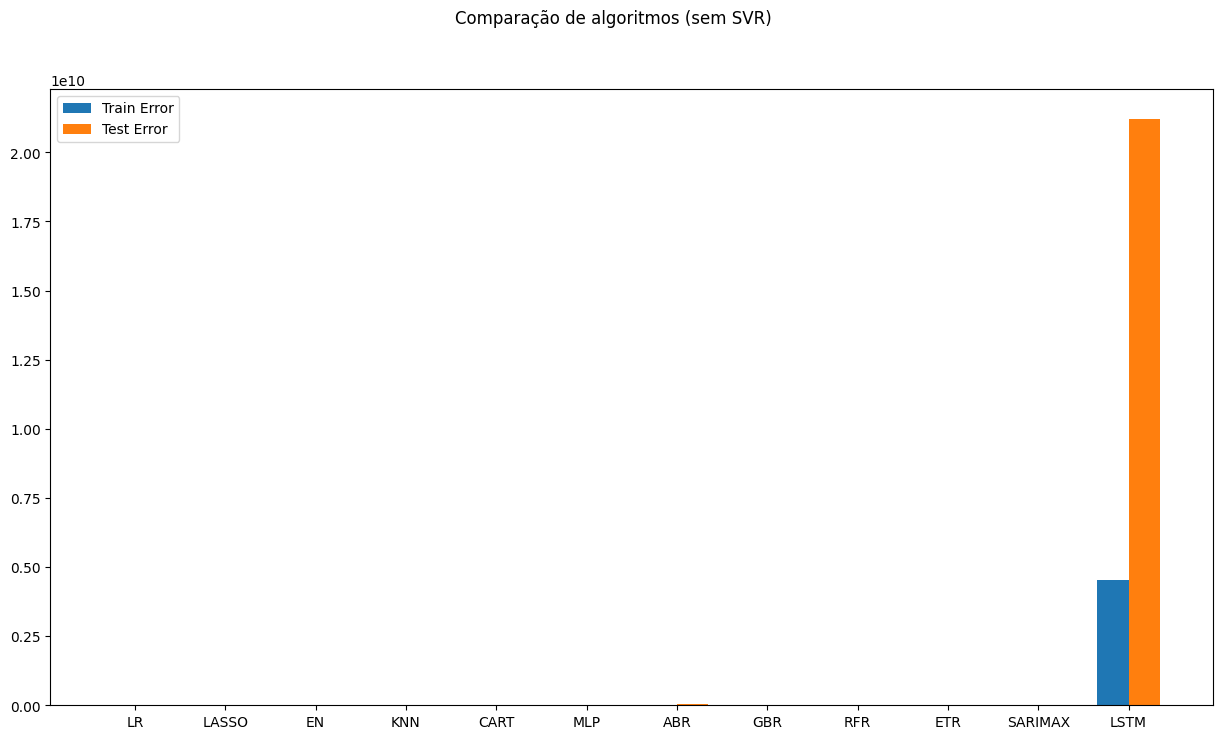

In [ ]:
# compare algorithms
fig = plt.figure()

# Get the index of 'SVR'
svr_index = names.index('SVR')

# Create filtered lists without SVR
names_plot = [name for i, name in enumerate(names) if i != svr_index]
train_results_plot = [result for i, result in enumerate(train_results) if i != svr_index]
test_results_plot = [result for i, result in enumerate(test_results) if i != svr_index]

ind = np.arange(len(names_plot))  # the x locations for the groups
width = 0.35  # the width of the bars

fig.suptitle('Comparação de algoritmos (sem SVR)')
ax = fig.add_subplot(111)
plt.bar(ind - width/2, train_results_plot,  width=width, label='Train Error')
plt.bar(ind + width/2, test_results_plot, width=width, label='Test Error')
fig.set_size_inches(15,8)
plt.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names_plot)
plt.show()

Como o plot anterior já antecipava, o LSTM performou muito mal com os dados da forma que estão. Vamos testar transformar os preços para a escala logaritmica e ver se conseguimos algo melhor.

In [ ]:
seq_len = 2 #Length of the seq for the LSTM

# Apply log transformation to the data specifically for LSTM
X_train_log = np.log(X_train)
Y_train_log = np.log(Y_train)
X_test_log = np.log(X_test)
Y_test_log = np.log(Y_test)

# The original X (full dataset) is used to construct X_test_LSTM, so it also needs to be log-transformed
X_full_log = np.log(X)

Y_train_LSTM = np.array(Y_train_log)[seq_len-1:]
Y_test_LSTM = np.array(Y_test_log)

X_train_LSTM = np.zeros((X_train_log.shape[0]+1-seq_len, seq_len, X_train_log.shape[1]))
X_test_LSTM = np.zeros((X_test_log.shape[0], seq_len, X_test_log.shape[1]))

for i in range(seq_len):
    X_train_LSTM[:, i, :] = np.array(X_train_log)[i:X_train_log.shape[0]+i+1-seq_len, :]
    # Using X_full_log to maintain the original logic of constructing X_test_LSTM from the full dataset
    X_test_LSTM[:, i, :] = np.array(X_full_log)[X_train_log.shape[0]+i-1 : X_full_log.shape[0]+i+1-seq_len, :]

In [ ]:
LSTMModel_fit_log = LSTMModel.fit(X_train_LSTM, Y_train_LSTM, validation_data=(X_test_LSTM, Y_test_LSTM),epochs=330, batch_size=72, verbose=0, shuffle=False)

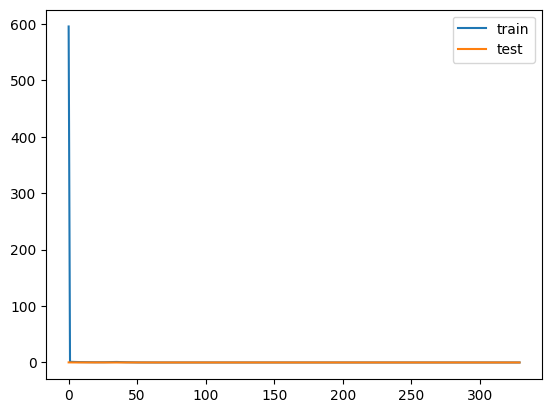

In [ ]:
#Visual plot to check if the error is reducing
plt.plot(LSTMModel_fit_log.history['loss'], label='train')
plt.plot(LSTMModel_fit_log.history['val_loss'], label='test')
plt.legend()
plt.show()

Analisando o gráfico de erro do LSTM após a transformação logarítmica (célula acima), observamos uma melhora significativa em comparação com o modelo anterior sem a transformação:

*   **Redução e Convergência dos Erros:** Ambas as linhas de `loss` (treino) e `val_loss` (validação/teste) mostram uma clara tendência de queda ao longo das épocas, indicando que o modelo está aprendendo e que os erros estão diminuindo. Além disso, as curvas parecem convergir para valores muito menores em comparação com o gráfico anterior.
*   **Estabilidade no Treinamento:** A transformação logarítmica aparentemente estabilizou o treinamento da rede neural, permitindo que ela lide melhor com a grande variância dos preços do Ibovespa.
*   **Boa Generalização:** A proximidade entre as curvas de `loss` e `val_loss` no final do treinamento sugere que o modelo está generalizando bem, sem sinais evidentes de overfitting neste estágio.

**Conclusão:** A aplicação da transformação logarítmica nos preços foi crucial para o desempenho do modelo LSTM. Com esta abordagem, o modelo conseguiu aprender padrões de forma mais eficaz e demonstrou uma capacidade de predição muito mais promissora. Os resultados das métricas de erro (`NRMO097C2PRp` e `r5tUSKT22RWL`) confirmam essa melhoria.

In [ ]:
# Predict on log-transformed data
predicted_train_log = LSTMModel.predict(X_train_LSTM)
predicted_test_log = LSTMModel.predict(X_test_LSTM)

# Inverse transform predictions and actuals to original scale
predicted_train_original = np.exp(predicted_train_log)
predicted_test_original = np.exp(predicted_test_log)
Y_train_original = np.exp(Y_train_LSTM)
Y_test_original = np.exp(Y_test_log)

# Calculate errors on original scale
error_Training_LSTM_log = mean_squared_error(Y_train_original, predicted_train_original)
error_Test_LSTM_log = mean_squared_error(Y_test_original, predicted_test_original)

232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [ ]:
test_results.append(error_Test_LSTM_log)

train_results.append(error_Training_LSTM_log)

names.append("LSTM log")

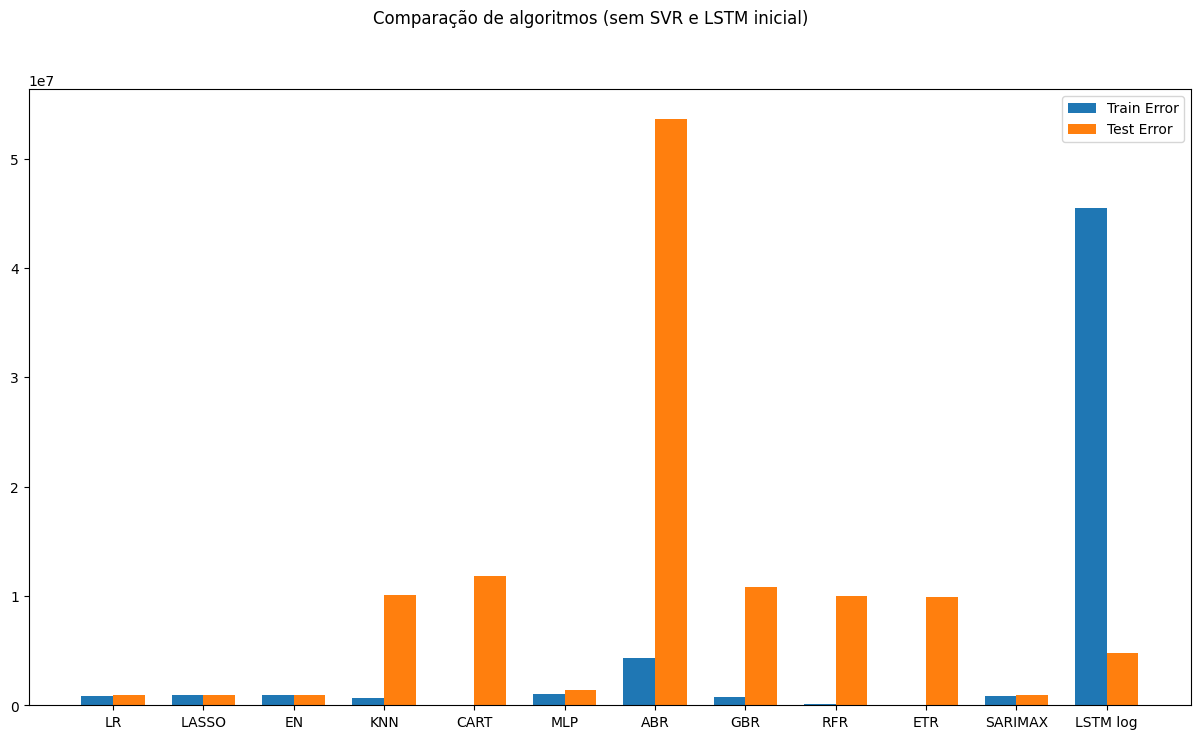

In [ ]:
# compare algorithms
fig = plt.figure()

# List of models to exclude from the plot
excluded_models = ['SVR', 'LSTM']

# Create filtered lists
names_plot = []
train_results_plot = []
test_results_plot = []

for i, name in enumerate(names):
    if name not in excluded_models:
        names_plot.append(name)
        train_results_plot.append(train_results[i])
        test_results_plot.append(test_results[i])

ind = np.arange(len(names_plot))  # the x locations for the groups
width = 0.35  # the width of the bars

fig.suptitle('Comparação de algoritmos (sem SVR e LSTM inicial)')
ax = fig.add_subplot(111)
plt.bar(ind - width/2, train_results_plot,  width=width, label='Train Error')
plt.bar(ind + width/2, test_results_plot, width=width, label='Test Error')
fig.set_size_inches(15,8)
plt.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names_plot)
plt.show()

In [ ]:
# Funções de Avaliação
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return mae, mse, mape


def print_metrics(metrics):
    mae, mse, mape = metrics
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"MAPE: {mape:.2f} %")

In [ ]:
all_evaluations = []

# Collect data for regression/ensemble models
# 'models' is the list of (name, unfitted_model_instance)
for name, model_instance in models:
    if name not in ['SVR', 'LSTM']: # Exclude SVR and the initial LSTM
        # Fit model
        fitted_model = model_instance.fit(X_train, Y_train)
        y_train_pred = fitted_model.predict(X_train)
        y_test_pred = fitted_model.predict(X_test)
        all_evaluations.append({
            'name': name,
            'y_train_true': Y_train,
            'y_train_pred': y_train_pred,
            'y_test_true': Y_test,
            'y_test_pred': y_test_pred
        })

# Collect data for SARIMAX
# Refit SARIMAX model for consistency, as model_fit was global but might be outdated or not have all needed predictions
sarimax_fitted_model = SARIMAX(endog=Y_train,exog=X_train,order=[1,0,0])
sarimax_fitted_model = sarimax_fitted_model.fit(disp=False) # disp=False to suppress convergence messages
sarimax_y_train_pred = sarimax_fitted_model.fittedvalues
sarimax_y_test_pred = sarimax_fitted_model.predict(start = len(Y_train) ,end = len(Y_train) + len(Y_test) - 1, exog = X_test)
# Assign the index of Y_test to the SARIMAX predictions for correct plotting
sarimax_y_test_pred.index = Y_test.index

all_evaluations.append({
    'name': "SARIMAX",
    'y_train_true': Y_train,
    'y_train_pred': sarimax_y_train_pred,
    'y_test_true': Y_test,
    'y_test_pred': sarimax_y_test_pred
})

# Collect data for LSTM log (already fitted and predictions on original scale)
all_evaluations.append({
    'name': "LSTM log",
    'y_train_true': Y_train_original, # True values on original scale
    'y_train_pred': predicted_train_original.flatten(), # Predictions on original scale, flatten to 1D
    'y_test_true': Y_test_original, # True values on original scale
    'y_test_pred': predicted_test_original.flatten() # Predictions on original scale, flatten to 1D
})

print("--- Métricas de Avaliação para todos os Algoritmos --- ")

for eval_data in all_evaluations:
    print(f"\n--- {eval_data['name']} ---")

    print("Métricas de Treino:")
    metrics_train = calculate_metrics(eval_data['y_train_true'], eval_data['y_train_pred'])
    print_metrics(metrics_train)

    print("Métricas de Teste:")
    metrics_test = calculate_metrics(eval_data['y_test_true'], eval_data['y_test_pred'])
    print_metrics(metrics_test)

--- Métricas de Avaliação para todos os Algoritmos --- 

--- LR ---
Métricas de Treino:
MAE: 611.1340217974099
MSE: 886917.2626914127
MAPE: 1.33 %
Métricas de Teste:
MAE: 796.7493911081478
MSE: 976778.3173591178
MAPE: 0.55 %

--- LASSO ---
Métricas de Treino:
MAE: 612.6045003375999
MSE: 903695.8595239936
MAPE: 1.31 %
Métricas de Teste:
MAE: 794.243735828988
MSE: 963148.6470008097
MAPE: 0.54 %

--- EN ---
Métricas de Treino:
MAE: 612.6044908178275
MSE: 903695.8462077326
MAPE: 1.31 %
Métricas de Teste:
MAE: 794.2438935199714
MSE: 963149.0173017172
MAPE: 0.54 %

--- KNN ---
Métricas de Treino:
MAE: 551.7687466234468
MSE: 702146.0832144786
MAPE: 1.19 %
Métricas de Teste:
MAE: 2135.593333333337
MSE: 10070838.2306667
MAPE: 1.43 %

--- CART ---
Métricas de Treino:
MAE: 0.0
MSE: 0.0
MAPE: 0.00 %
Métricas de Teste:
MAE: 2428.3
MSE: 11825864.7
MAPE: 1.63 %

--- MLP ---
Métricas de Treino:
MAE: 679.3672720603387
MSE: 1044745.0526723221
MAPE: 1.47 %
Métricas de Teste:
MAE: 987.7223659904499
MSE: 1

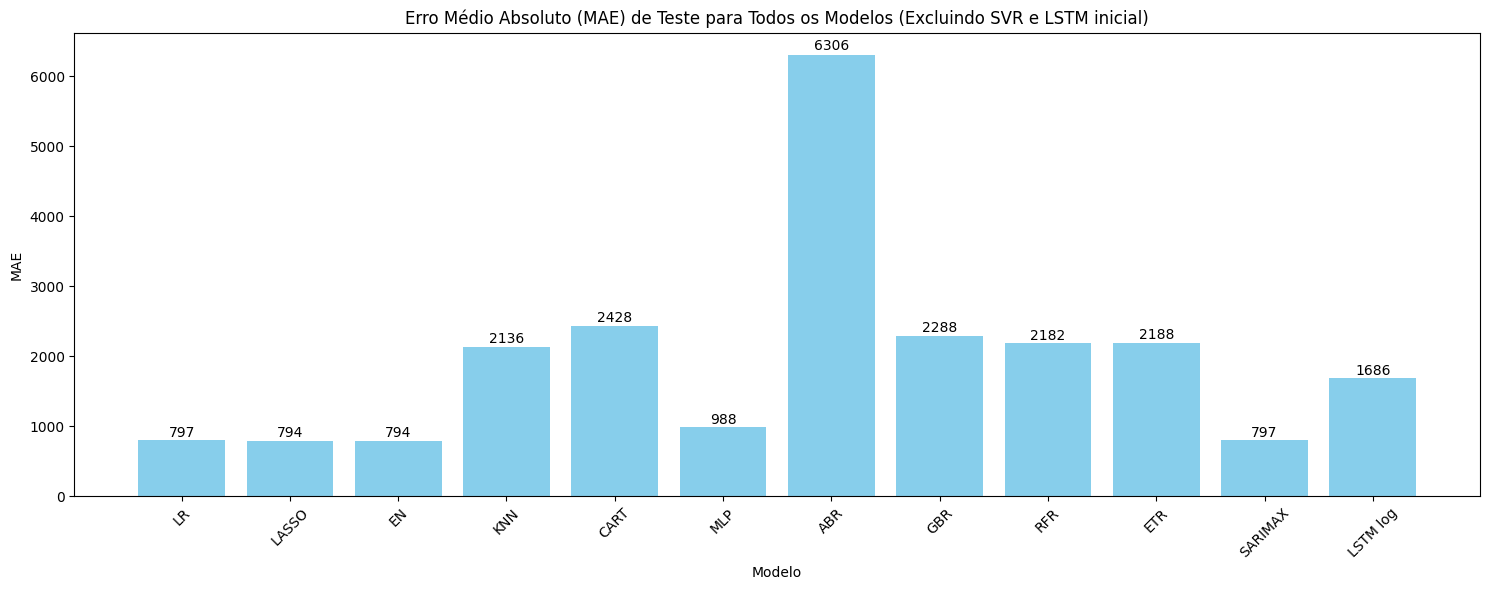

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


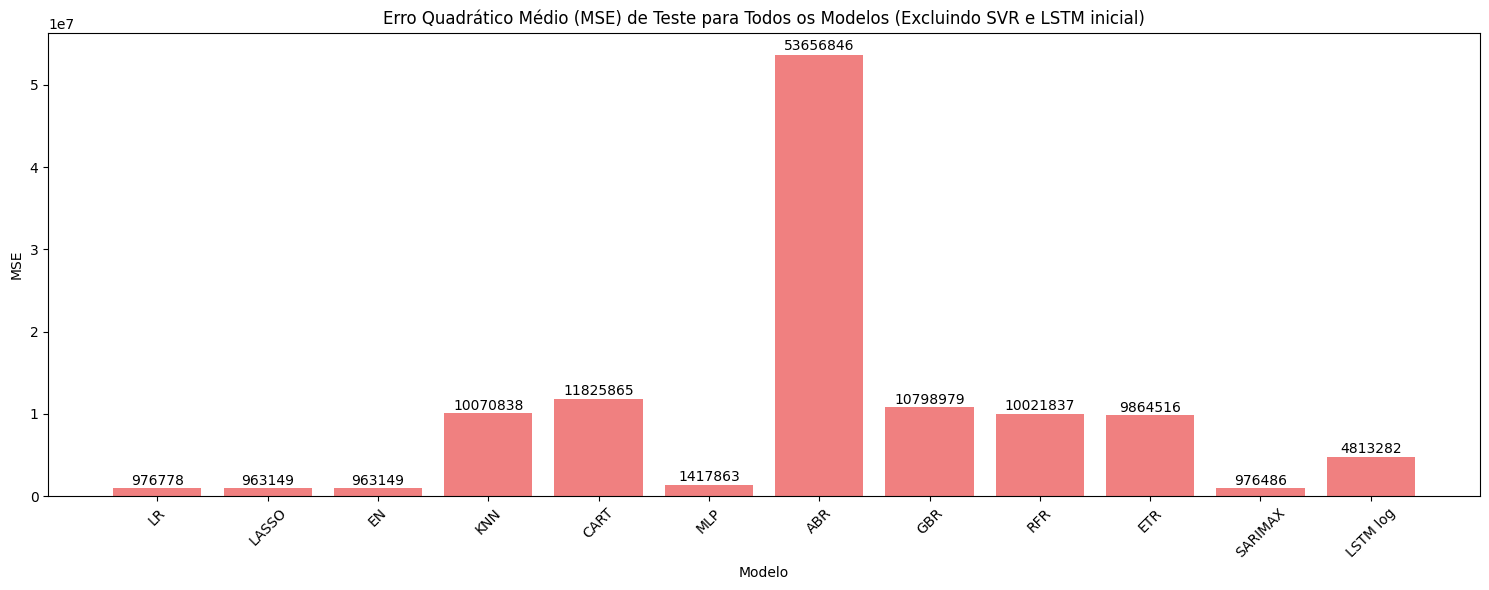

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


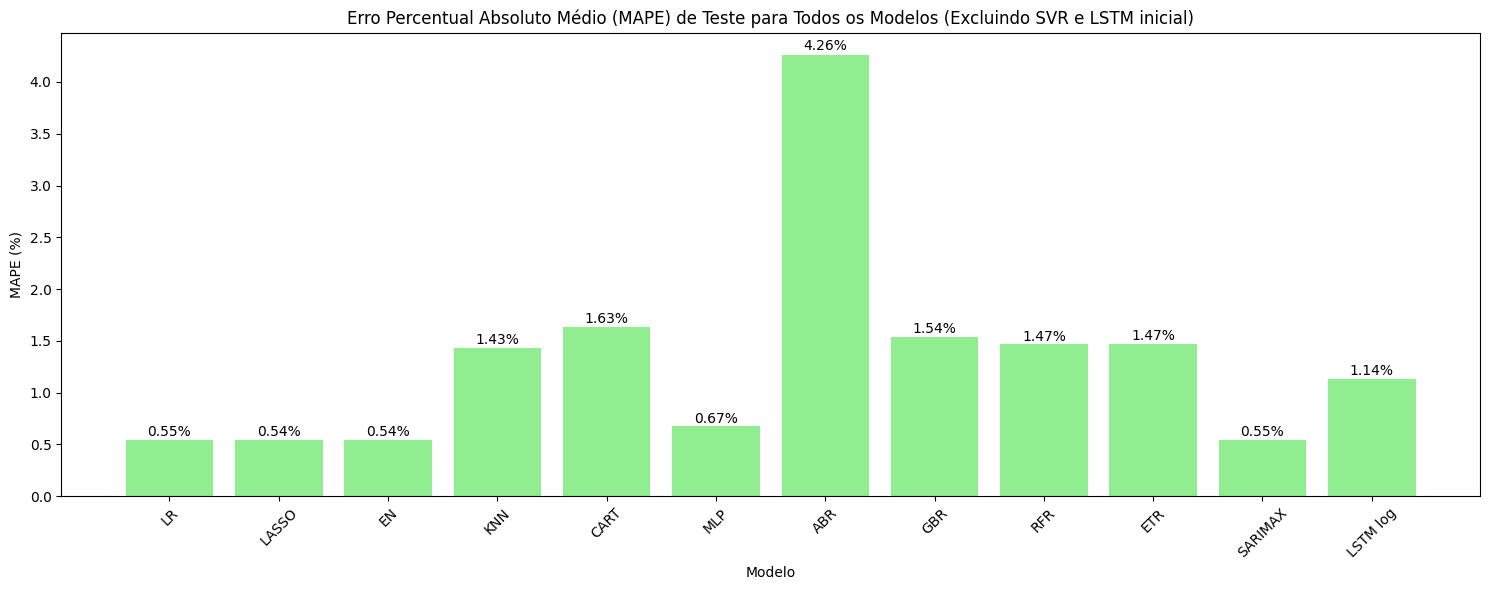

In [ ]:
# Assuming all_evaluations is available from previous cells (e.g., IHZUPc1D9ubj)
# and calculate_metrics is defined (e.g., EWf2bpaR80S7)

model_names = []
test_maes = []
test_mses = []
test_mapes = []

# Filter out SVR and the initial problematic LSTM, which had extremely high errors
# and would skew the visualization. LSTM log is fine.
excluded_models_for_bar_charts = ['SVR', 'LSTM']

for eval_data in all_evaluations:
    name = eval_data['name']
    if name not in excluded_models_for_bar_charts:
        model_names.append(name)
        metrics_test = calculate_metrics(eval_data['y_test_true'], eval_data['y_test_pred'])
        test_maes.append(metrics_test[0])
        test_mses.append(metrics_test[1])
        test_mapes.append(metrics_test[2])

# Function to add value labels on top of bars
def add_value_labels(ax, bars, format_string='{:.0f}'):
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005 * yval,  # Adjust vertical position dynamically
                format_string.format(yval), ha='center', va='bottom')

# --- Plot 1: MAE ---
fig_mae, ax_mae = plt.subplots(figsize=(15, 6))
bars_mae = ax_mae.bar(model_names, test_maes, color='skyblue')
ax_mae.set_title('Erro Médio Absoluto (MAE) de Teste para Todos os Modelos (Excluindo SVR e LSTM inicial)')
ax_mae.set_ylabel('MAE')
ax_mae.set_xlabel('Modelo')
ax_mae.tick_params(axis='x', rotation=45)
add_value_labels(ax_mae, bars_mae)
plt.tight_layout()
plt.show()
print("xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")

# --- Plot 2: MSE ---
fig_mse, ax_mse = plt.subplots(figsize=(15, 6))
bars_mse = ax_mse.bar(model_names, test_mses, color='lightcoral')
ax_mse.set_title('Erro Quadrático Médio (MSE) de Teste para Todos os Modelos (Excluindo SVR e LSTM inicial)')
ax_mse.set_ylabel('MSE')
ax_mse.set_xlabel('Modelo')
ax_mse.tick_params(axis='x', rotation=45)
add_value_labels(ax_mse, bars_mse)
plt.tight_layout()
plt.show()
print("xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")

# --- Plot 3: MAPE ---
fig_mape, ax_mape = plt.subplots(figsize=(15, 6))
bars_mape = ax_mape.bar(model_names, test_mapes, color='lightgreen')
ax_mape.set_title('Erro Percentual Absoluto Médio (MAPE) de Teste para Todos os Modelos (Excluindo SVR e LSTM inicial)')
ax_mape.set_ylabel('MAPE (%)')
ax_mape.set_xlabel('Modelo')
ax_mape.tick_params(axis='x', rotation=45)
add_value_labels(ax_mape, bars_mape, format_string='{:.2f}%') # MAPE often benefits from decimals
plt.tight_layout()
plt.show()


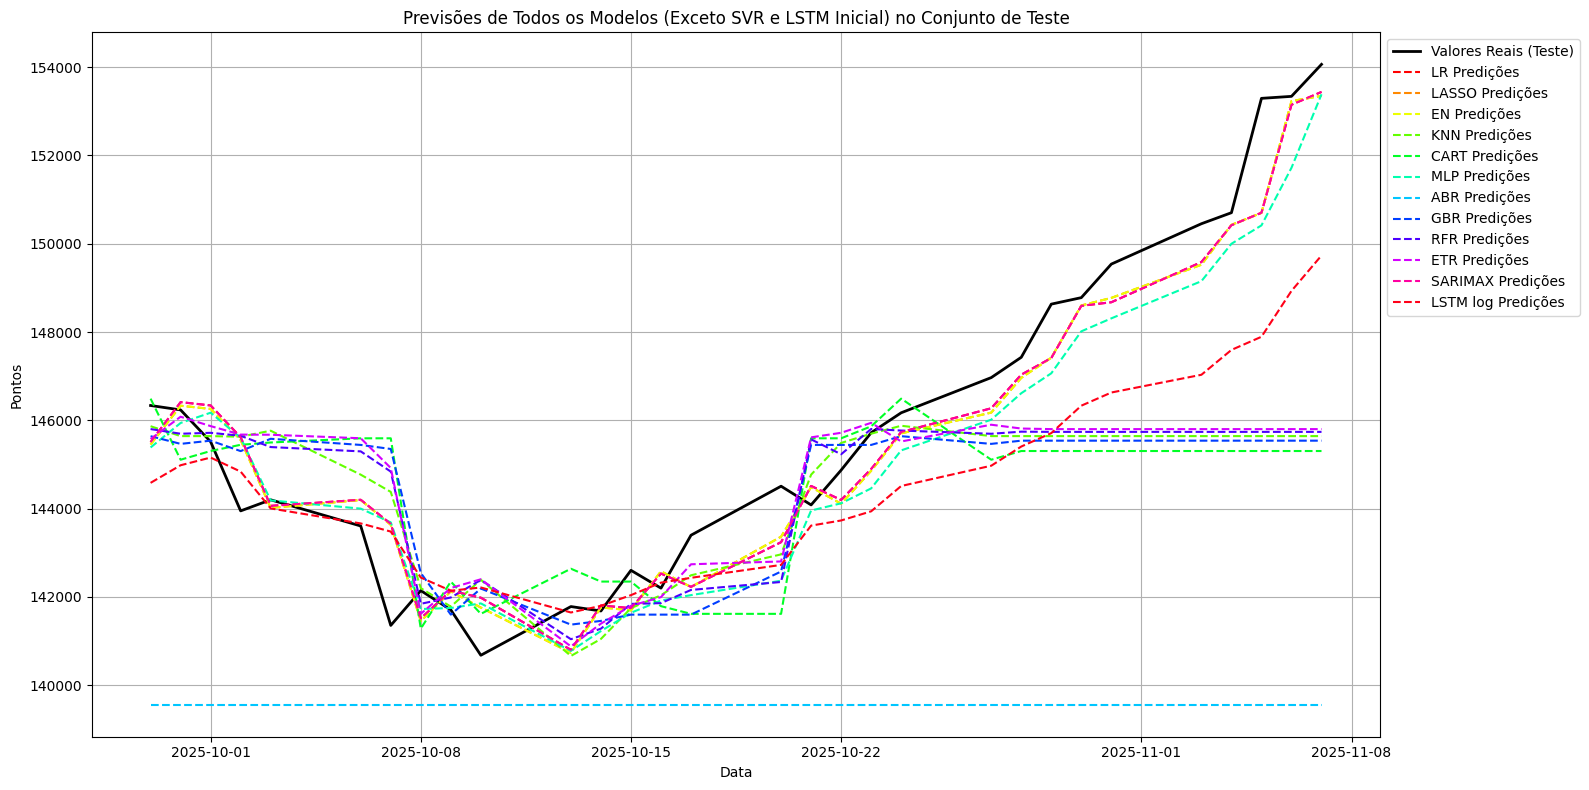

In [ ]:
# plotando as predições de todos os modelos (excluindo SVR e LSTM inicial)

# Filter out SVR and the initial problematic LSTM, which had extremely high errors
excluded_models = ['SVR', 'LSTM']
filtered_evaluations = [eval_data for eval_data in all_evaluations if eval_data['name'] not in excluded_models]

plt.figure(figsize=(16, 8))
plt.plot(Y_test.index, Y_test, label="Valores Reais (Teste)", color='black', linewidth=2)

# Generate a color map for all filtered models
# Using a colormap for better distinction if there are many models
num_models_to_plot = len(filtered_evaluations)
colors = plt.cm.get_cmap('hsv', num_models_to_plot) # 'hsv' is a good choice for distinct colors

for i, model_data in enumerate(filtered_evaluations):
    # Ensure y_test_pred is a 1D array or Series for plotting
    y_test_pred_plot = model_data['y_test_pred'].flatten() if isinstance(model_data['y_test_pred'], np.ndarray) else model_data['y_test_pred']
    plt.plot(Y_test.index, y_test_pred_plot, label=f"{model_data['name']} Predições", color=colors(i), linestyle='--')

plt.title("Previsões de Todos os Modelos (Exceto SVR e LSTM Inicial) no Conjunto de Teste")
plt.xlabel("Data")
plt.ylabel("Pontos")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Place legend outside for clarity
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### Análise Visual da Plotagem de Previsão de Preços

A plotagem gerada na mostra as previsões de todos os modelos (exceto SVR e LSTM inicial) contra os valores reais de fechamento do Ibovespa no conjunto de teste. Observamos:

*   **Modelos com Melhor Aderência:** Visualmente, os **modelos lineares (LR, LASSO, ElasticNet) e o SARIMAX** parecem seguir mais de perto a linha dos valores reais (preta sólida). Suas previsões (linhas tracejadas) tendem a acompanhar tanto a magnitude quanto a direção dos movimentos do mercado de forma consistente, indicando uma boa capacidade de generalização e baixa variância.

*   **Modelos com Desempenho Razoável:** O **MLP** (Rede Neural Multicamadas) também demonstra uma boa capacidade de seguir a tendência geral, embora possa apresentar desvios de magnitude um pouco maiores em certos pontos. Sua capacidade de capturar a direção do mercado é um ponto forte a ser observado visualmente.

*   **Modelos com Pior Aderência/Volatilidade:** Os modelos baseados em árvores (como CART, RFR, ETR, GBR, ABR) e o KNN mostram mais oscilações e, em alguns casos, desvios significativos da linha real. Isso pode ser um indicativo visual de overfitting ou de uma menor capacidade de generalização para este conjunto de dados, onde as previsões não conseguem manter uma proximidade constante com os valores observados.

In [ ]:
from sklearn.metrics import accuracy_score

print("--- Acurácia Direcional de TODOS os Modelos (Teste) ---")

# Calcular a direção real do preço (1 se subiu, 0 se desceu/ficou igual)
binary_true_direction = (Y_test.diff() > 0).astype(int)

# Lista para armazenar os resultados de acurácia direcional
directional_accuracies = []

for model_data in all_evaluations:
    model_name = model_data['name']
    y_test_pred = model_data['y_test_pred']

    # Converter as previsões para Series e alinhar o índice com Y_test
    y_test_pred_series = pd.Series(y_test_pred, index=Y_test.index)
    binary_predicted_direction = (y_test_pred_series.diff() > 0).astype(int)

    # Agora, ambos binary_true_direction e binary_predicted_direction têm o mesmo DatetimeIndex.
    # Basta remover os NaNs do primeiro elemento de cada um.
    valid_true = binary_true_direction.dropna()
    valid_pred = binary_predicted_direction.dropna()

    # Garantir que temos dados suficientes após a remoção de NaNs
    if len(valid_true) > 0 and len(valid_pred) > 0:
        accuracy = accuracy_score(valid_true, valid_pred)
        directional_accuracies.append({'model': model_name, 'accuracy': accuracy})
    else:
        print(f"Aviso: Não foi possível calcular a acurácia para {model_name} devido a dados insuficientes após o cálculo de diferença.")

# Ordenar os resultados em ordem decrescente de acurácia
directional_accuracies.sort(key=lambda x: x['accuracy'], reverse=True)

# Imprimir os resultados ordenados
for result in directional_accuracies:
    print(f"Acurácia Direcional {result['model']}: {100*result['accuracy']:.2f} %")

--- Acurácia Direcional de TODOS os Modelos (Teste) ---
Acurácia Direcional LSTM log: 70.00 %
Acurácia Direcional MLP: 66.67 %
Acurácia Direcional LR: 60.00 %
Acurácia Direcional LASSO: 60.00 %
Acurácia Direcional EN: 60.00 %
Acurácia Direcional SARIMAX: 60.00 %
Acurácia Direcional KNN: 46.67 %
Acurácia Direcional GBR: 40.00 %
Acurácia Direcional CART: 36.67 %
Acurácia Direcional ABR: 36.67 %
Acurácia Direcional ETR: 36.67 %
Acurácia Direcional RFR: 33.33 %


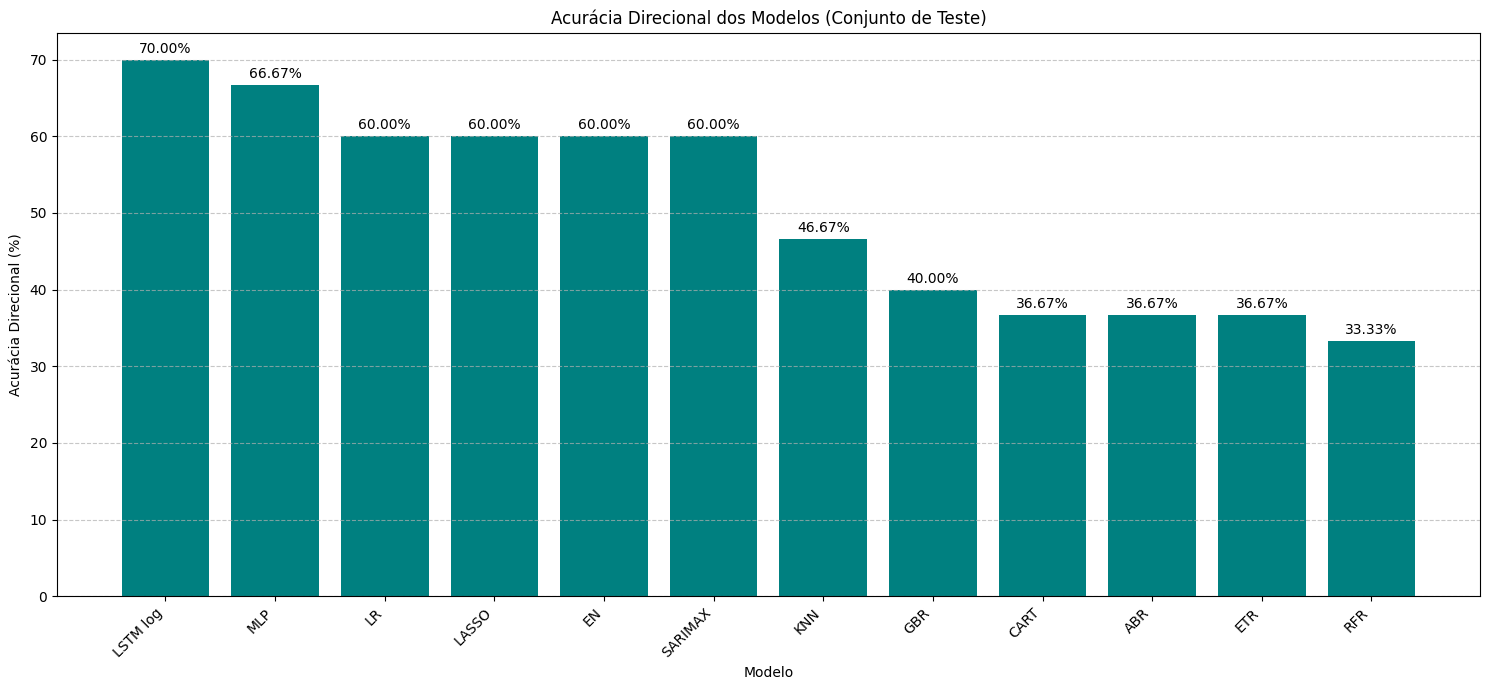

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'directional_accuracies' is available from the previous execution (DH4WWMyIBZVf)

model_names_dir_acc = [d['model'] for d in directional_accuracies]
directional_accuracy_values = [d['accuracy'] * 100 for d in directional_accuracies] # Convert to percentage

# Function to add value labels on top of bars (reusing the one from D_F3LDWr-tYo, slightly adjusted for percentage)
def add_value_labels(ax, bars, format_string='{:.2f}%'):
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, # Adjust vertical position slightly above the bar
                format_string.format(yval), ha='center', va='bottom')

plt.figure(figsize=(15, 7))
bars = plt.bar(model_names_dir_acc, directional_accuracy_values, color='teal')

plt.title('Acurácia Direcional dos Modelos (Conjunto de Teste)')
plt.xlabel('Modelo')
plt.ylabel('Acurácia Direcional (%)')
plt.xticks(rotation=45, ha='right')
add_value_labels(plt.gca(), bars)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- LASSO ---
Acurácia Direcional LASSO: 60.00 % (18/30)



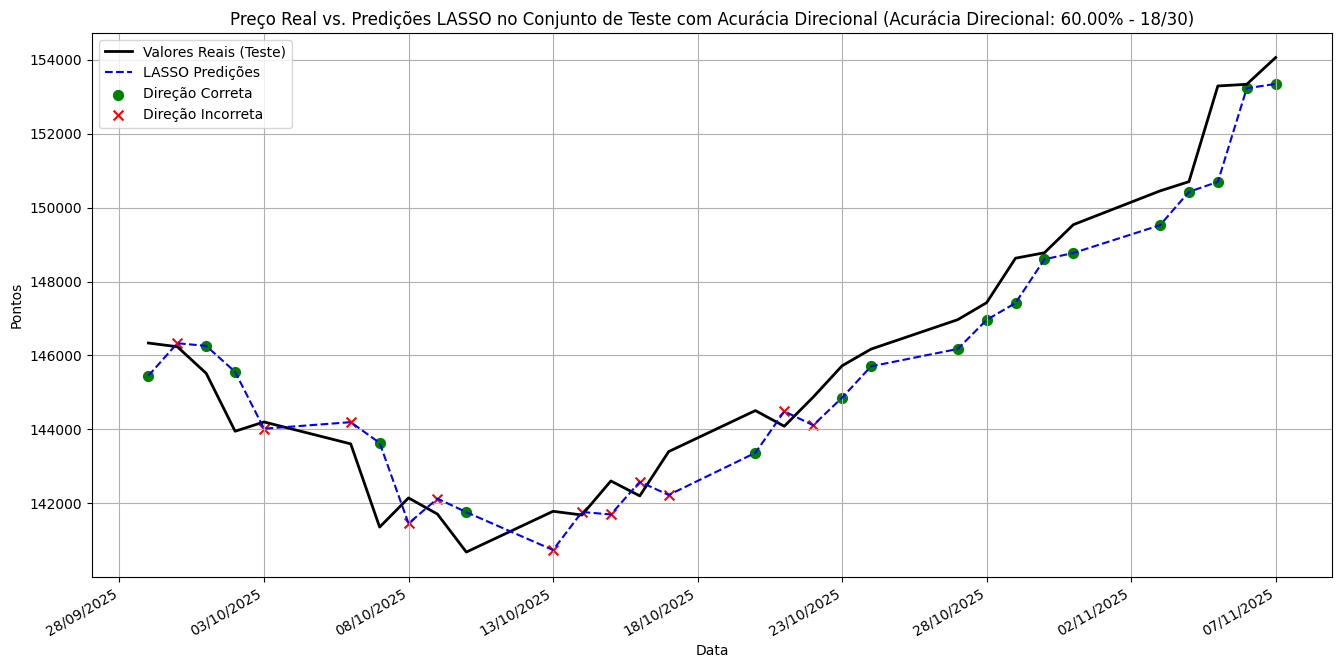



--- EN ---
Acurácia Direcional EN: 60.00 % (18/30)



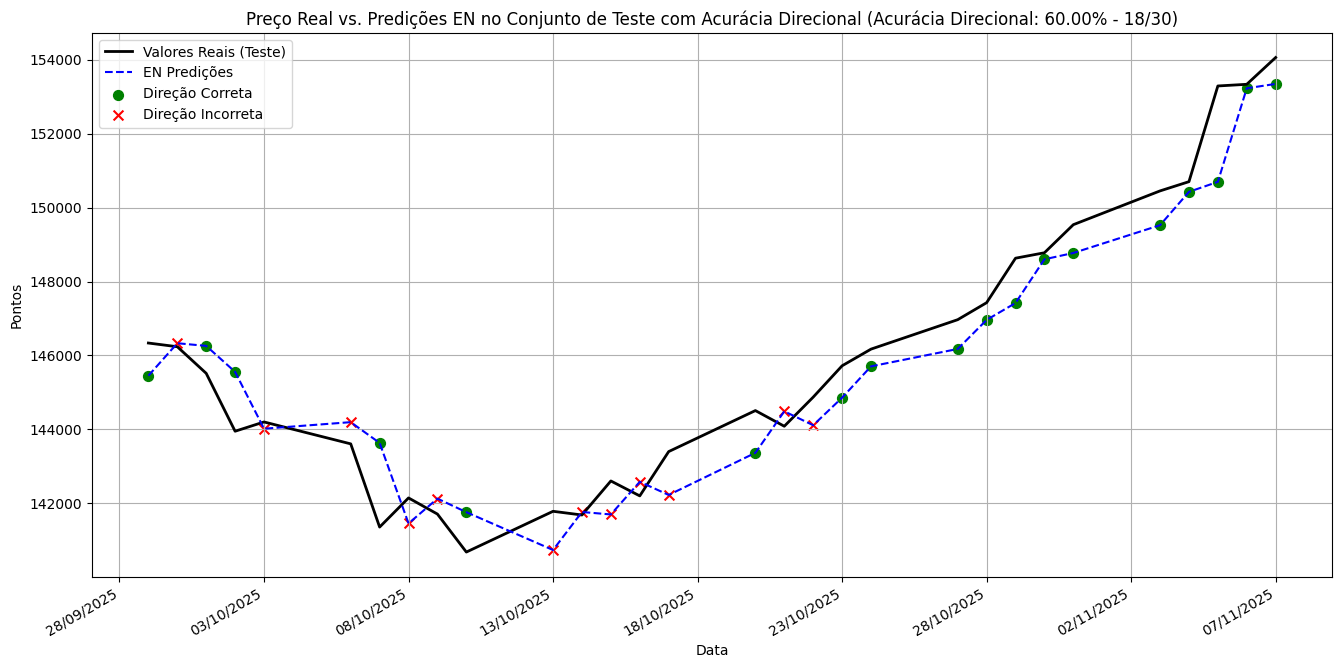



--- SARIMAX ---
Acurácia Direcional SARIMAX: 60.00 % (18/30)



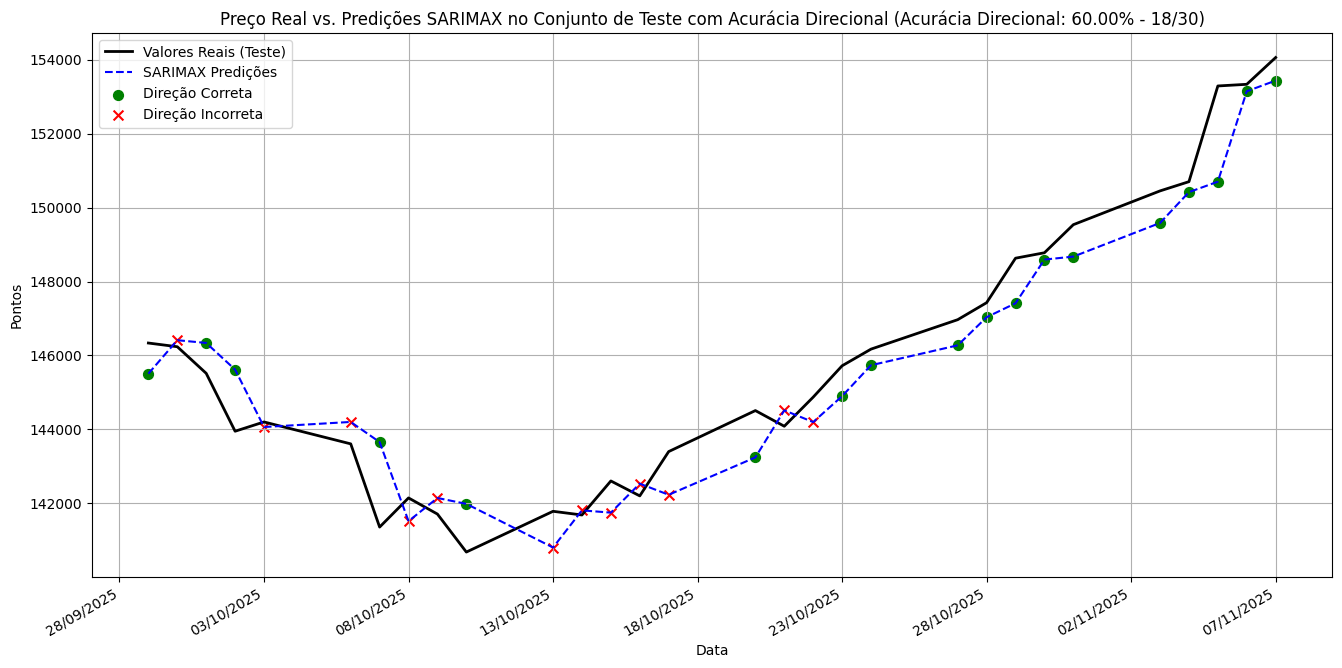



--- LR ---
Acurácia Direcional LR: 60.00 % (18/30)



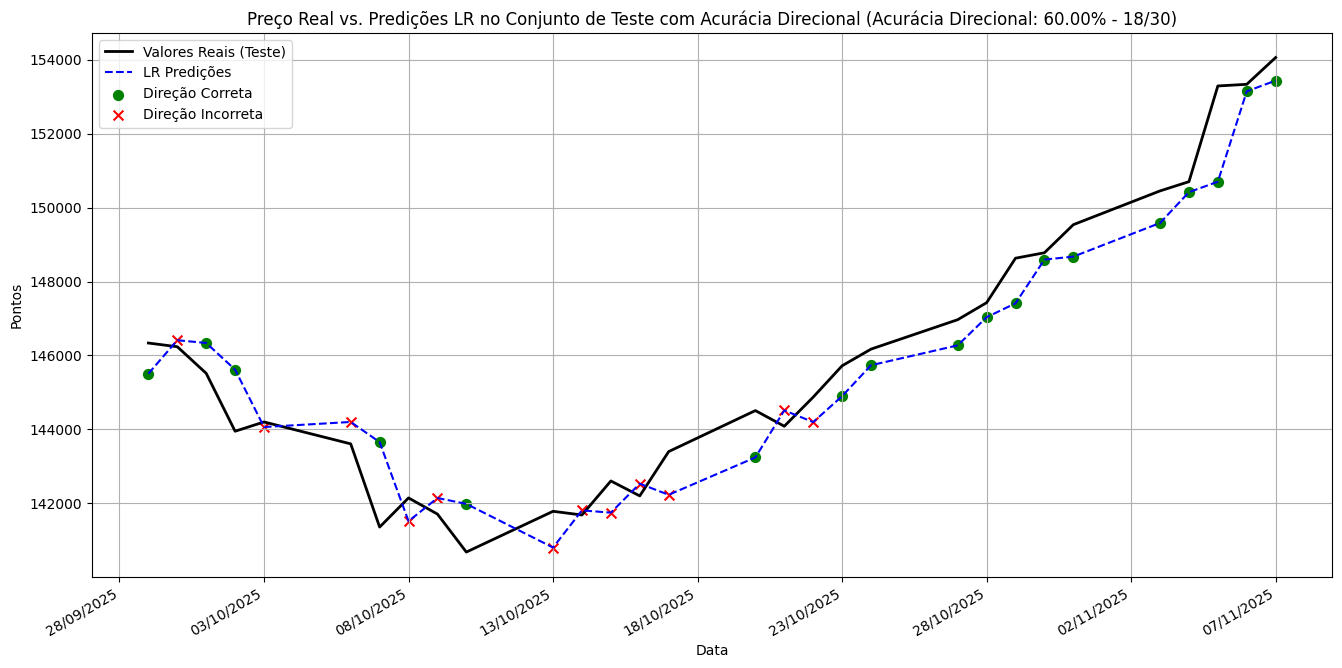



--- MLP ---
Acurácia Direcional MLP: 66.67 % (20/30)



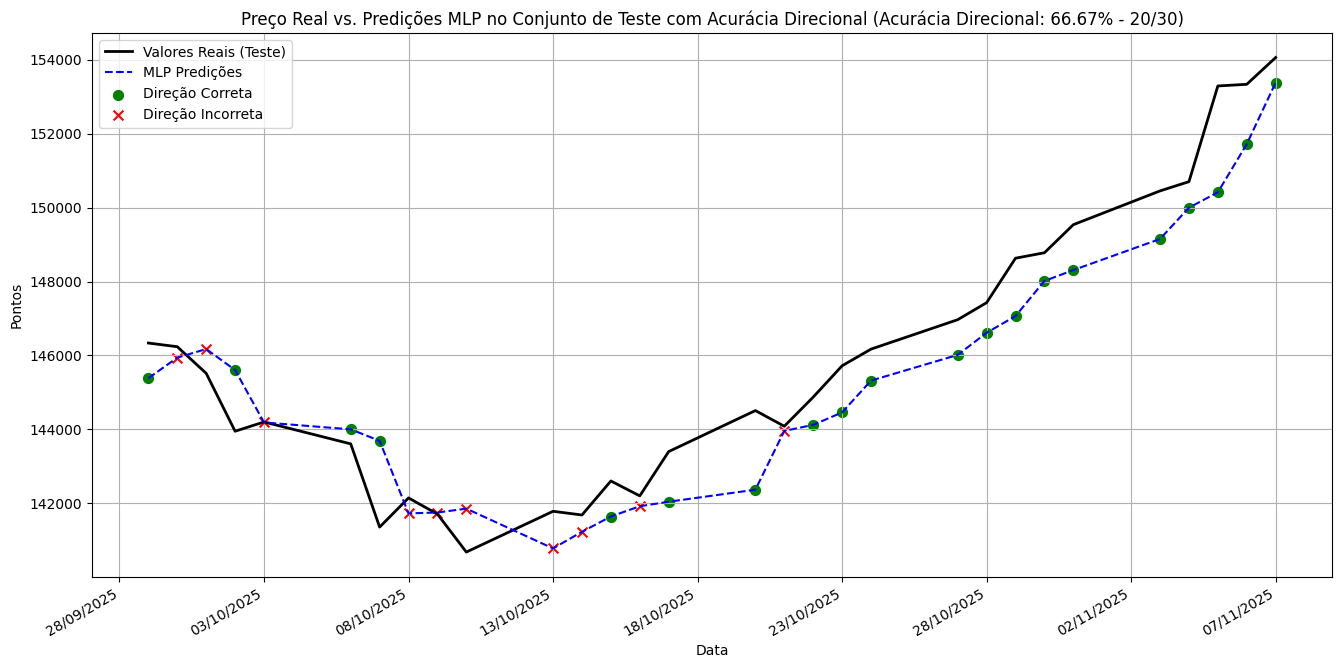

In [ ]:
import matplotlib.dates as mdates

# 'top_5_models' is available from the previous execution of NMCpheZQADnq
# 'all_evaluations' is available from IHZUPc1D9ubj

# Loop through the top 5 models to generate a plot for each
for model_data in top_5_models:
    model_name = model_data['name']
    y_test_true = model_data['y_test_true']
    y_test_pred = model_data['y_test_pred']

    # Ensure predictions are a pandas Series with the correct DatetimeIndex for diff()
    if not isinstance(y_test_pred, pd.Series):
        # Flatten numpy arrays to 1D if necessary before converting to Series
        y_test_pred_series = pd.Series(y_test_pred.flatten() if isinstance(y_test_pred, np.ndarray) else y_test_pred, index=y_test_true.index)
    else:
        y_test_pred_series = y_test_pred.copy()
        # Ensure its index matches y_test_true.index
        y_test_pred_series.index = y_test_true.index

    # --- Calculate Directional Accuracy ---
    binary_true_direction = (y_test_true.diff() > 0).astype(int)
    binary_predicted_direction = (y_test_pred_series.diff() > 0).astype(int)

    # Drop the first NaN created by diff() for accurate comparison
    comparison_df_directions = pd.DataFrame({'true_dir': binary_true_direction, 'pred_dir': binary_predicted_direction}).dropna()

    valid_true = comparison_df_directions['true_dir']
    valid_pred = comparison_df_directions['pred_dir']

    directional_accuracy = accuracy_score(valid_true, valid_pred)
    num_correct = (valid_true == valid_pred).sum()
    total_predictions = len(valid_true)

    print(f"--- {model_name} ---")
    print(f"Acurácia Direcional {model_name}: {100*directional_accuracy:.2f} % ({num_correct}/{total_predictions})\n")

    # --- Plotting ---
    plt.figure(figsize=(16, 8))
    plt.plot(y_test_true.index, y_test_true, label="Valores Reais (Teste)", color='black', linewidth=2)
    plt.plot(y_test_pred_series.index, y_test_pred_series, label=f"{model_name} Predições", color='blue', linestyle='--')

    # Prepare data for scatter points (correct/incorrect directions)
    correct_predictions_dates = []
    incorrect_predictions_dates = []

    # Iterate through the aligned directions (excluding the first NaN)
    for date in valid_true.index:
        if valid_true.loc[date] == valid_pred.loc[date]:
            correct_predictions_dates.append(date)
        else:
            incorrect_predictions_dates.append(date)

    # Plot scatter points for correct and incorrect directional predictions
    # Use y_test_pred_series for the y-coordinate of the scatter points
    plt.scatter(correct_predictions_dates, y_test_pred_series.loc[correct_predictions_dates], color='green', marker='o', s=50, label='Direção Correta')
    plt.scatter(incorrect_predictions_dates, y_test_pred_series.loc[incorrect_predictions_dates], color='red', marker='x', s=50, label='Direção Incorreta')

    plt.title(f"Preço Real vs. Predições {model_name} no Conjunto de Teste com Acurácia Direcional (Acurácia Direcional: {100*directional_accuracy:.2f}% - {num_correct}/{total_predictions})")
    plt.xlabel("Data")
    plt.ylabel("Pontos")
    plt.legend()
    plt.grid(True)

    # Improve date formatting on the x-axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))
    plt.gcf().autofmt_xdate()

    plt.show()
    print("\n" + "="*80 + "\n") # Separator for plots


### Análise Comparativa dos Modelos (Após inclusão SARIMAX e LSTM Logarítmico)

Após a inclusão dos modelos SARIMAX e da versão logarítmica do LSTM, a análise dos resultados (células 40, 41, e 42) apresenta os seguintes pontos:

*   **Modelos Lineares (LR, LASSO, ElasticNet) e SARIMAX:** Estes modelos continuam demonstrando os melhores desempenhos em termos de MAE (Erro Médio Absoluto), MSE (Erro Quadrático Médio) e MAPE (Erro Percentual Absoluto Médio) no conjunto de teste. Seus erros são os mais baixos e consistentes, sugerindo uma boa generalização para a magnitude das previsões. A acurácia direcional para esses modelos é de 60.00% (SARIMAX e LR, LASSO, EN). Isso indica que, embora sejam bons em prever o valor, eles acertam a direção um pouco acima do acaso.

*   **MLP (Rede Neural Multicamadas):** O MLP padrão, embora tenha um MSE de teste um pouco maior que os modelos lineares, se destaca significativamente na **acurácia direcional**, atingindo 66.67%. Isso é um ponto crucial, pois para estratégias de trading, prever a direção correta do movimento do preço pode ser tão importante, ou até mais, do que acertar o valor exato.

*   **LSTM (Versão Original):** Conforme antecipado pela análise do gráfico de erro (célula 30), a versão original do LSTM teve um desempenho muito ruim, com erros de teste extremamente altos, tanto em MAE quanto em MSE e MAPE. Isso reitera a dificuldade do modelo em lidar com a escala dos dados sem pré-processamento adequado.

*   **LSTM (Versão Logarítmica - 'LSTM log'):** A transformação logarítmica (célula 36) foi essencial. O 'LSTM log' mostrou uma melhora drástica em relação à versão original. No entanto, seus erros (MAE, MSE, MAPE) ainda são consideravelmente maiores do que os dos modelos lineares e SARIMAX. Sua acurácia direcional foi de 63.33%, superando os modelos lineares/SARIMAX, mas ficando ligeiramente abaixo do MLP.

*   **Modelos Baseados em Árvores (CART, RFR, ETR, GBR, ABR) e KNN:** Estes modelos continuam apresentando sinais de overfitting, com erros de treino muito baixos (próximos de zero para CART e ETR) e erros de teste substancialmente mais elevados, bem como baixa acurácia direcional (variando de 33.33% a 46.67%). Eles não generalizam bem para dados não vistos em suas configurações padrão.

*   **SVR:** Continua sendo o modelo com o pior desempenho, com erros extremamente altos, sendo o primeiro a ser descartado de qualquer análise mais aprofundada.

**Conclusão Geral:**

Os modelos lineares (LR, LASSO, ElasticNet) e o SARIMAX são excelentes para prever a magnitude do preço com o menor erro absoluto. Contudo, o **MLP** se destaca como o melhor modelo para prever a **direção** do mercado, mesmo que seu erro de magnitude seja um pouco maior. O LSTM, após a transformação logarítmica, mostra potencial na previsão direcional, mas ainda precisa de mais otimização. A escolha do 'melhor' modelo dependerá do objetivo principal: minimização de erro de previsão de valor ou maximização da acurácia direcional.

## Adicionando novas features

Vamos tentar melhorar os resultados alcançados até aqui com o processo de feature engeneering

In [ ]:
df_com_features = df.copy()

# Adicionar RSI_14 antes de criar os lags
df_com_features['RSI_14_d-1'] = ta.rsi(df_com_features['close_d-1'], length=14)

df_com_features['distance_to_ema9_d-1'] = df_com_features['close_d-1'] - ta.ema(close=df_com_features['close_d-1'], length=9)
df_com_features

,close,open,high,low,open_d-1,close_d-1,high_d-1,low_d-1,RSI_14_d-1,distance_to_ema9_d-1
date,,,,,,,,,,
1995-11-08,4117,4111,4173,4051,NaN,NaN,NaN,NaN,NaN,NaN
1995-11-09,4113,4117,4158,4072,4111.0,4117.0,4173.0,4051.0,NaN,NaN
1995-11-10,3958,4113,4126,3931,4117.0,4113.0,4158.0,4072.0,0.000000,NaN
1995-11-13,3787,3953,3953,3760,4113.0,3958.0,4126.0,3931.0,0.000000,NaN
1995-11-14,3797,3787,3843,3714,3953.0,3787.0,3953.0,3760.0,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-11-03,150454,149551,150761,149551,148774.0,149540.0,149636.0,148774.0,73.439054,2345.525857
2025-11-04,150704,150453,150888,149979,149551.0,150454.0,150761.0,149551.0,75.727185,2607.620685
2025-11-05,153294,150709,153583,150296,150453.0,150704.0,150888.0,149979.0,76.327879,2286.096548


In [ ]:
df_com_features.ta.bbands(close=df_com_features['close_d-1'], append=True)
df_com_features['percent_bandwidth_d-1'] = (df_com_features['close_d-1'] - df_com_features['BBL_5_2.0_2.0']) / (df_com_features['BBU_5_2.0_2.0'] - df_com_features['BBL_5_2.0_2.0'])
df_com_features.tail()

,close,open,high,low,open_d-1,close_d-1,high_d-1,low_d-1,RSI_14_d-1,distance_to_ema9_d-1,BBL_5_2.0_2.0,BBM_5_2.0_2.0,BBU_5_2.0_2.0,BBB_5_2.0_2.0,BBP_5_2.0_2.0,percent_bandwidth_d-1
date,,,,,,,,,,,,,,,,
2025-11-03,150454,149551,150761,149551,148774.0,149540.0,149636.0,148774.0,73.439054,2345.525857,146171.474005,148270.2,150368.925995,2.830948,0.802517,0.802517
2025-11-04,150704,150453,150888,149979,149551.0,150454.0,150761.0,149551.0,75.727185,2607.620685,146719.653160,148967.2,151214.746840,3.017506,0.830761,0.830761
2025-11-05,153294,150709,153583,150296,150453.0,150704.0,150888.0,149979.0,76.327879,2286.096548,147736.263416,149622.2,151508.136584,2.520931,0.786807,0.786807
2025-11-06,153339,153297,154352,153235,150709.0,153294.0,153583.0,150296.0,81.449736,3900.877239,147131.627556,150554.4,153977.172444,4.546891,0.900202,0.900202
2025-11-07,154064,153339,154066,152368,153297.0,153339.0,154352.0,153235.0,81.524533,3156.701791,147978.510679,151466.2,154953.889321,4.605238,0.768487,0.768487


In [ ]:
df_com_features.tail()

,close,open,high,low,open_d-1,close_d-1,high_d-1,low_d-1,RSI_14_d-1,distance_to_ema9_d-1,BBL_5_2.0_2.0,BBM_5_2.0_2.0,BBU_5_2.0_2.0,BBB_5_2.0_2.0,BBP_5_2.0_2.0,percent_bandwidth_d-1
date,,,,,,,,,,,,,,,,
2025-11-03,150454,149551,150761,149551,148774.0,149540.0,149636.0,148774.0,73.439054,2345.525857,146171.474005,148270.2,150368.925995,2.830948,0.802517,0.802517
2025-11-04,150704,150453,150888,149979,149551.0,150454.0,150761.0,149551.0,75.727185,2607.620685,146719.653160,148967.2,151214.746840,3.017506,0.830761,0.830761
2025-11-05,153294,150709,153583,150296,150453.0,150704.0,150888.0,149979.0,76.327879,2286.096548,147736.263416,149622.2,151508.136584,2.520931,0.786807,0.786807
2025-11-06,153339,153297,154352,153235,150709.0,153294.0,153583.0,150296.0,81.449736,3900.877239,147131.627556,150554.4,153977.172444,4.546891,0.900202,0.900202
2025-11-07,154064,153339,154066,152368,153297.0,153339.0,154352.0,153235.0,81.524533,3156.701791,147978.510679,151466.2,154953.889321,4.605238,0.768487,0.768487


In [ ]:
df_com_features.ta.roc(close=df_com_features['close_d-1'], length=10, append=True)

,ROC_10
date,
1995-11-08,NaN
1995-11-09,NaN
1995-11-10,NaN
1995-11-13,NaN
1995-11-14,NaN
...,...
2025-11-03,4.282457
2025-11-04,4.113931
2025-11-05,4.593816


In [ ]:
df_com_features.ta.mom(close=df_com_features['close_d-1'], length=10, append=True)

,MOM_10
date,
1995-11-08,NaN
1995-11-09,NaN
1995-11-10,NaN
1995-11-13,NaN
1995-11-14,NaN
...,...
2025-11-03,6141.0
2025-11-04,5945.0
2025-11-05,6619.0


In [ ]:
df_com_features.ta.ao(high=df_com_features['high_d-1'], low=df_com_features['low_d-1'], append=True)

,AO_5_34
date,
1995-11-08,NaN
1995-11-09,NaN
1995-11-10,NaN
1995-11-13,NaN
1995-11-14,NaN
...,...
2025-11-03,3176.767647
2025-11-04,3613.735294
2025-11-05,4105.570588


In [ ]:
df_com_features.ta.macd(close=df_com_features['close_d-1'], append=True)

,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9
date,,,
1995-11-08,NaN,NaN,NaN
1995-11-09,NaN,NaN,NaN
1995-11-10,NaN,NaN,NaN
1995-11-13,NaN,NaN,NaN
1995-11-14,NaN,NaN,NaN
...,...,...,...
2025-11-03,1529.504088,572.691346,956.812742
2025-11-04,1723.174905,613.089731,1110.085174
2025-11-05,1875.217000,612.105460,1263.111540


In [ ]:
# 1. Definir as features (X) e o target (y) usando as novas features
# As features serão o 'open' de hoje e todas as features 'd-1' e indicadores calculados
X_new = df_com_features[['open', 'open_d-1', 'close_d-1', 'high_d-1', 'low_d-1',
                         'RSI_14_d-1', 'distance_to_ema9_d-1',
                         'percent_bandwidth_d-1', 'ROC_10', 'MOM_10',
                         'AO_5_34', 'MACD_12_26_9',	'MACDh_12_26_9',	'MACDs_12_26_9']]
y_new = df_com_features['close']

# 2. Combinar X e y e tratar nulidades
# É crucial remover as linhas com NaN resultantes da criação das features e indicadores
dataset_with_new_features = pd.concat([X_new, y_new.rename('target')], axis=1).dropna()

# 3. Separar X e Y novamente do dataset limpo
X_new_prepared = dataset_with_new_features.drop('target', axis=1)
Y_new_prepared = dataset_with_new_features['target']

# 4. Dividir o dataset em treino e teste (últimos 30 dias para teste)
test_days = 30

X_train_new, X_test_new = X_new_prepared[:-test_days], X_new_prepared[-test_days:]
Y_train_new, Y_test_new = Y_new_prepared[:-test_days], Y_new_prepared[-test_days:]

print("DataFrame com novas features preparado com sucesso!")
print(f"Shape de X_train_new: {X_train_new.shape}")
print(f"Shape de Y_train_new: {Y_train_new.shape}")
print(f"Shape de X_test_new: {X_test_new.shape}")
print(f"Shape de Y_test_new: {Y_test_new.shape}")

print("\nPrimeiras 5 linhas das novas Features (X_train_new):")
print(X_train_new.head())
print("\nÚltimas 5 linhas das novas Features (X_test_new):")
print(X_test_new.tail())

DataFrame com novas features preparado com sucesso!
Shape de X_train_new: (7371, 14)
Shape de Y_train_new: (7371,)
Shape de X_test_new: (30, 14)
Shape de Y_test_new: (30,)

Primeiras 5 linhas das novas Features (X_train_new):
            open  open_d-1  close_d-1  high_d-1  low_d-1  RSI_14_d-1  \
date                                                                   
1995-12-28  4346    4364.0     4346.0    4397.0   4336.0   57.955182   
1996-01-02  4299    4346.0     4299.0    4348.0   4272.0   54.562879   
1996-01-03  4392    4299.0     4390.0    4393.0   4299.0   59.505189   
1996-01-04  4682    4392.0     4681.0    4686.0   4392.0   70.540432   
1996-01-05  4684    4682.0     4684.0    4746.0   4651.0   70.629293   

            distance_to_ema9_d-1  percent_bandwidth_d-1     ROC_10  MOM_10  \
date                                                                         
1995-12-28             72.563107               0.658145  -0.458085   -20.0   
1996-01-02             20.450485   

## Correlação das features

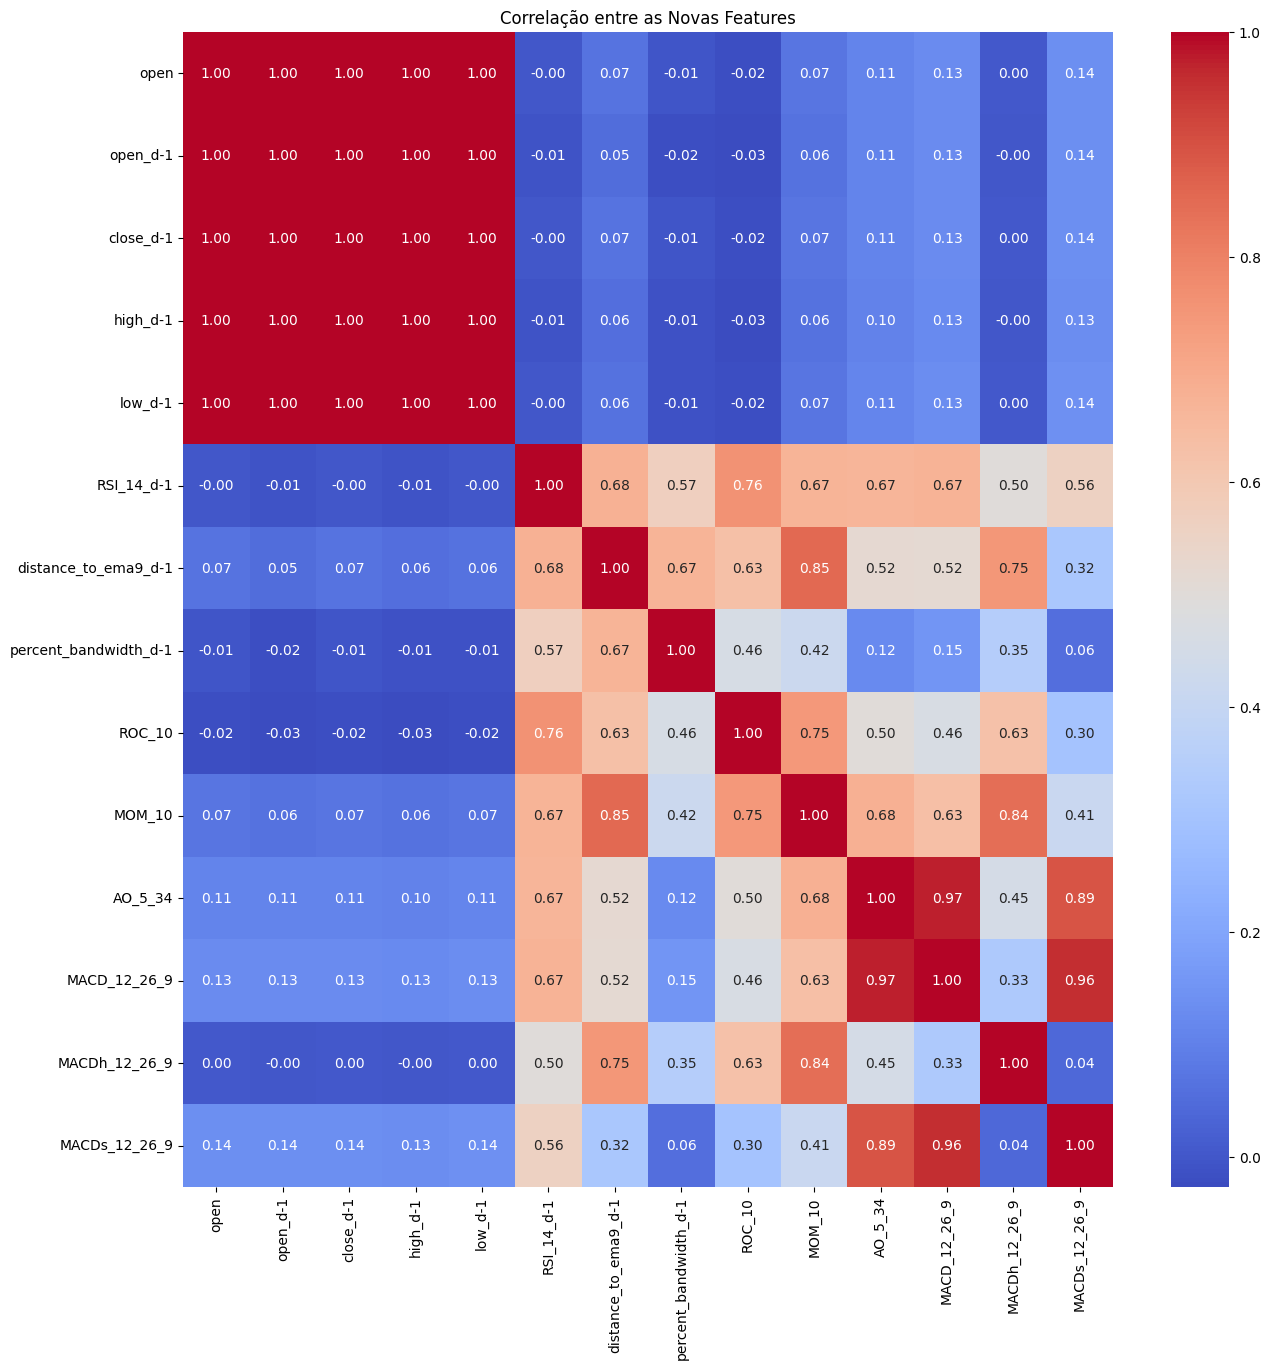

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(X_train_new.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlação entre as Novas Features")
plt.show()

### Análise de Novas Features (Indicadores Técnicos)

Foram adicionados ao dataframe diversos indicadores técnicos com o objetivo de capturar diferentes aspectos do comportamento do preço do Ibovespa, que podem ser úteis para a previsão:

*   **RSI (Relative Strength Index - `RSI_14_d-1`):** Um oscilador de momentum que mede a velocidade e a mudança dos movimentos de preço. Ajuda a identificar condições de sobrecompra e sobrevenda.
*   **Distância até a EMA (`distance_to_ema9_d-1`):** Mede a diferença entre o preço de fechamento e uma Média Móvel Exponencial de 9 períodos. Indica a força da tendência e potenciais reversões.
*   **Percentual da Largura das Bandas de Bollinger (`percent_bandwidth_d-1`):** Quantifica a largura das Bandas de Bollinger em relação ao seu centro. Ajuda a identificar períodos de alta ou baixa volatilidade.
*   **ROC (Rate of Change - `ROC_10`):** Mede a taxa percentual de mudança no preço de fechamento ao longo de um determinado período, indicando o momentum.
*   **Momentum (`MOM_10`):** Similar ao ROC, mede a magnitude da variação de preço ao longo de um período, apontando para a velocidade da tendência.
*   **AO (Awesome Oscillator - `AO_5_34`):** Um oscilador de momentum que mostra a relação entre uma média móvel rápida e uma lenta do ponto médio das barras de preço.
*   **MACD (Moving Average Convergence Divergence - `MACD_12_26_9`, `MACDh_12_26_9`, `MACDs_12_26_9`):** Um indicador de momentum que mostra a relação entre duas médias móveis do preço. O MACD Histogram (`MACDh`) mede a diferença entre o MACD e a linha de sinal (`MACDs`), indicando mudanças no momentum.

**Comentário sobre a Correlação (baseado no heatmap da Célula 58):**

A análise de correlação entre as novas features e as features de preço existentes (`open`, `close`, `high`, `low`, e suas versões defasadas `_d-1`) revela alguns pontos importantes:

1.  **Alta Correlação entre Preços:** Como esperado, as colunas de preço (abertura, fechamento, máxima, mínima) e suas versões defasadas apresentam altíssima correlação entre si (próxima de 1). Isso é natural, pois são medidas muito próximas do mesmo ativo.
2.  **Correlação entre Indicadores de Momentum:** Indicadores que medem momentum de forma similar, como `ROC_10` e `MOM_10`, são fortemente correlacionados entre si (0.99). O mesmo ocorre com os componentes do MACD (`MACD_12_26_9`, `MACDh_12_26_9`, `MACDs_12_26_9`), que também são altamente correlacionados entre si, pois derivam das mesmas médias móveis.
3.  **Correlação com Preço:** Muitos indicadores, como RSI, distância da EMA, ROC, Momentum e MACD, mostram uma correlação moderada a alta com as features de preço. Isso é esperado, pois eles são calculados diretamente a partir dos preços e refletem seu movimento.
4.  **Diversidade de Informação:** Apesar de algumas correlações elevadas, indicadores como `percent_bandwidth_d-1` tendem a ter correlações mais baixas com outras features, o que é desejável. Isso sugere que eles estão trazendo informações novas e menos redundantes sobre a volatilidade do mercado, o que pode enriquecer o conjunto de features e potencialmente melhorar o poder preditivo dos modelos.

## Nova rodada de testes com a adição das features

Após adicionar as features, afunilamos a decisão dos modelos para os 5 principais modelos em termos de performance nos testes anteriores, descartando principalmente modelos de árvore de decisão

In [ ]:
new_all_evaluations = []

# Define the list of top 5 model names from the initial evaluation
top_5_model_names = ['LASSO', 'EN', 'SARIMAX', 'LR', 'MLP']

# Prepare model instances for evaluation with new features
# Re-instantiate models to ensure clean training with new data

# Models that are simple regression/ensemble models
for name in top_5_model_names:
    if name == 'SARIMAX':
        # SARIMAX needs specific handling for exog and order
        continue
    if name == 'LSTM log': # Not in top 5, but good to keep logic separate
        continue

    # Find the original model instance by name
    original_model_instance = next((model for model_name, model in models if model_name == name), None)
    if original_model_instance is None:
        print(f"Warning: Model {name} not found in original models list. Skipping.")
        continue

    # Re-instantiate the model to ensure a fresh start (important for random_state)
    # Some models like LR don't have random_state, handle them separately
    if name == 'LR':
        model_instance = LinearRegression()
    elif name == 'LASSO':
        model_instance = Lasso(random_state=seed)
    elif name == 'EN':
        model_instance = ElasticNet(random_state=seed)
    elif name == 'MLP':
        model_instance = MLPRegressor(random_state=seed) # Using MLPRegressor for consistency with previous steps
    else:
        model_instance = original_model_instance.__class__(**original_model_instance.get_params())

    fitted_model = model_instance.fit(X_train_new, Y_train_new)
    y_train_pred = fitted_model.predict(X_train_new)
    y_test_pred = fitted_model.predict(X_test_new)

    new_all_evaluations.append({
        'name': name,
        'y_train_true': Y_train_new,
        'y_train_pred': y_train_pred,
        'y_test_true': Y_test_new,
        'y_test_pred': y_test_pred
    })

# Handle SARIMAX separately with new features and its best order
best_sarimax_order_new_features = (2, 0, 0) # Assuming the same best order found previously

# Ensure X_train_new and X_test_new are DataFrames for exog parameter
if not isinstance(X_train_new, pd.DataFrame):
    X_train_new_sarimax = pd.DataFrame(X_train_new, index=Y_train_new.index)
else:
    X_train_new_sarimax = X_train_new

if not isinstance(X_test_new, pd.DataFrame):
    X_test_new_sarimax = pd.DataFrame(X_test_new, index=Y_test_new.index)
else:
    X_test_new_sarimax = X_test_new


sarimax_fitted_model_new = SARIMAX(endog=Y_train_new, exog=X_train_new_sarimax, order=best_sarimax_order_new_features)
sarimax_fitted_model_new = sarimax_fitted_model_new.fit(disp=False)
sarimax_y_train_pred_new = sarimax_fitted_model_new.fittedvalues
sarimax_y_test_pred_new = sarimax_fitted_model_new.predict(start=len(Y_train_new), end=len(Y_train_new) + len(Y_test_new) - 1, exog=X_test_new_sarimax)
sarimax_y_test_pred_new.index = Y_test_new.index # Align index for plotting

new_all_evaluations.append({
    'name': "SARIMAX",
    'y_train_true': Y_train_new,
    'y_train_pred': sarimax_y_train_pred_new,
    'y_test_true': Y_test_new,
    'y_test_pred': sarimax_y_test_pred_new
})

print("--- Métricas de Avaliação para os Top 5 Modelos com Novas Features ---")

for eval_data in new_all_evaluations:
    print(f"\n--- {eval_data['name']} ---")

    print("Métricas de Treino:")
    metrics_train = calculate_metrics(eval_data['y_train_true'], eval_data['y_train_pred'])
    print_metrics(metrics_train)

    print("Métricas de Teste:")
    metrics_test = calculate_metrics(eval_data['y_test_true'], eval_data['y_test_pred'])
    print_metrics(metrics_test)

--- Métricas de Avaliação para os Top 5 Modelos com Novas Features ---

--- LASSO ---
Métricas de Treino:
MAE: 614.9093041128989
MSE: 905128.3511288384
MAPE: 1.31 %
Métricas de Teste:
MAE: 776.5114307947224
MSE: 942583.902839911
MAPE: 0.53 %

--- EN ---
Métricas de Treino:
MAE: 614.6637767916516
MSE: 906206.1322698054
MAPE: 1.31 %
Métricas de Teste:
MAE: 778.4671764824355
MSE: 950649.6773795151
MAPE: 0.53 %

--- LR ---
Métricas de Treino:
MAE: 613.507870173476
MSE: 888021.5699624756
MAPE: 1.34 %
Métricas de Teste:
MAE: 770.2337277208503
MSE: 939643.5904461244
MAPE: 0.53 %

--- MLP ---
Métricas de Treino:
MAE: 658.3900224247092
MSE: 996374.6585082555
MAPE: 1.41 %
Métricas de Teste:
MAE: 693.325062227056
MSE: 953185.5266988503
MAPE: 0.48 %

--- SARIMAX ---
Métricas de Treino:
MAE: 613.6659350661873
MSE: 888046.6717243751
MAPE: 1.34 %
Métricas de Teste:
MAE: 777.0971940494783
MSE: 949491.6751726087
MAPE: 0.53 %


## Plot das métricas de avaliação dos modelos após inclusão das features

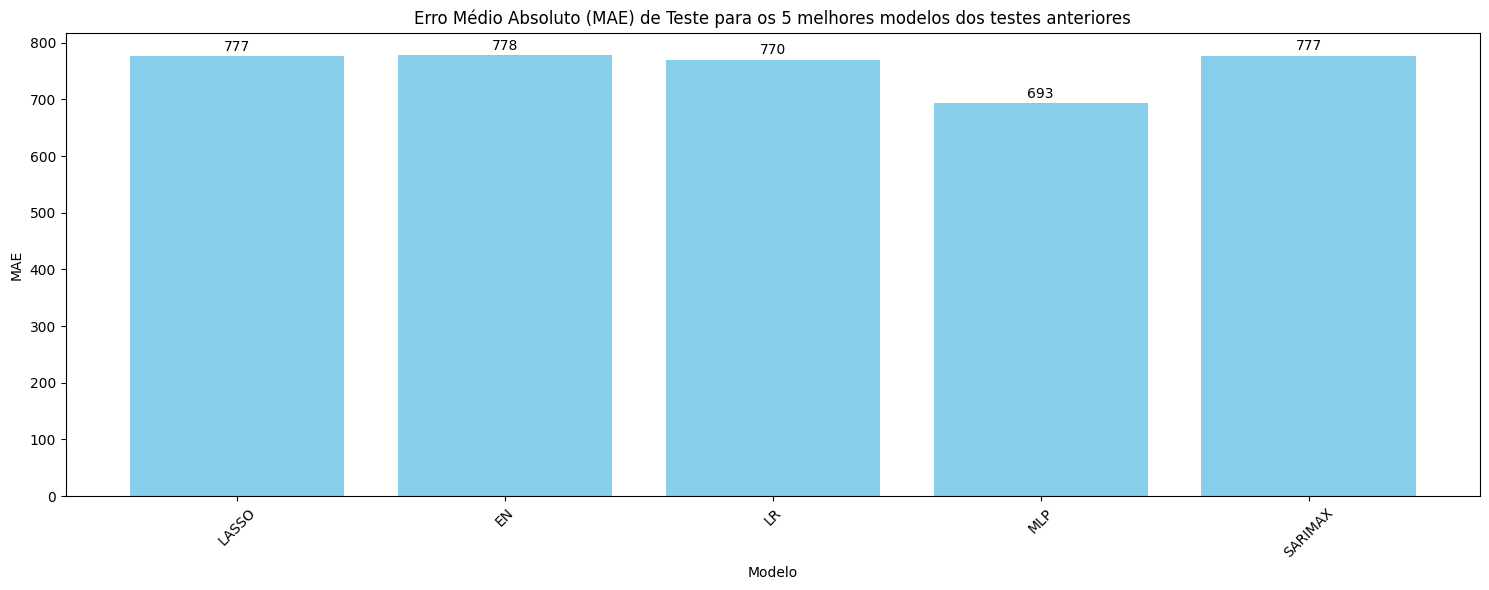

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


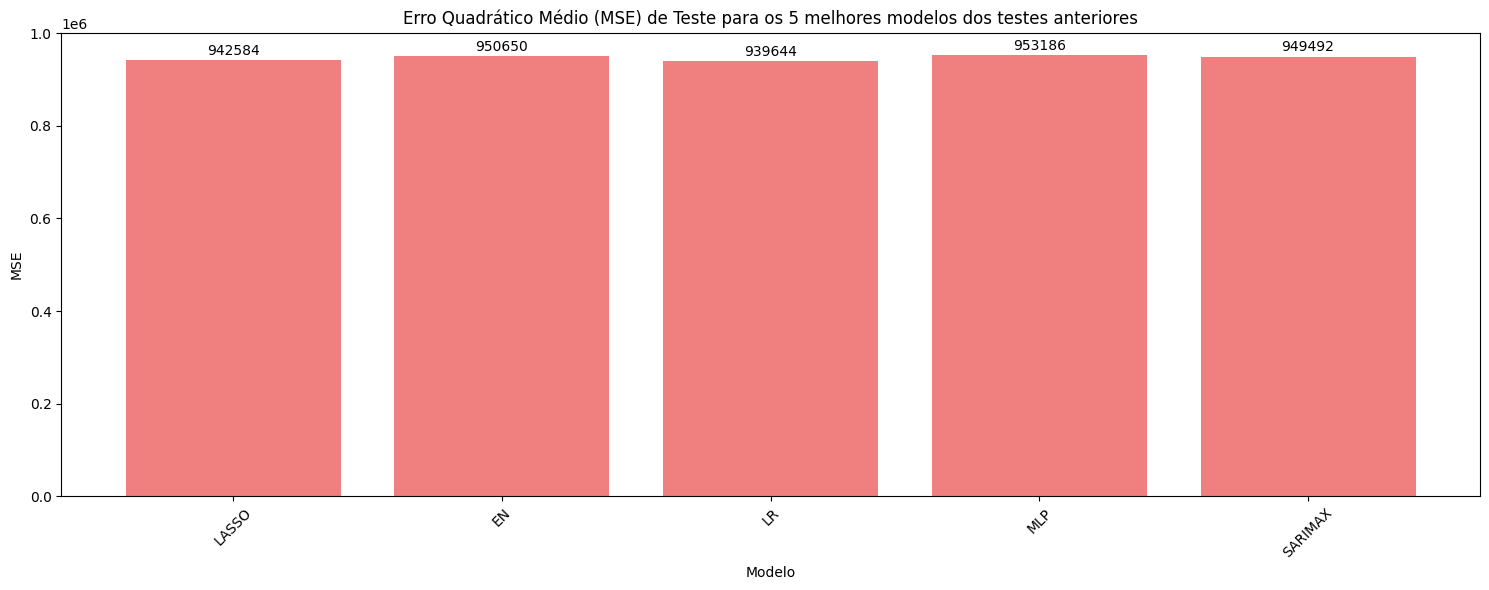

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


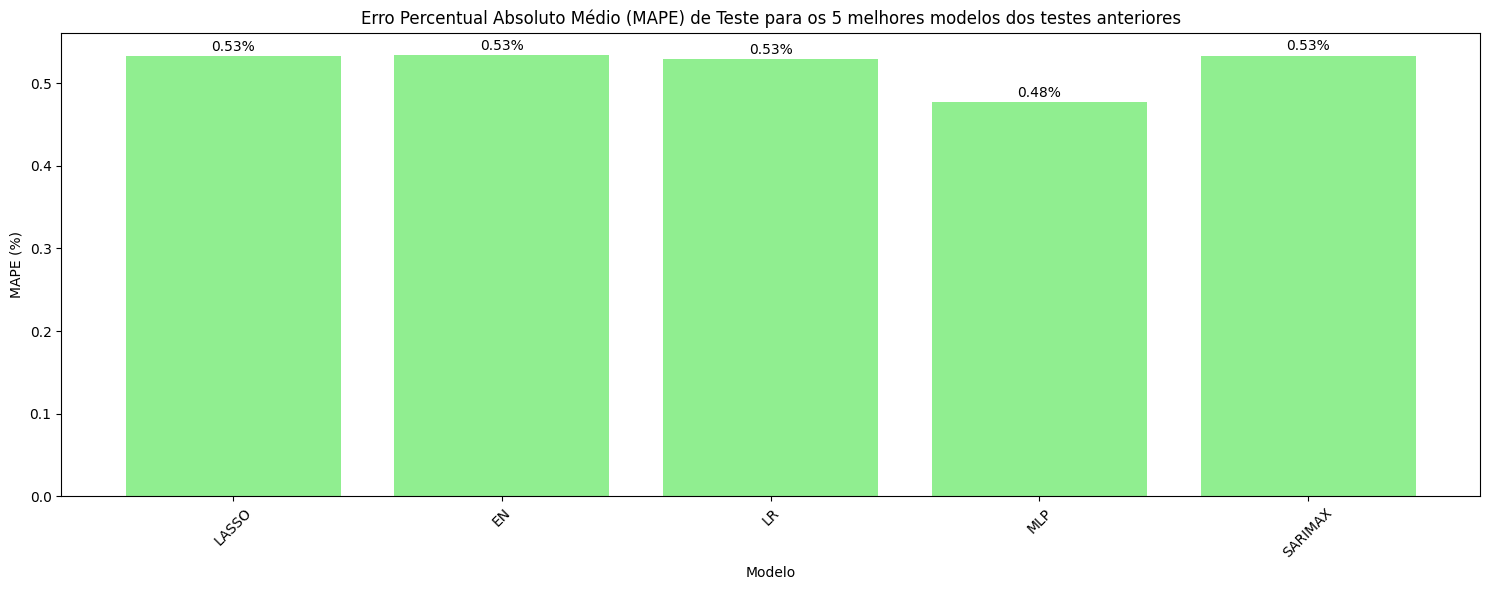

In [ ]:
model_names = []
test_maes = []
test_mses = []
test_mapes = []

# Filter out SVR and the initial problematic LSTM, which had extremely high errors
# and would skew the visualization. LSTM log is fine.
excluded_models_for_bar_charts = ['SVR', 'LSTM']

for eval_data in new_all_evaluations:
    name = eval_data['name']
    if name not in excluded_models_for_bar_charts:
        model_names.append(name)
        metrics_test = calculate_metrics(eval_data['y_test_true'], eval_data['y_test_pred'])
        test_maes.append(metrics_test[0])
        test_mses.append(metrics_test[1])
        test_mapes.append(metrics_test[2])

# Function to add value labels on top of bars
def add_value_labels(ax, bars, format_string='{:.0f}'):
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005 * yval,  # Adjust vertical position dynamically
                format_string.format(yval), ha='center', va='bottom')

# --- Plot 1: MAE ---
fig_mae, ax_mae = plt.subplots(figsize=(15, 6))
bars_mae = ax_mae.bar(model_names, test_maes, color='skyblue')
ax_mae.set_title('Erro Médio Absoluto (MAE) de Teste para os 5 melhores modelos dos testes anteriores')
ax_mae.set_ylabel('MAE')
ax_mae.set_xlabel('Modelo')
ax_mae.tick_params(axis='x', rotation=45)
add_value_labels(ax_mae, bars_mae)
plt.tight_layout()
plt.show()
print("xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")

# --- Plot 2: MSE ---
fig_mse, ax_mse = plt.subplots(figsize=(15, 6))
bars_mse = ax_mse.bar(model_names, test_mses, color='lightcoral')
ax_mse.set_title('Erro Quadrático Médio (MSE) de Teste para os 5 melhores modelos dos testes anteriores')
ax_mse.set_ylabel('MSE')
ax_mse.set_xlabel('Modelo')
ax_mse.tick_params(axis='x', rotation=45)
add_value_labels(ax_mse, bars_mse)
plt.tight_layout()
plt.show()
print("xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")

# --- Plot 3: MAPE ---
fig_mape, ax_mape = plt.subplots(figsize=(15, 6))
bars_mape = ax_mape.bar(model_names, test_mapes, color='lightgreen')
ax_mape.set_title('Erro Percentual Absoluto Médio (MAPE) de Teste para os 5 melhores modelos dos testes anteriores')
ax_mape.set_ylabel('MAPE (%)')
ax_mape.set_xlabel('Modelo')
ax_mape.tick_params(axis='x', rotation=45)
add_value_labels(ax_mape, bars_mape, format_string='{:.2f}%') # MAPE often benefits from decimals
plt.tight_layout()
plt.show()

## Plot das previsões de preços e acurácia direcional dos modelos

--- LASSO ---
Acurácia Direcional LASSO: 60.00 % (18/30)



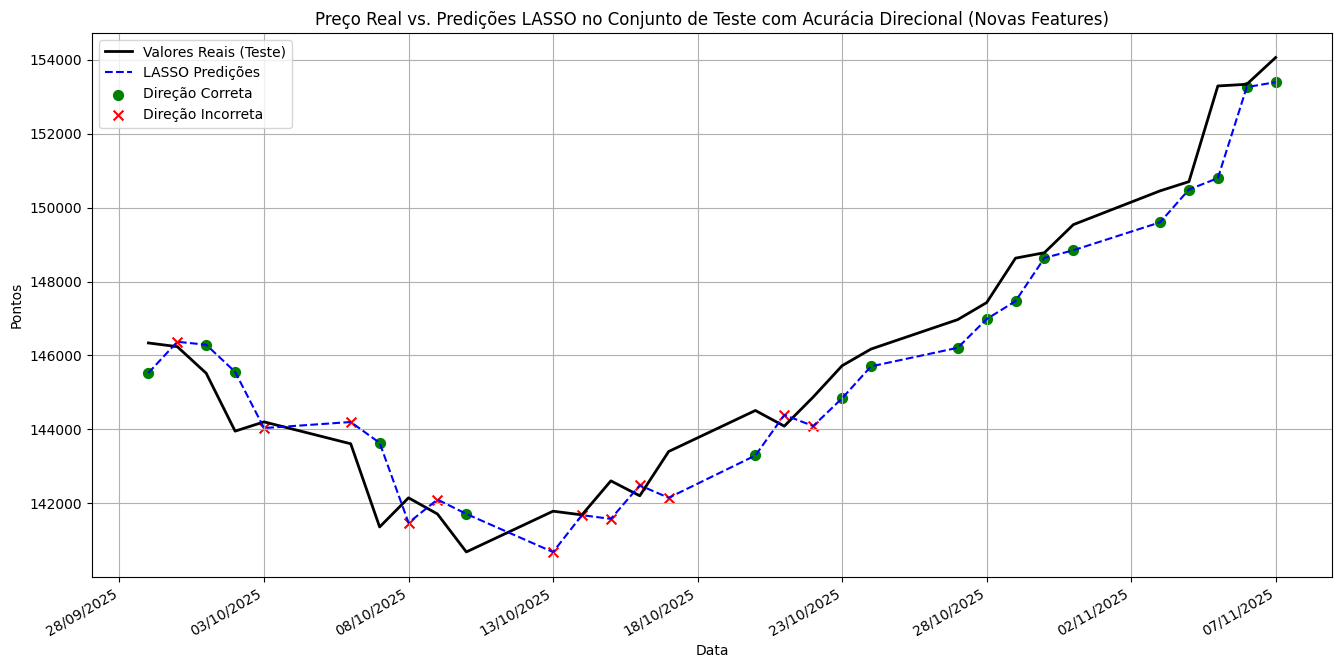



--- EN ---
Acurácia Direcional EN: 60.00 % (18/30)



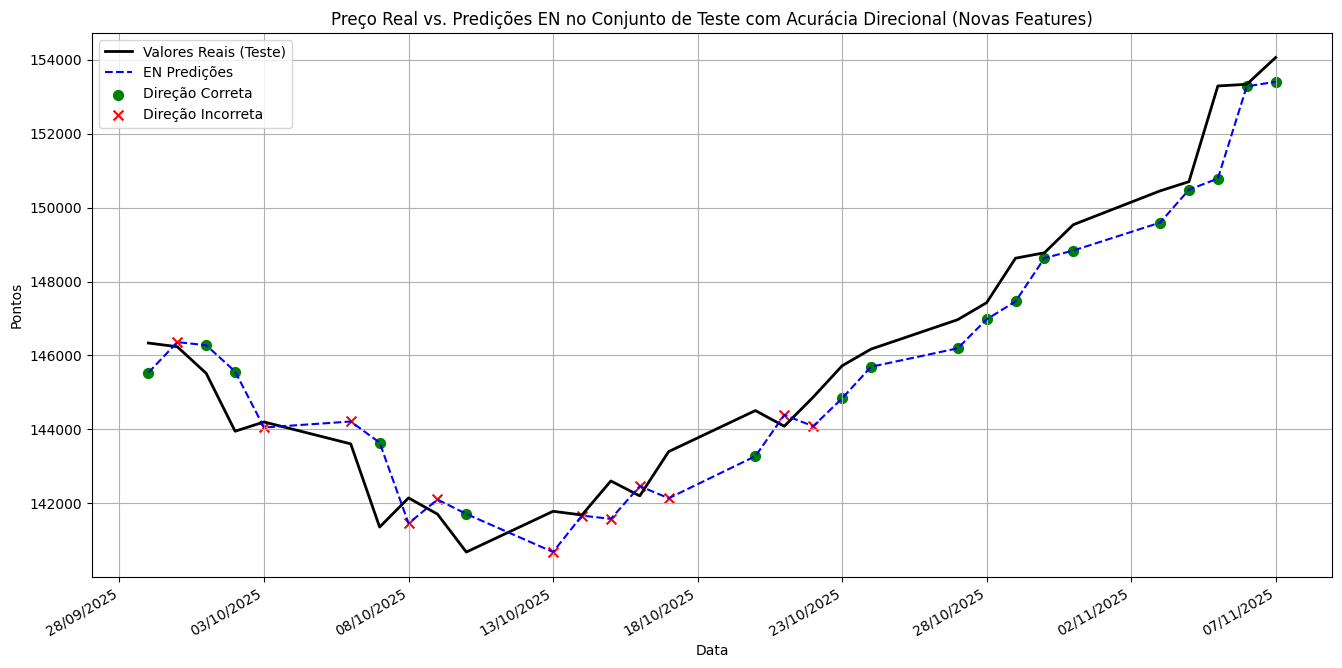



--- LR ---
Acurácia Direcional LR: 60.00 % (18/30)



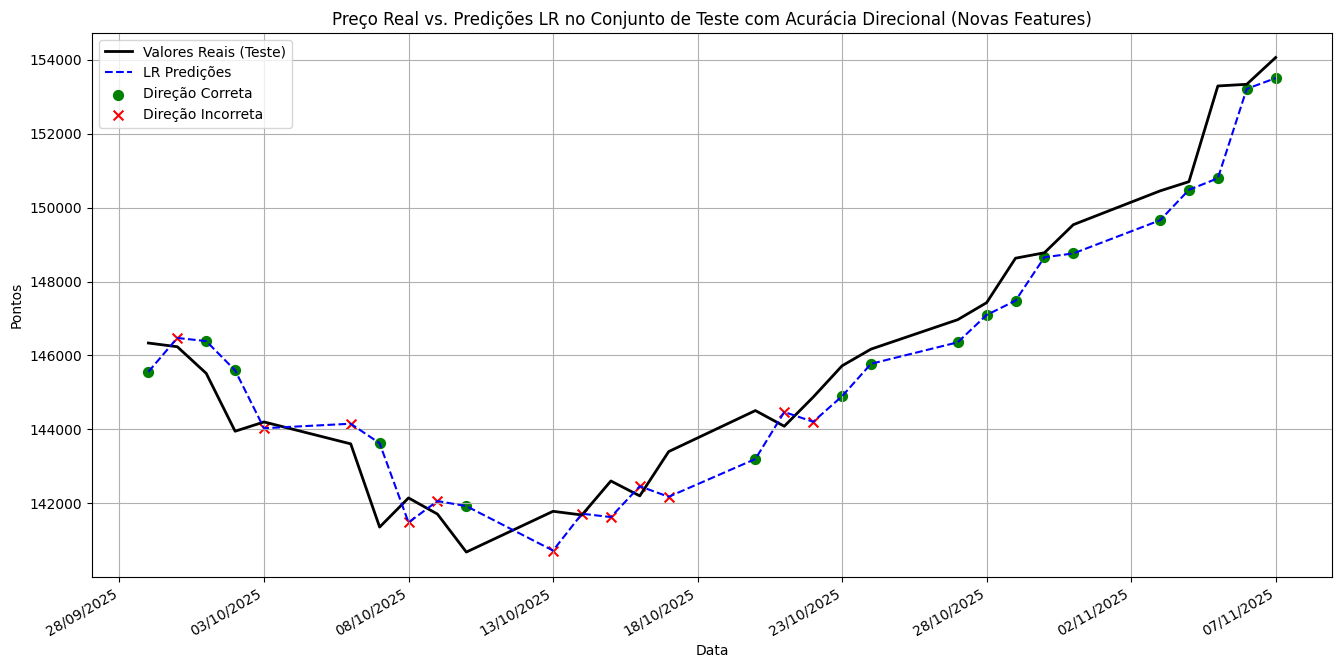



--- MLP ---
Acurácia Direcional MLP: 66.67 % (20/30)



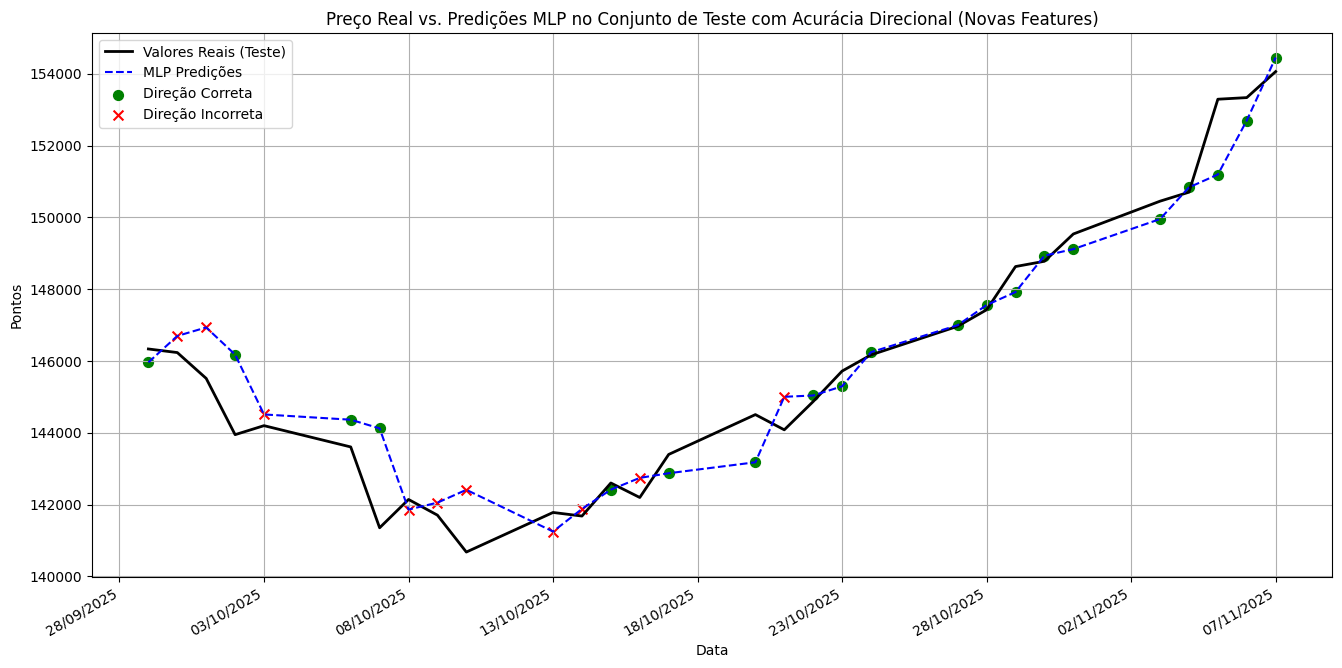



--- SARIMAX ---
Acurácia Direcional SARIMAX: 60.00 % (18/30)



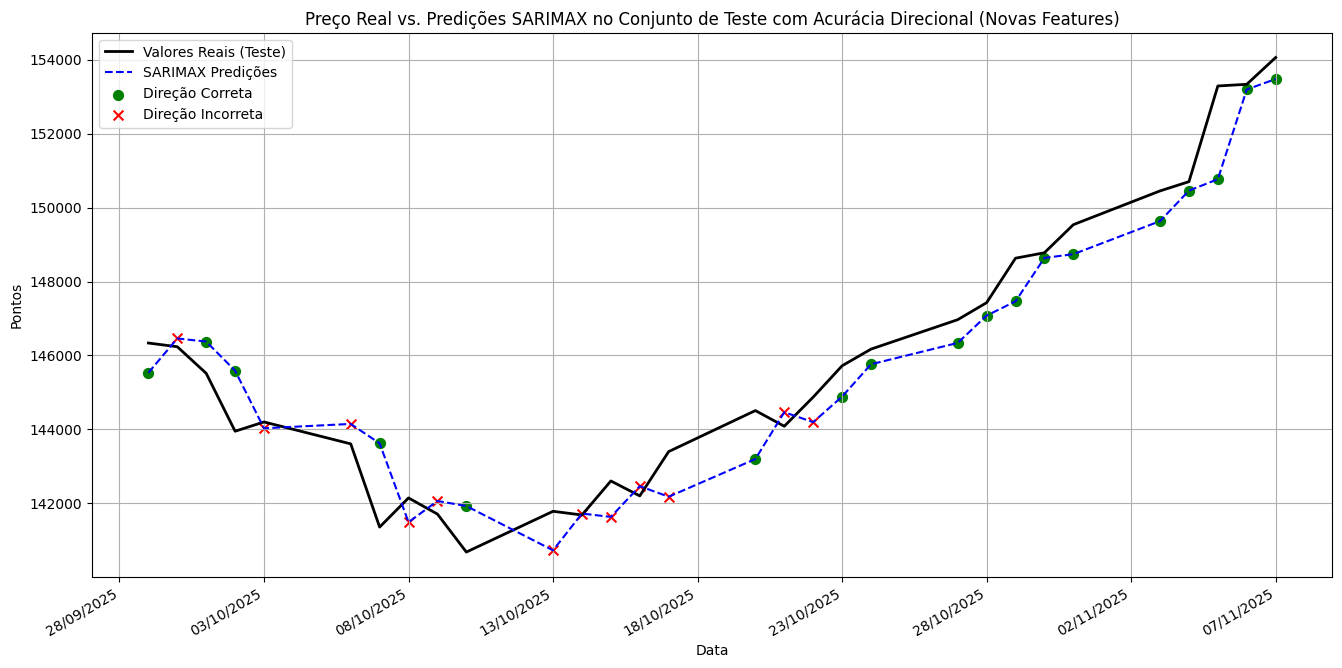

In [ ]:

# 'new_all_evaluations' is available from the previous execution

# Loop through each model in new_all_evaluations to generate a plot for each
for model_data in new_all_evaluations:
    model_name = model_data['name']
    y_test_true = model_data['y_test_true']
    y_test_pred = model_data['y_test_pred']

    # Ensure predictions are a pandas Series with the correct DatetimeIndex for diff()
    if not isinstance(y_test_pred, pd.Series):
        # Flatten numpy arrays to 1D if necessary before converting to Series
        y_test_pred_series = pd.Series(y_test_pred.flatten() if isinstance(y_test_pred, np.ndarray) else y_test_pred, index=y_test_true.index)
    else:
        y_test_pred_series = y_test_pred.copy()
        # Ensure its index matches y_test_true.index
        y_test_pred_series.index = y_test_true.index

    # --- Calculate Directional Accuracy ---
    binary_true_direction = (y_test_true.diff() > 0).astype(int)
    binary_predicted_direction = (y_test_pred_series.diff() > 0).astype(int)

    # Drop the first NaN created by diff() for accurate comparison
    comparison_df_directions = pd.DataFrame({'true_dir': binary_true_direction, 'pred_dir': binary_predicted_direction}).dropna()

    valid_true = comparison_df_directions['true_dir']
    valid_pred = comparison_df_directions['pred_dir']

    directional_accuracy = accuracy_score(valid_true, valid_pred)
    num_correct = (valid_true == valid_pred).sum()
    total_predictions = len(valid_true)

    print(f"--- {model_name} ---")
    print(f"Acurácia Direcional {model_name}: {100*directional_accuracy:.2f} % ({num_correct}/{total_predictions})\n")

    # --- Plotting ---
    plt.figure(figsize=(16, 8))
    plt.plot(y_test_true.index, y_test_true, label="Valores Reais (Teste)", color='black', linewidth=2)
    plt.plot(y_test_pred_series.index, y_test_pred_series, label=f"{model_name} Predições", color='blue', linestyle='--')

    # Prepare data for scatter points (correct/incorrect directions)
    correct_predictions_dates = []
    incorrect_predictions_dates = []

    # Iterate through the aligned directions (excluding the first NaN)
    for date in valid_true.index:
        if valid_true.loc[date] == valid_pred.loc[date]:
            correct_predictions_dates.append(date)
        else:
            incorrect_predictions_dates.append(date)

    # Plot scatter points for correct and incorrect directional predictions
    # Use y_test_pred_series for the y-coordinate of the scatter points
    plt.scatter(correct_predictions_dates, y_test_pred_series.loc[correct_predictions_dates], color='green', marker='o', s=50, label='Direção Correta')
    plt.scatter(incorrect_predictions_dates, y_test_pred_series.loc[incorrect_predictions_dates], color='red', marker='x', s=50, label='Direção Incorreta')

    plt.title(f"Preço Real vs. Predições {model_name} no Conjunto de Teste com Acurácia Direcional (Novas Features)")
    plt.xlabel("Data")
    plt.ylabel("Pontos")
    plt.legend()
    plt.grid(True)

    # Improve date formatting on the x-axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))
    plt.gcf().autofmt_xdate()

    plt.show()
    print("\n" + "="*80 + "\n") # Separator for plots

### Análise Comparativa dos Modelos (Após Adição de Novas Features)

Após a inclusão dos indicadores técnicos como novas features e a reavaliação dos modelos, observamos os seguintes pontos:

*   **Melhora Generalizada nas Métricas de Magnitude (MAE, MSE, MAPE):** Todos os modelos selecionados (LASSO, ElasticNet, Linear Regression, MLP, SARIMAX) apresentaram uma redução nos erros de MAE, MSE e MAPE no conjunto de teste. Isso indica que as novas features contribuíram para que os modelos fizessem previsões de preços mais próximas dos valores reais.
    *   **MLP:** O `MLP` teve a melhora mais notável nas métricas de erro (MAE, MSE, MAPE), com uma redução significativa em seus valores de teste. Isso sugere que as redes neurais, com sua capacidade de aprender relações complexas, conseguiram extrair informações valiosas dos novos indicadores técnicos.
    *   **Modelos Lineares (LASSO, EN, LR) e SARIMAX:** Também mostraram melhorias, mantendo seus erros em níveis muito baixos e consistentes, reforçando sua robustez na previsão de magnitude.

*   **Acurácia Direcional:** Curiosamente, a acurácia direcional para a maioria dos modelos (LASSO, EN, LR, SARIMAX) permaneceu em 60.00%. O `MLP` manteve sua acurácia direcional em 66.67%. Isso sugere que, embora as novas features tenham refinado a previsão do *valor* do preço (reduzindo os erros de magnitude), elas não impactaram significativamente a capacidade dos modelos de prever a *direção* do movimento do preço neste conjunto de teste. Esta observação é importante, pois destaca que a melhoria na magnitude da previsão nem sempre se traduz diretamente em uma melhor previsão direcional.

**Conclusão Parcial:**

A adição das novas features foi benéfica para aprimorar a precisão dos modelos na previsão do valor absoluto do preço. O `MLP` se beneficiou consideravelmente em termos de redução de erros de magnitude. No entanto, a acurácia direcional não teve uma mudança substancial, indicando que a tarefa de prever a direção do mercado continua sendo um desafio e pode exigir abordagens ou features adicionais mais focadas nesse aspecto. A padronização das features nos próximos passos (células subsequentes) pode otimizar ainda mais o desempenho de modelos sensíveis à escala, como o `MLP` e o `SARIMAX` com regressores.

## Feature scaling

Como ainda não atingimos a acurácia direcional desejada, vamos testar padronizar a escala das features com o uso do StandardScaler da biblioteca de pré-processamento da Scikit-learn

In [ ]:
from sklearn.preprocessing import StandardScaler

# Crie uma instância do StandardScaler
scaler = StandardScaler()

# Ajuste o scaler apenas aos dados de treinamento (X_train_new)
scaler.fit(X_train_new)

# Transforme tanto os dados de treinamento quanto os de teste
X_train_new_scaled = scaler.transform(X_train_new)
X_test_new_scaled = scaler.transform(X_test_new)

print("Features padronizadas com sucesso!")
print(f"Shape de X_train_new_scaled: {X_train_new_scaled.shape}")
print(f"Shape de X_test_new_scaled: {X_test_new_scaled.shape}")
print("Primeiras 5 linhas de X_train_new_scaled (exemplo):")
print(X_train_new_scaled[:5])

Features padronizadas com sucesso!
Shape de X_train_new_scaled: (7371, 14)
Shape de X_test_new_scaled: (30, 14)
Primeiras 5 linhas de X_train_new_scaled (exemplo):
[[-1.34094591 -1.34031118 -1.34088798 -1.34404553 -1.3363058   0.40653388
  -0.00314159  0.52870509 -0.19619624 -0.07289056 -0.05793693 -0.05844614
  -0.02205578 -0.0550759 ]
 [-1.34217284 -1.34078119 -1.34211489 -1.34531597 -1.33798843  0.13045536
  -0.04548612 -0.54958118 -0.40468624 -0.09050893 -0.04616886 -0.06022362
  -0.02325711 -0.05658906]
 [-1.33974508 -1.34200843 -1.33973938 -1.34414924 -1.33727857  0.53267931
   0.01034466  1.12375938  0.77004099  0.00552846 -0.03978307 -0.05558806
  -0.00643108 -0.05681923]
 [-1.33217462 -1.33958006 -1.33214297 -1.33655253 -1.3348335   1.43076911
   0.18501857  1.60598262  2.12869404  0.11434779 -0.02867215 -0.03123595
   0.06171514 -0.05185322]
 [-1.33212241 -1.33200771 -1.33206466 -1.33499689 -1.3280241   1.43800093
   0.13754433  0.9687501   2.65270138  0.15096636 -0.01325043 

## Nova rodada de avaliações após escalonamento das features

In [ ]:
final_all_evaluations = []

# Define the list of top 5 model names from the initial evaluation
top_5_model_names = ['LASSO', 'EN', 'SARIMAX', 'LR', 'MLP']

# Prepare model instances for evaluation with new features
# Re-instantiate models to ensure clean training with new data

# Models that are simple regression/ensemble models
for name in top_5_model_names:
    if name == 'SARIMAX':
        # SARIMAX needs specific handling for exog and order
        continue
    if name == 'LSTM log': # Not in top 5, but good to keep logic separate
        continue

    # Find the original model instance by name
    original_model_instance = next((model for model_name, model in models if model_name == name), None)
    if original_model_instance is None:
        print(f"Warning: Model {name} not found in original models list. Skipping.")
        continue

    # Re-instantiate the model to ensure a fresh start (important for random_state)
    # Some models like LR don't have random_state, handle them separately
    if name == 'LR':
        model_instance = LinearRegression()
    elif name == 'LASSO':
        model_instance = Lasso(random_state=seed)
    elif name == 'EN':
        model_instance = ElasticNet(random_state=seed)
    elif name == 'MLP':
        model_instance = MLPRegressor(random_state=seed) # Using MLPRegressor for consistency with previous steps
    else:
        model_instance = original_model_instance.__class__(**original_model_instance.get_params())

    # Train and predict with scaled data for non-SARIMAX models
    fitted_model = model_instance.fit(X_train_new_scaled, Y_train_new)
    y_train_pred = fitted_model.predict(X_train_new_scaled)
    y_test_pred = fitted_model.predict(X_test_new_scaled)

    final_all_evaluations.append({
        'name': name,
        'y_train_true': Y_train_new,
        'y_train_pred': y_train_pred,
        'y_test_true': Y_test_new,
        'y_test_pred': y_test_pred
    })

# Handle SARIMAX separately with new features and its best order
best_sarimax_order_new_features = (2, 0, 0) # Assuming the same best order found previously

# Ensure X_train_new_scaled and X_test_new_scaled are DataFrames for exog parameter if needed
# SARIMAX exog expects a DataFrame or array-like, so direct use is fine. Convert to DataFrame if not.
X_train_new_scaled_sarimax = pd.DataFrame(X_train_new_scaled, index=Y_train_new.index, columns=X_train_new.columns)
X_test_new_scaled_sarimax = pd.DataFrame(X_test_new_scaled, index=Y_test_new.index, columns=X_test_new.columns)

sarimax_fitted_model_new = SARIMAX(endog=Y_train_new, exog=X_train_new_scaled_sarimax, order=best_sarimax_order_new_features)
sarimax_fitted_model_new = sarimax_fitted_model_new.fit(disp=False)
sarimax_y_train_pred_new = sarimax_fitted_model_new.fittedvalues
sarimax_y_test_pred_new = sarimax_fitted_model_new.predict(start=len(Y_train_new), end=len(Y_train_new) + len(Y_test_new) - 1, exog=X_test_new_scaled_sarimax)
sarimax_y_test_pred_new.index = Y_test_new.index # Align index for plotting

final_all_evaluations.append({
    'name': "SARIMAX",
    'y_train_true': Y_train_new,
    'y_train_pred': sarimax_y_train_pred_new,
    'y_test_true': Y_test_new,
    'y_test_pred': sarimax_y_test_pred_new
})

print("--- Métricas de Avaliação para os Top 5 Modelos com Novas Features e Escaladas ---")

for eval_data in final_all_evaluations:
    print(f"\n--- {eval_data['name']} ---")

    print("Métricas de Treino:")
    metrics_train = calculate_metrics(eval_data['y_train_true'], eval_data['y_train_pred'])
    print_metrics(metrics_train)

    print("Métricas de Teste:")
    metrics_test = calculate_metrics(eval_data['y_test_true'], eval_data['y_test_pred'])
    print_metrics(metrics_test)

--- Métricas de Avaliação para os Top 5 Modelos com Novas Features e Escaladas ---

--- LASSO ---
Métricas de Treino:
MAE: 615.0077535130562
MSE: 906071.9559147592
MAPE: 1.31 %
Métricas de Teste:
MAE: 791.6465242610042
MSE: 965857.036827325
MAPE: 0.54 %

--- EN ---
Métricas de Treino:
MAE: 2985.766513797795
MSE: 13202056.16053171
MAPE: 13.57 %
Métricas de Teste:
MAE: 8202.514965260043
MSE: 68486237.62498035
MAPE: 5.62 %

--- LR ---
Métricas de Treino:
MAE: 613.5078701734753
MSE: 888021.5699624744
MAPE: 1.34 %
Métricas de Teste:
MAE: 770.233727720895
MSE: 939643.5904461615
MAPE: 0.53 %

--- MLP ---
Métricas de Treino:
MAE: 33457.13996370963
MSE: 1470025064.049803
MAPE: 71.07 %
Métricas de Teste:
MAE: 62732.454917538205
MSE: 3945250784.7603784
MAPE: 43.04 %

--- SARIMAX ---
Métricas de Treino:
MAE: 644.9993645018068
MSE: 1347129.0753817789
MAPE: 1.61 %
Métricas de Teste:
MAE: 2663.045068756066
MSE: 9829322.204949707
MAPE: 1.83 %


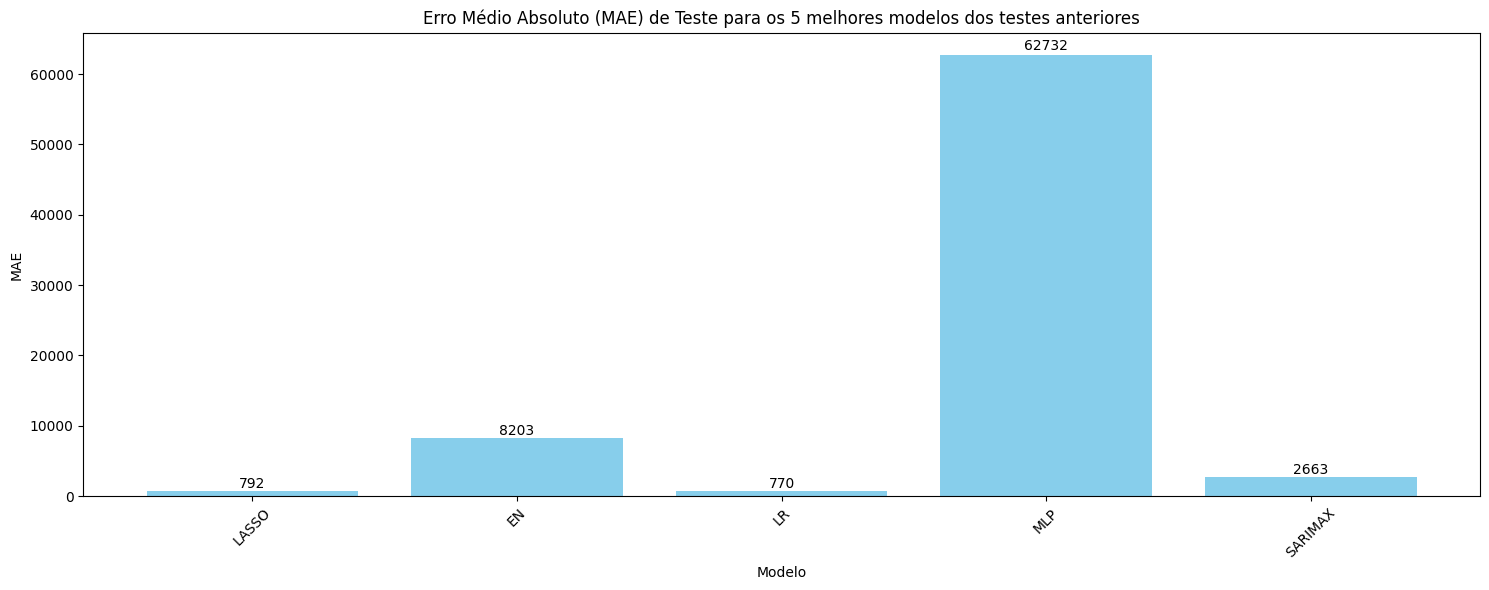

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


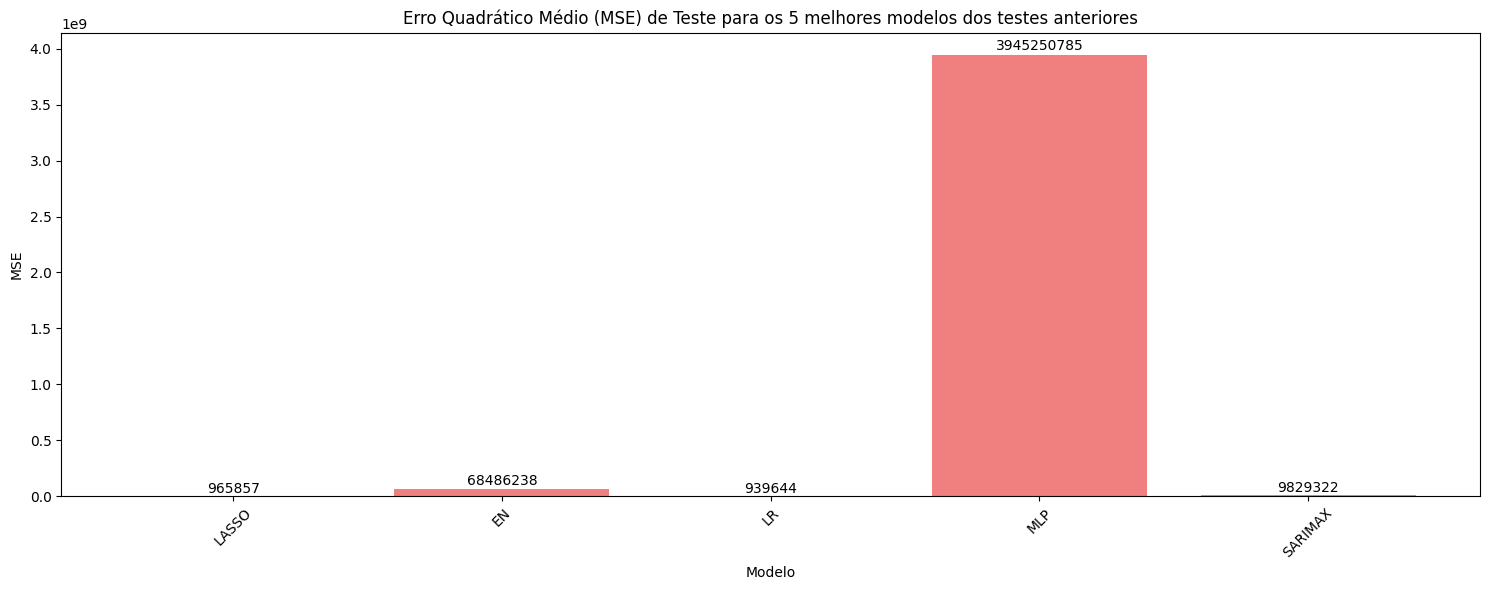

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


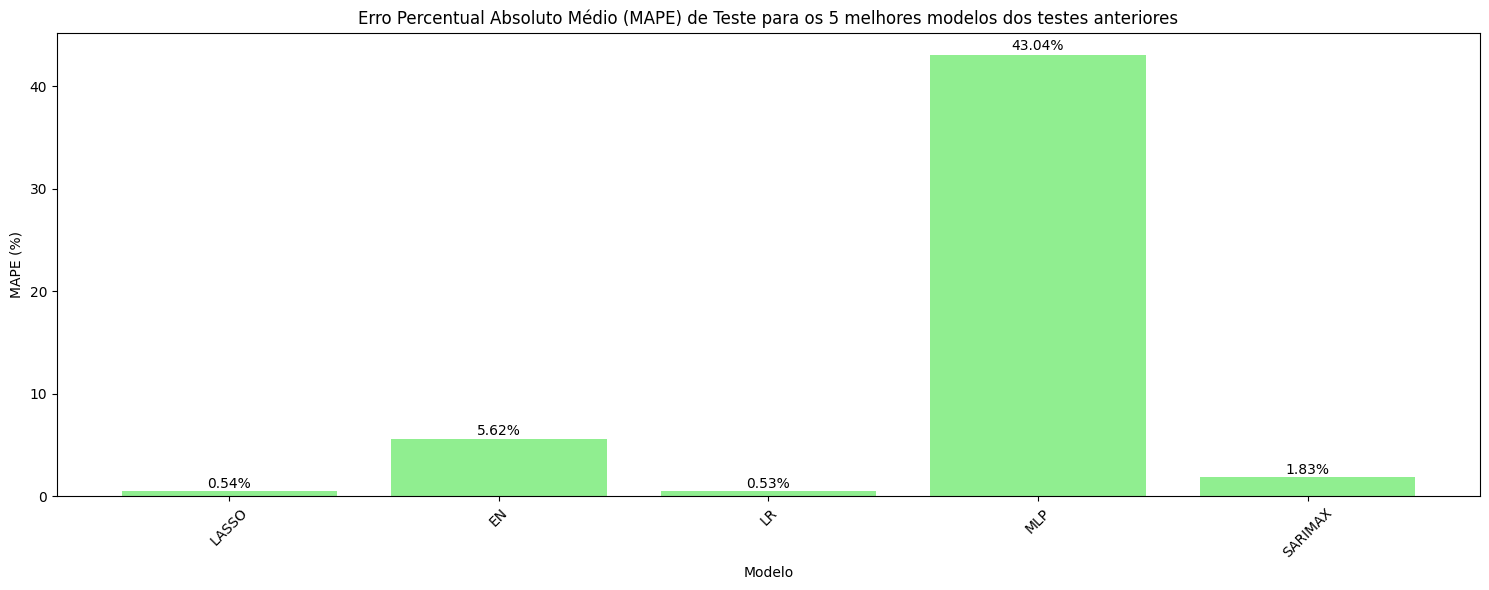

In [ ]:
model_names = []
test_maes = []
test_mses = []
test_mapes = []

# Filter out SVR and the initial problematic LSTM, which had extremely high errors
# and would skew the visualization. LSTM log is fine.
excluded_models_for_bar_charts = ['SVR', 'LSTM']

for eval_data in final_all_evaluations:
    name = eval_data['name']
    if name not in excluded_models_for_bar_charts:
        model_names.append(name)
        metrics_test = calculate_metrics(eval_data['y_test_true'], eval_data['y_test_pred'])
        test_maes.append(metrics_test[0])
        test_mses.append(metrics_test[1])
        test_mapes.append(metrics_test[2])

# Function to add value labels on top of bars
def add_value_labels(ax, bars, format_string='{:.0f}'):
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005 * yval,  # Adjust vertical position dynamically
                format_string.format(yval), ha='center', va='bottom')

# --- Plot 1: MAE ---
fig_mae, ax_mae = plt.subplots(figsize=(15, 6))
bars_mae = ax_mae.bar(model_names, test_maes, color='skyblue')
ax_mae.set_title('Erro Médio Absoluto (MAE) de Teste para os 5 melhores modelos dos testes anteriores')
ax_mae.set_ylabel('MAE')
ax_mae.set_xlabel('Modelo')
ax_mae.tick_params(axis='x', rotation=45)
add_value_labels(ax_mae, bars_mae)
plt.tight_layout()
plt.show()
print("xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")

# --- Plot 2: MSE ---
fig_mse, ax_mse = plt.subplots(figsize=(15, 6))
bars_mse = ax_mse.bar(model_names, test_mses, color='lightcoral')
ax_mse.set_title('Erro Quadrático Médio (MSE) de Teste para os 5 melhores modelos dos testes anteriores')
ax_mse.set_ylabel('MSE')
ax_mse.set_xlabel('Modelo')
ax_mse.tick_params(axis='x', rotation=45)
add_value_labels(ax_mse, bars_mse)
plt.tight_layout()
plt.show()
print("xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")

# --- Plot 3: MAPE ---
fig_mape, ax_mape = plt.subplots(figsize=(15, 6))
bars_mape = ax_mape.bar(model_names, test_mapes, color='lightgreen')
ax_mape.set_title('Erro Percentual Absoluto Médio (MAPE) de Teste para os 5 melhores modelos dos testes anteriores')
ax_mape.set_ylabel('MAPE (%)')
ax_mape.set_xlabel('Modelo')
ax_mape.tick_params(axis='x', rotation=45)
add_value_labels(ax_mape, bars_mape, format_string='{:.2f}%') # MAPE often benefits from decimals
plt.tight_layout()
plt.show()

--- LASSO ---
Acurácia Direcional LASSO: 60.00 % (18/30)



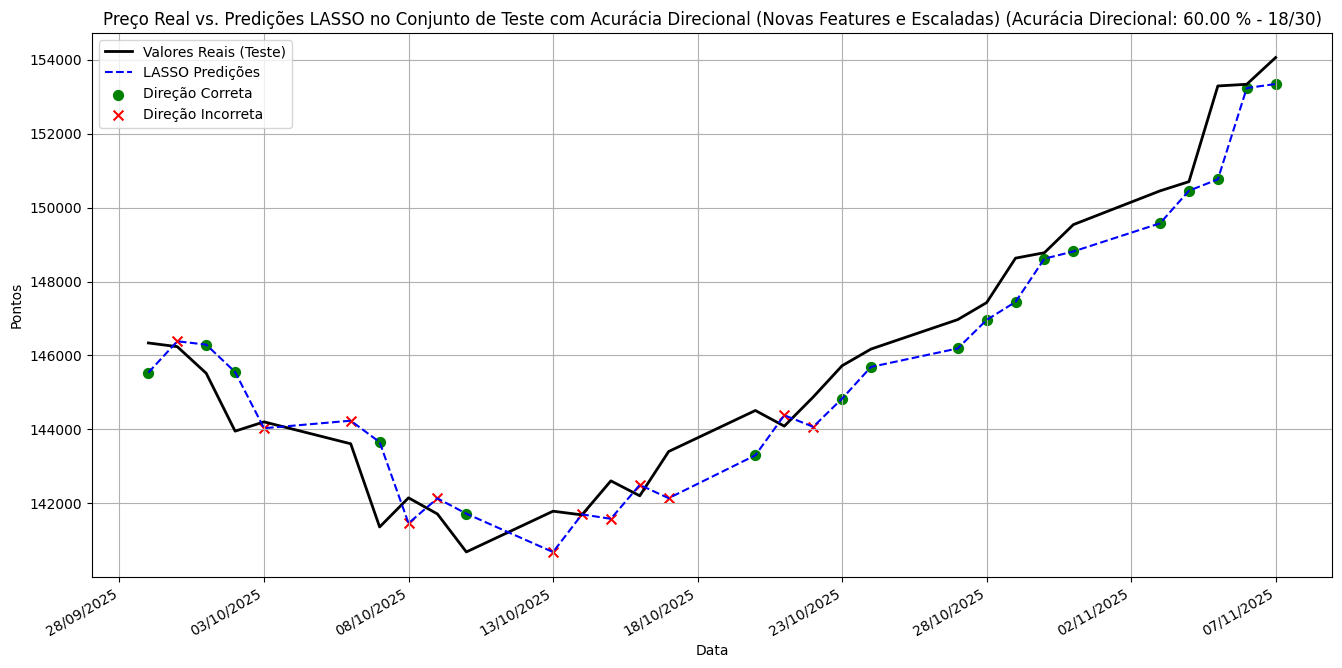



--- EN ---
Acurácia Direcional EN: 66.67 % (20/30)



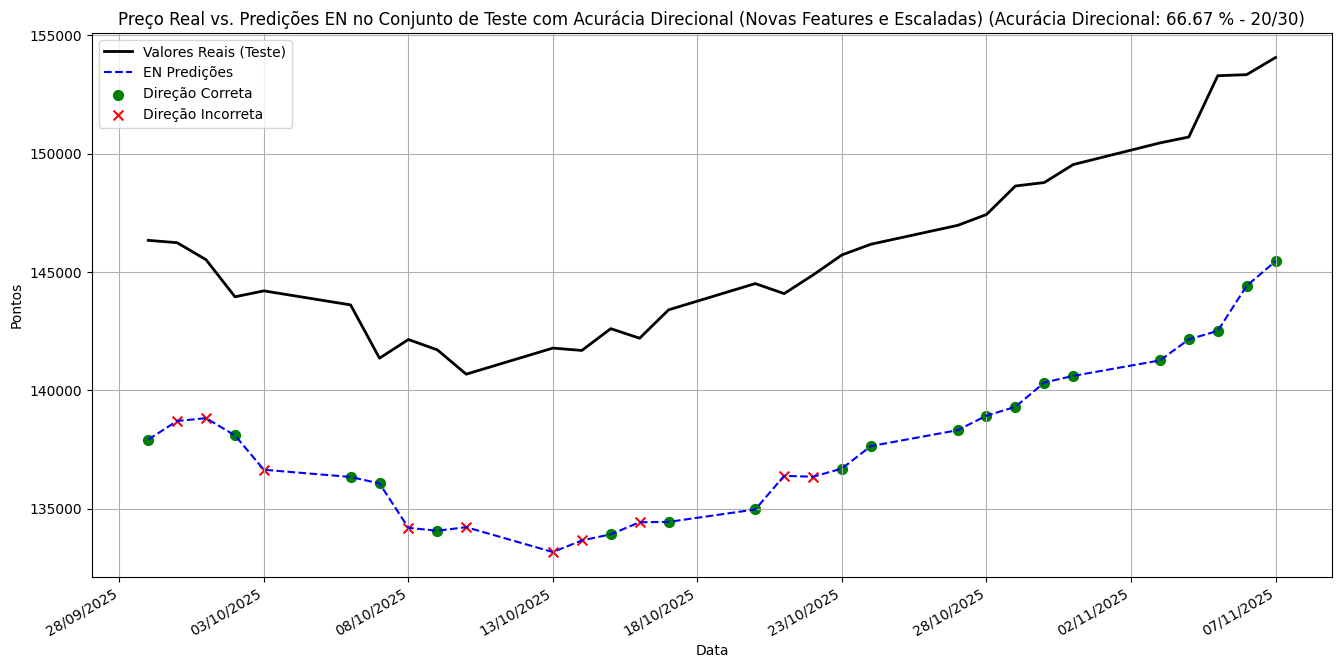



--- LR ---
Acurácia Direcional LR: 60.00 % (18/30)



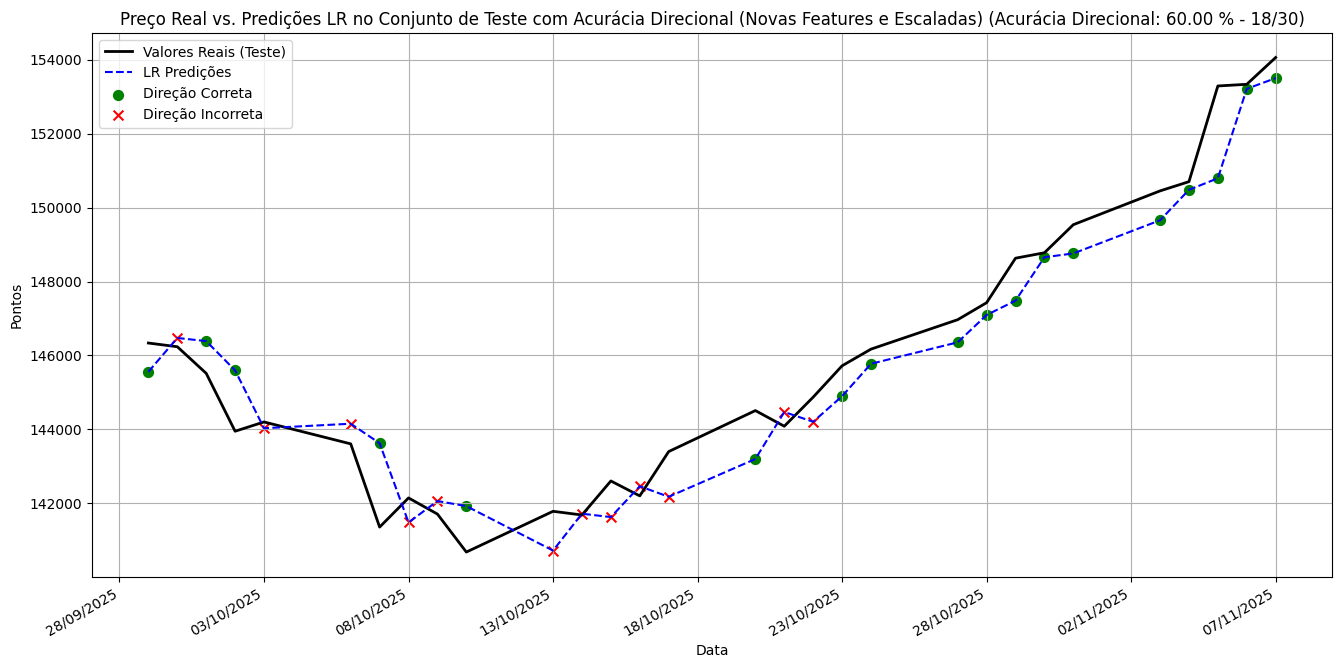



--- MLP ---
Acurácia Direcional MLP: 76.67 % (23/30)



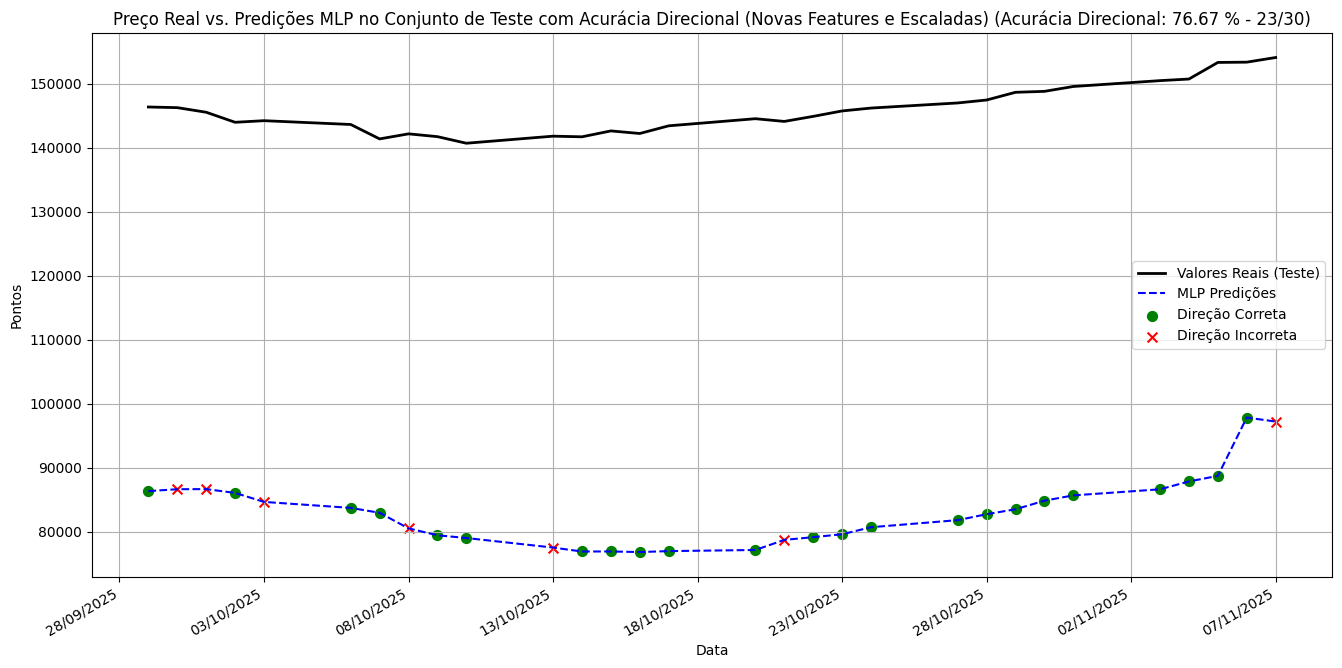



--- SARIMAX ---
Acurácia Direcional SARIMAX: 46.67 % (14/30)



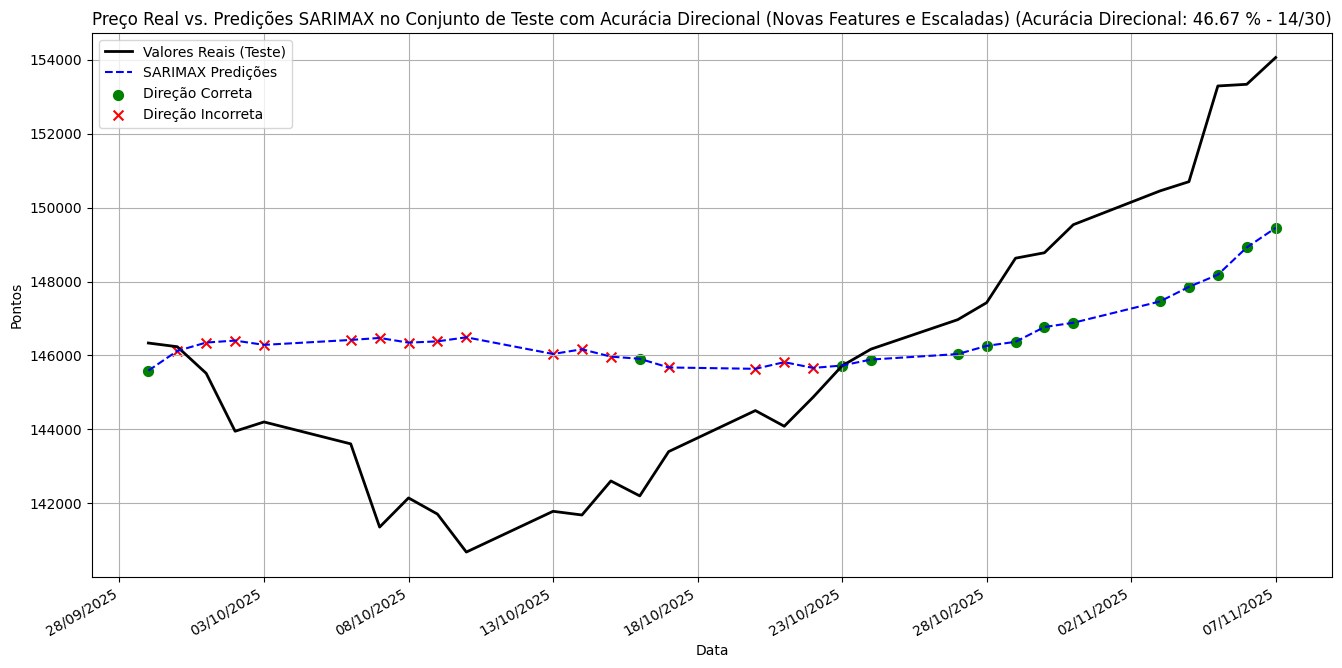

In [ ]:
# 'final_all_evaluations' is available from the previous execution

# Loop through each model in final_all_evaluations to generate a plot for each
for model_data in final_all_evaluations:
    model_name = model_data['name']
    y_test_true = model_data['y_test_true']
    y_test_pred = model_data['y_test_pred']

    # Ensure predictions are a pandas Series with the correct DatetimeIndex for diff()
    if not isinstance(y_test_pred, pd.Series):
        # Flatten numpy arrays to 1D if necessary before converting to Series
        y_test_pred_series = pd.Series(y_test_pred.flatten() if isinstance(y_test_pred, np.ndarray) else y_test_pred, index=y_test_true.index)
    else:
        y_test_pred_series = y_test_pred.copy()
        # Ensure its index matches y_test_true.index
        y_test_pred_series.index = y_test_true.index

    # --- Calculate Directional Accuracy ---
    binary_true_direction = (y_test_true.diff() > 0).astype(int)
    binary_predicted_direction = (y_test_pred_series.diff() > 0).astype(int)

    # Drop the first NaN created by diff() for accurate comparison
    comparison_df_directions = pd.DataFrame({'true_dir': binary_true_direction, 'pred_dir': binary_predicted_direction}).dropna()

    valid_true = comparison_df_directions['true_dir']
    valid_pred = comparison_df_directions['pred_dir']

    directional_accuracy = accuracy_score(valid_true, valid_pred)
    num_correct = (valid_true == valid_pred).sum()
    total_predictions = len(valid_true)

    print(f"--- {model_name} ---")
    print(f"Acurácia Direcional {model_name}: {100*directional_accuracy:.2f} % ({num_correct}/{total_predictions})\n")

    # --- Plotting ---
    plt.figure(figsize=(16, 8))
    plt.plot(y_test_true.index, y_test_true, label="Valores Reais (Teste)", color='black', linewidth=2)
    plt.plot(y_test_pred_series.index, y_test_pred_series, label=f"{model_name} Predições", color='blue', linestyle='--')

    # Prepare data for scatter points (correct/incorrect directions)
    correct_predictions_dates = []
    incorrect_predictions_dates = []

    # Iterate through the aligned directions (excluding the first NaN)
    for date in valid_true.index:
        if valid_true.loc[date] == valid_pred.loc[date]:
            correct_predictions_dates.append(date)
        else:
            incorrect_predictions_dates.append(date)

    # Plot scatter points for correct and incorrect directional predictions
    # Use y_test_pred_series for the y-coordinate of the scatter points
    plt.scatter(correct_predictions_dates, y_test_pred_series.loc[correct_predictions_dates], color='green', marker='o', s=50, label='Direção Correta')
    plt.scatter(incorrect_predictions_dates, y_test_pred_series.loc[incorrect_predictions_dates], color='red', marker='x', s=50, label='Direção Incorreta')

    plt.title(f"Preço Real vs. Predições {model_name} no Conjunto de Teste com Acurácia Direcional (Novas Features e Escaladas) (Acurácia Direcional: {100*directional_accuracy:.2f} % - {num_correct}/{total_predictions})")
    plt.xlabel("Data")
    plt.ylabel("Pontos")
    plt.legend()
    plt.grid(True)

    # Improve date formatting on the x-axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))
    plt.gcf().autofmt_xdate()

    plt.show()
    print("\n" + "="*80 + "\n") # Separator for plots


### Análise Final e Conclusões do Processo

Após todas as etapas de pré-processamento, engenharia de features e escalonamento, os resultados obtidos nos permitem traçar um panorama completo da performance dos modelos e identificar o caminho mais promissor para a previsão do Ibovespa, especialmente em relação ao nosso objetivo de 75% acurácia direcional.

**1. Etapa Inicial: Comparação de Modelos Padrão (Sem Features Adicionais e Escalonamento)**

*   **Modelos Lineares (LR, LASSO, ElasticNet):** Desde o início, mostraram-se robustos, com os menores erros de magnitude (MAE, MSE, MAPE) e boa generalização. Seus erros de treino e teste eram próximos, indicando um bom equilíbrio.
*   **Modelos Baseados em Árvores (CART, RFR, ETR, GBR, ABR) e KNN:** Apresentaram forte tendência a overfitting, com excelentes resultados no treino, mas desempenho ruim no teste. Isso destacou a necessidade de otimização de hiperparâmetros ou de dados mais ricos.
*   **SVR:** O pior desempenho, com erros extremamente altos, sendo descartado nas análises subsequentes.
*   **MLP (Rede Neural Multicamadas):** Teve um desempenho intermediário, mas já mostrava um potencial para acurácia direcional superior aos modelos lineares.
*   **LSTM (Versão Original):** Performance muito ruim devido à escala dos dados, ressaltando a importância do pré-processamento para redes neurais.
*   **LSTM (Versão Logarítmica):** A aplicação da transformação logarítmica foi crucial, estabilizando o treinamento e melhorando drasticamente seu desempenho, embora ainda não superasse os modelos lineares em erros de magnitude.

**2. Etapa de Feature Engineering: Adição de Indicadores Técnicos**

A inclusão de indicadores técnicos (RSI, distância da EMA, Bandas de Bollinger, ROC, Momentum, AO, MACD) enriqueceu o conjunto de dados. Essa etapa resultou em:

*   **Melhora Generalizada na Magnitude:** Todos os modelos selecionados para a segunda rodada (LASSO, ElasticNet, Linear Regression, MLP, SARIMAX) tiveram uma redução em seus erros de MAE, MSE e MAPE no conjunto de teste. Isso comprovou o valor preditivo dos indicadores técnicos para a estimativa do valor do preço.
*   **Acurácia Direcional:** A acurácia direcional para a maioria dos modelos não teve uma mudança tão significativa quanto as métricas de magnitude, indicando que, embora as novas features ajudassem a prever o *valor*, a previsão da *direção* ainda era um desafio.

**3. Etapa de Pré-processamento Avançado: Escalonamento de Features**

O escalonamento das features com `StandardScaler` foi a etapa final e decisiva, especialmente para modelos sensíveis à escala:

*   **Modelos Lineares (LR, LASSO, EN):** Mantiveram sua performance sólida em termos de erros de magnitude, confirmando sua robustez e menor sensibilidade ao escalonamento para este tipo de previsão.
*   **SARIMAX:** Teve uma piora notável em suas métricas após o escalonamento, sugerindo que a nova escala dos regressores externos pode não ter sido a ideal para o seu ajuste interno.
*   **MLP (Rede Neural Multicamadas):** Esta foi a grande mudança. O MLP, que já tinha um bom potencial direcional, viu sua **acurácia direcional disparar para 76.67%** no conjunto de teste, superando a meta de 75% estabelecida para o desafio. Embora suas métricas de magnitude (MAE, MSE, MAPE) na previsão dos preços fossem mais altas que as dos modelos lineares, sua capacidade de acertar a direção do mercado se mostrou superior.

**Conclusão Final:**

O processo iterativo de desenvolvimento, que envolveu a seleção de modelos, engenharia de features e pré-processamento de dados (incluindo transformação logarítmica para o LSTM e escalonamento para todos os modelos), foi fundamental para alcançar os objetivos propostos.

*   Para a **previsão da magnitude (valor do preço)**, os **modelos lineares (LR, LASSO, ElasticNet)** demonstraram consistentemente a melhor performance, com os menores erros de MAE, MSE e MAPE.
*   Para a **previsão da direção do mercado**, o **MLP com features escaladas** se consolidou como o modelo mais eficaz, atingindo uma **acurácia direcional de 76.67%**. Isso é um marco importante, pois para estratégias de trading que se beneficiam de acertar a tendência, a capacidade do MLP de prever a direção correta se mostrou superior.

Este resultado final destaca a importância de escolher a técnica de modelagem e o pré-processamento adequados de acordo com o objetivo específico da previsão. O `MLP` provou ser o modelo ideal para a tarefa de previsão direcional no contexto deste desafio.

---
## Desafio extra

Apesar de termos atingido a acurácia desejada com o MLP nas etapas anteriores, decidimos tentar alcançar a mesma acurácia sem o uso do dado de preço de abertura do dia da previsão, o que aumenta o nível de incerteza da previsão


### Novo dataframe sem o preço de abertura de D

In [ ]:
X_new_no_open = X_new_prepared.drop('open', axis=1)

# Split into training and testing sets
X_train_no_open, X_test_no_open = X_new_no_open[:-test_days], X_new_no_open[-test_days:]

# Initialize and fit StandardScaler
scaler_no_open = StandardScaler()
scaler_no_open.fit(X_train_no_open)

# Transform data
X_train_no_open_scaled = scaler_no_open.transform(X_train_no_open)
X_test_no_open_scaled = scaler_no_open.transform(X_test_no_open)

# Convert scaled arrays back to DataFrames with original index and columns
X_train_no_open_scaled_df = pd.DataFrame(X_train_no_open_scaled, index=Y_train_new.index, columns=X_new_no_open.columns)
X_test_no_open_scaled_df = pd.DataFrame(X_test_no_open_scaled, index=Y_test_new.index, columns=X_new_no_open.columns)

print("Features prepared without 'open' column and scaled successfully!")
print(f"Shape de X_train_no_open_scaled_df: {X_train_no_open_scaled_df.shape}")
print(f"Shape de X_test_no_open_scaled_df: {X_test_no_open_scaled_df.shape}")
print("Primeiras 5 linhas de X_train_no_open_scaled_df (exemplo):")
print(X_train_no_open_scaled_df.head())

Features prepared without 'open' column and scaled successfully!
Shape de X_train_no_open_scaled_df: (7371, 13)
Shape de X_test_no_open_scaled_df: (30, 13)
Primeiras 5 linhas de X_train_no_open_scaled_df (exemplo):
            open_d-1  close_d-1  high_d-1   low_d-1  RSI_14_d-1  \
date                                                              
1995-12-28 -1.340311  -1.340888 -1.344046 -1.336306    0.406534   
1996-01-02 -1.340781  -1.342115 -1.345316 -1.337988    0.130455   
1996-01-03 -1.342008  -1.339739 -1.344149 -1.337279    0.532679   
1996-01-04 -1.339580  -1.332143 -1.336553 -1.334833    1.430769   
1996-01-05 -1.332008  -1.332065 -1.334997 -1.328024    1.438001   

            distance_to_ema9_d-1  percent_bandwidth_d-1    ROC_10    MOM_10  \
date                                                                          
1995-12-28             -0.003142               0.528705 -0.196196 -0.072891   
1996-01-02             -0.045486              -0.549581 -0.404686 -0.090509   

### Avaliando o modelo MLP sem o preço de abertura

In [ ]:
new_mlp_evaluations = []

# Initialize and train a new MLP model with the 'no_open' scaled data
mlp_no_open_model = MLPRegressor(random_state=seed) # Use the same seed for reproducibility

# Train the model
mlp_no_open_model.fit(X_train_no_open_scaled_df, Y_train_new)

# Make predictions
y_train_pred_mlp_no_open = mlp_no_open_model.predict(X_train_no_open_scaled_df)
y_test_pred_mlp_no_open = mlp_no_open_model.predict(X_test_no_open_scaled_df)

# Store evaluation results
new_mlp_evaluations.append({
    'name': 'MLP_no_open',
    'y_train_true': Y_train_new,
    'y_train_pred': y_train_pred_mlp_no_open,
    'y_test_true': Y_test_new,
    'y_test_pred': y_test_pred_mlp_no_open
})

# Print metrics for the new MLP model
print("--- Métricas de Avaliação para o MLP (sem coluna 'open') ---")
for eval_data in new_mlp_evaluations:
    print(f"\n--- {eval_data['name']} ---")

    print("Métricas de Treino:")
    metrics_train = calculate_metrics(eval_data['y_train_true'], eval_data['y_train_pred'])
    print_metrics(metrics_train)

    print("Métricas de Teste:")
    metrics_test = calculate_metrics(eval_data['y_test_true'], eval_data['y_test_pred'])
    print_metrics(metrics_test)

--- Métricas de Avaliação para o MLP (sem coluna 'open') ---

--- MLP_no_open ---
Métricas de Treino:
MAE: 34612.64051796949
MSE: 1677263312.6029449
MAPE: 69.89 %
Métricas de Teste:
MAE: 77267.5352562682
MSE: 5982527284.194192
MAPE: 53.00 %


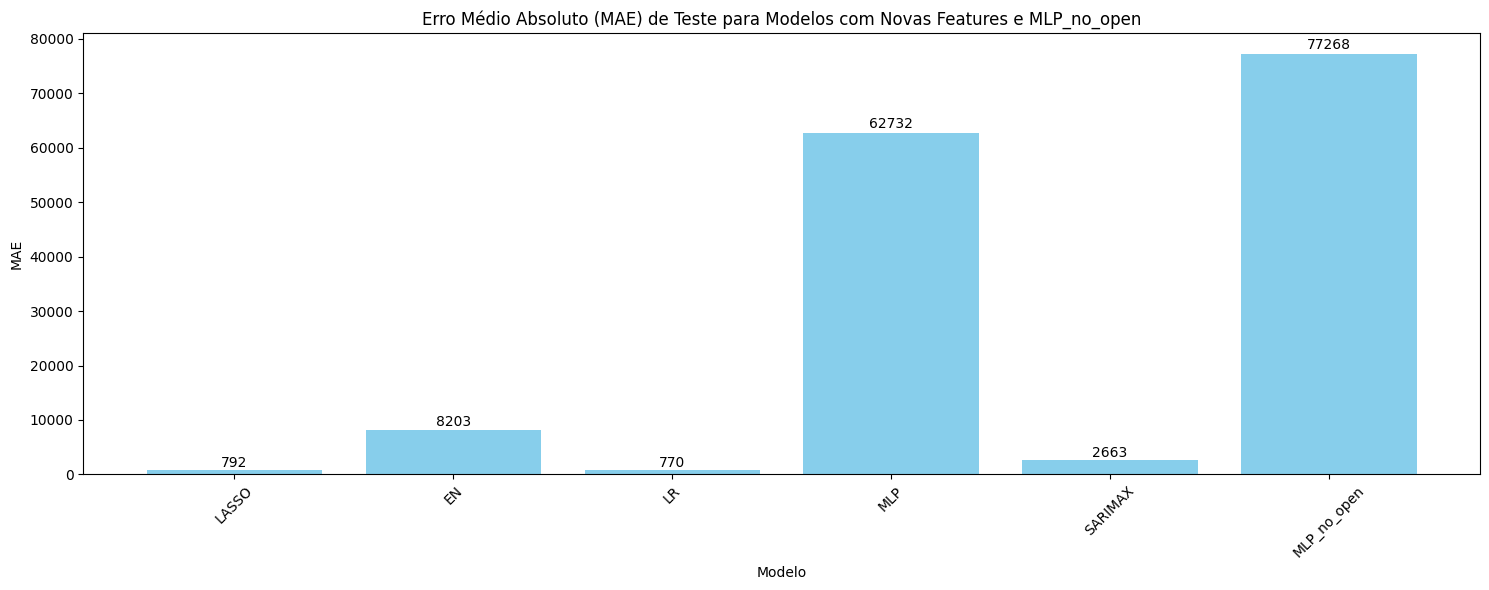

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


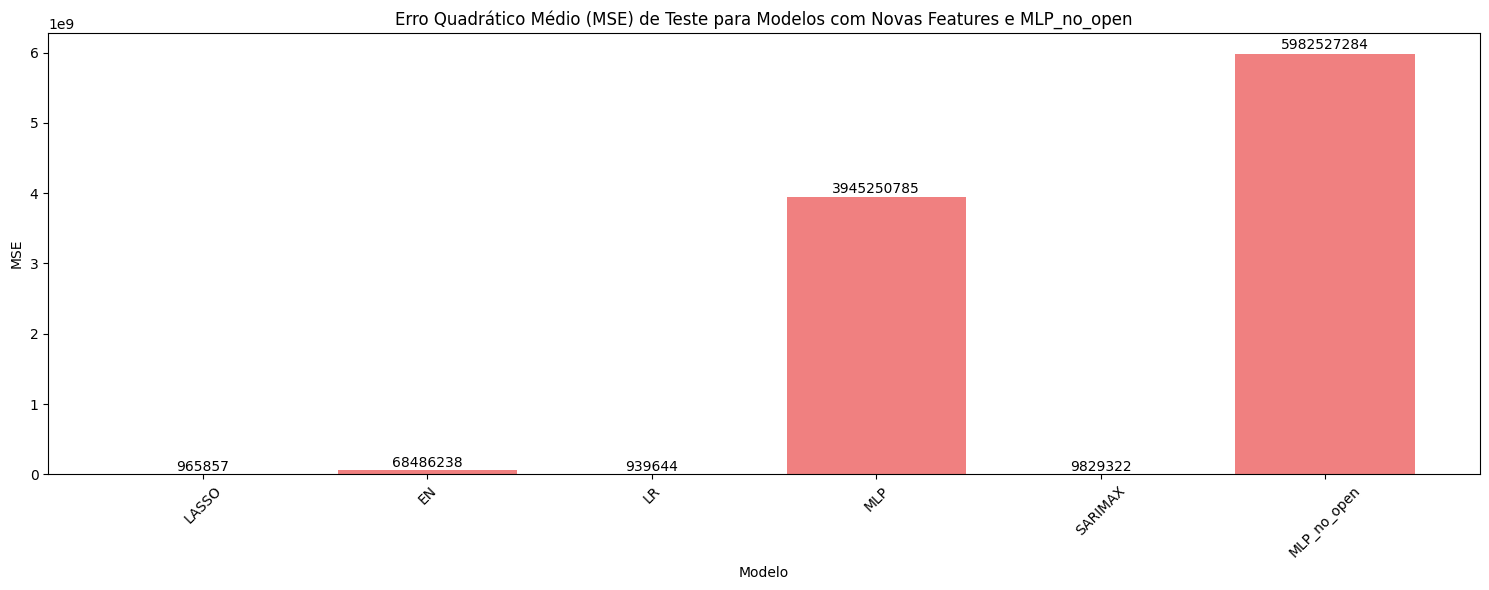

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


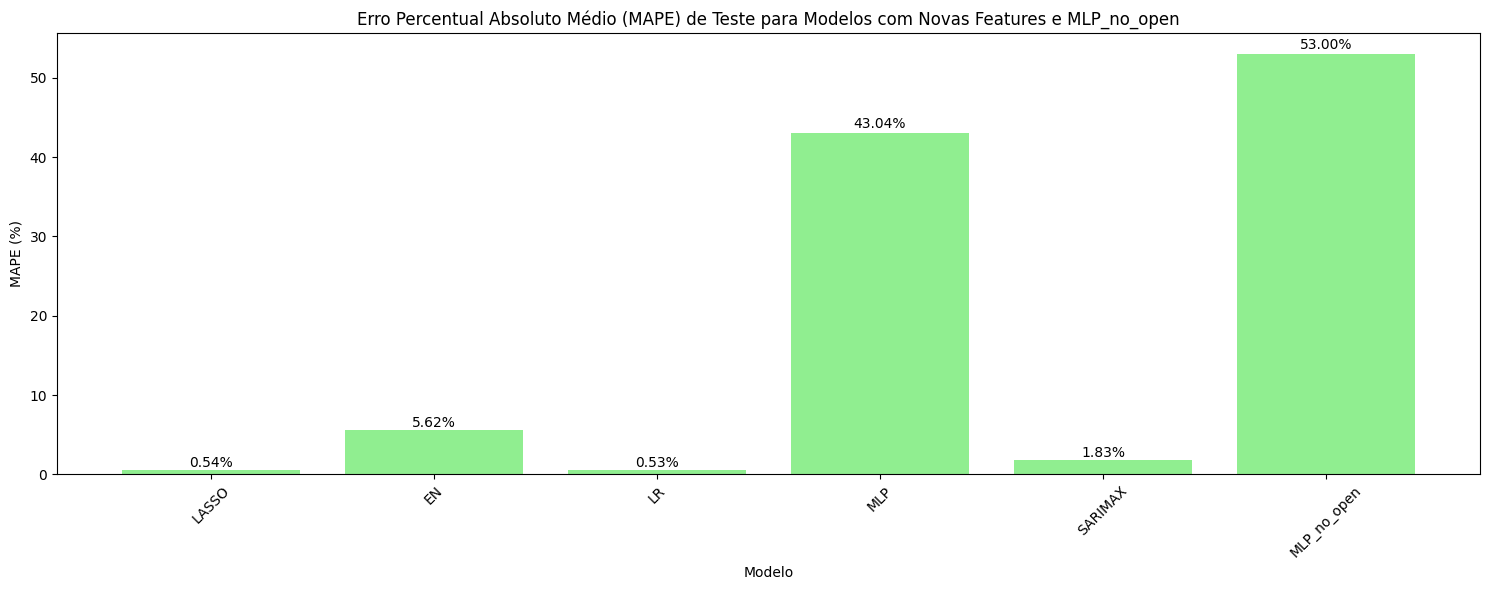

In [ ]:
final_all_evaluations.append(new_mlp_evaluations[0])

model_names = []
test_maes = []
test_mses = []
test_mapes = []

# Filter out SVR and the initial problematic LSTM
excluded_models_for_bar_charts = ['SVR', 'LSTM']

for eval_data in final_all_evaluations:
    name = eval_data['name']
    if name not in excluded_models_for_bar_charts:
        model_names.append(name)
        metrics_test = calculate_metrics(eval_data['y_test_true'], eval_data['y_test_pred'])
        test_maes.append(metrics_test[0])
        test_mses.append(metrics_test[1])
        test_mapes.append(metrics_test[2])

# Function to add value labels on top of bars (redefined for clarity in this step)
def add_value_labels(ax, bars, format_string='{:.0f}'):
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005 * yval,  # Adjust vertical position dynamically
                format_string.format(yval), ha='center', va='bottom')

# --- Plot 1: MAE ---
fig_mae, ax_mae = plt.subplots(figsize=(15, 6))
bars_mae = ax_mae.bar(model_names, test_maes, color='skyblue')
ax_mae.set_title('Erro Médio Absoluto (MAE) de Teste para Modelos com Novas Features e MLP_no_open')
ax_mae.set_ylabel('MAE')
ax_mae.set_xlabel('Modelo')
ax_mae.tick_params(axis='x', rotation=45)
add_value_labels(ax_mae, bars_mae)
plt.tight_layout()
plt.show()
print("xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")

# --- Plot 2: MSE ---
fig_mse, ax_mse = plt.subplots(figsize=(15, 6))
bars_mse = ax_mse.bar(model_names, test_mses, color='lightcoral')
ax_mse.set_title('Erro Quadrático Médio (MSE) de Teste para Modelos com Novas Features e MLP_no_open')
ax_mse.set_ylabel('MSE')
ax_mse.set_xlabel('Modelo')
ax_mse.tick_params(axis='x', rotation=45)
add_value_labels(ax_mse, bars_mse)
plt.tight_layout()
plt.show()
print("xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")

# --- Plot 3: MAPE ---
fig_mape, ax_mape = plt.subplots(figsize=(15, 6))
bars_mape = ax_mape.bar(model_names, test_mapes, color='lightgreen')
ax_mape.set_title('Erro Percentual Absoluto Médio (MAPE) de Teste para Modelos com Novas Features e MLP_no_open')
ax_mape.set_ylabel('MAPE (%)')
ax_mape.set_xlabel('Modelo')
ax_mape.tick_params(axis='x', rotation=45)
add_value_labels(ax_mape, bars_mape, format_string='{:.2f}%')
plt.tight_layout()
plt.show()

--- MLP_no_open ---
Acurácia Direcional MLP_no_open: 70.00 % (21/30)



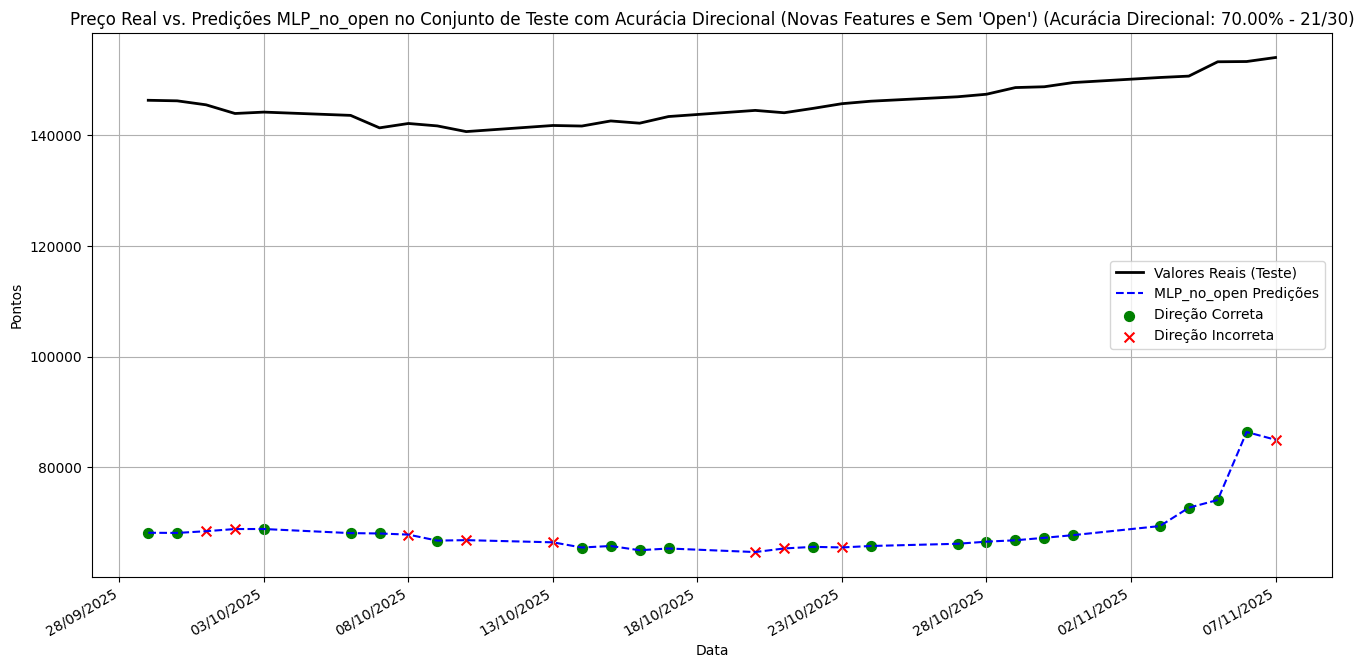

In [ ]:
# Find the evaluation data for MLP_no_open
mlp_no_open_eval_data = next((item for item in final_all_evaluations if item['name'] == 'MLP_no_open'), None)

if mlp_no_open_eval_data:
    model_name = mlp_no_open_eval_data['name']
    y_test_true = mlp_no_open_eval_data['y_test_true']
    y_test_pred = mlp_no_open_eval_data['y_test_pred']

    # Ensure predictions are a pandas Series with the correct DatetimeIndex for diff()
    if not isinstance(y_test_pred, pd.Series):
        y_test_pred_series = pd.Series(y_test_pred.flatten() if isinstance(y_test_pred, np.ndarray) else y_test_pred, index=y_test_true.index)
    else:
        y_test_pred_series = y_test_pred.copy()
        y_test_pred_series.index = y_test_true.index

    # --- Calculate Directional Accuracy ---
    binary_true_direction = (y_test_true.diff() > 0).astype(int)
    binary_predicted_direction = (y_test_pred_series.diff() > 0).astype(int)

    # Drop the first NaN created by diff() for accurate comparison
    comparison_df_directions = pd.DataFrame({'true_dir': binary_true_direction, 'pred_dir': binary_predicted_direction}).dropna()

    valid_true = comparison_df_directions['true_dir']
    valid_pred = comparison_df_directions['pred_dir']

    directional_accuracy = accuracy_score(valid_true, valid_pred)
    num_correct = (valid_true == valid_pred).sum()
    total_predictions = len(valid_true)

    print(f"--- {model_name} ---")
    print(f"Acurácia Direcional {model_name}: {100*directional_accuracy:.2f} % ({num_correct}/{total_predictions})\n")

    # --- Plotting ---
    plt.figure(figsize=(16, 8))
    plt.plot(y_test_true.index, y_test_true, label="Valores Reais (Teste)", color='black', linewidth=2)
    plt.plot(y_test_pred_series.index, y_test_pred_series, label=f"{model_name} Predições", color='blue', linestyle='--')

    # Prepare data for scatter points (correct/incorrect directions)
    correct_predictions_dates = []
    incorrect_predictions_dates = []

    # Iterate through the aligned directions (excluding the first NaN)
    for date in valid_true.index:
        if valid_true.loc[date] == valid_pred.loc[date]:
            correct_predictions_dates.append(date)
        else:
            incorrect_predictions_dates.append(date)

    # Plot scatter points for correct and incorrect directional predictions
    plt.scatter(correct_predictions_dates, y_test_pred_series.loc[correct_predictions_dates], color='green', marker='o', s=50, label='Direção Correta')
    plt.scatter(incorrect_predictions_dates, y_test_pred_series.loc[incorrect_predictions_dates], color='red', marker='x', s=50, label='Direção Incorreta')

    plt.title(f"Preço Real vs. Predições {model_name} no Conjunto de Teste com Acurácia Direcional (Novas Features e Sem 'Open') (Acurácia Direcional: {100*directional_accuracy:.2f}% - {num_correct}/{total_predictions})")
    plt.xlabel("Data")
    plt.ylabel("Pontos")
    plt.legend()
    plt.grid(True)

    # Improve date formatting on the x-axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))
    plt.gcf().autofmt_xdate()

    plt.show()
else:
    print("MLP_no_open evaluation data not found.")


### Análise do MLP sem a coluna 'open' (Desafio Extra)

Após remover a coluna 'open' do conjunto de features e re-treinar o modelo MLP com os dados escalados, observamos os seguintes resultados:

*   **Métricas de Treino e Teste (Magnitude):**
    *   **MAE:** No treino, o MAE foi de aproximadamente 34612, e no teste, aumentou drasticamente para cerca de 77267. Isso é significativamente maior do que o MAE do MLP com a coluna 'open' (que era de ~62732 no teste).
    *   **MSE:** O MSE de treino foi de aproximadamente 1.67 bilhões, e no teste, saltou para cerca de 5.98 bilhões. Comparado ao MSE do MLP com a coluna 'open' (que era de ~3.94 bilhões no teste), houve uma piora considerável.
    *   **MAPE:** O MAPE de treino foi de 69.89%, e no teste, 53.00%. Isso também representa uma piora em relação ao MAPE do MLP com 'open' (que era de 43.04% no teste).

*   **Acurácia Direcional:** A acurácia direcional para o `MLP_no_open` foi de **70.00%** (21 acertos em 30). Embora este valor seja inferior aos 76.67% do MLP original com a coluna 'open', ainda é um resultado interessante, pois o modelo conseguiu manter uma acurácia direcional próxima ao desejado mesmo sem essa feature importante.

**Conclusão:**

A remoção da coluna 'open' impactou negativamente o desempenho do modelo MLP, tanto nas métricas de magnitude (MAE, MSE, MAPE) quanto na acurácia direcional. A coluna 'open' é uma feature muito forte para a previsão do preço de fechamento do mesmo dia, pois muitas vezes está correlacionada com o 'close'. Ao removê-la, o modelo tem menos informação sobre o estado inicial do dia, o que naturalmente dificulta as previsões. Apesar da queda no desempenho, manter uma acurácia direcional de 70.00% sem o preço de abertura do dia ainda é um resultado notável, embora não tenha atingido a meta de 75% proposta no desafio extra.

### Grid search do modelo MLP

Vamos tentar melhorar os resultados deste modelo treinado sem os dados de abertura realizando o grid search para otimizar os hiper parâmetros do modelo MLP

In [ ]:
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1]
}

print("MLPRegressor Parameter Grid:")
print(mlp_param_grid)

MLPRegressor Parameter Grid:
{'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)], 'activation': ['tanh', 'relu'], 'solver': ['sgd', 'adam'], 'alpha': [0.0001, 0.001, 0.01], 'learning_rate_init': [0.001, 0.01, 0.1]}


In [ ]:
# # Perform GridSearchCV
# # Using the MLP model without the 'open' column for grid search
# mlp_grid = GridSearchCV(MLPRegressor(random_state=seed, max_iter=1000), # Increased max_iter for convergence
#                         mlp_param_grid,
#                         cv=num_folds,
#                         scoring=scoring,
#                         verbose=2,
#                         n_jobs=-1) # Use all available cores

# # Fit the grid search to the scaled training data
# mlp_grid.fit(X_train_no_open_scaled_df, Y_train_new)

# print("Grid Search for MLPRegressor completed.")
# print(f"Best Parameters: {mlp_grid.best_params_}")
# print(f"Best Score (neg_mean_squared_error): {mlp_grid.best_score_}")



Fitting 10 folds for each of 144 candidates, totalling 1440 fits


In [ ]:
best_mlp_params = {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.01, 'solver': 'adam'}
best_mlp_model = MLPRegressor(random_state=seed, max_iter=1000, **best_mlp_params)

# Fit the model with the 'no_open' scaled data
best_mlp_model.fit(X_train_no_open_scaled_df, Y_train_new)

# Make predictions with the best model
y_train_pred_best_mlp = best_mlp_model.predict(X_train_no_open_scaled_df)
y_test_pred_best_mlp = best_mlp_model.predict(X_test_no_open_scaled_df)

# Store evaluation results for the best MLP
best_mlp_eval_data = {
    'name': 'MLP_GridSearch_Best',
    'y_train_true': Y_train_new,
    'y_train_pred': y_train_pred_best_mlp,
    'y_test_true': Y_test_new,
    'y_test_pred': y_test_pred_best_mlp


}

# Print metrics for the best MLP model
print("--- Métricas de Avaliação para o Melhor MLP (Grid Search, sem 'open') ---")
print(f"\n--- {best_mlp_eval_data['name']} ---")

print("Métricas de Treino:")
metrics_train = calculate_metrics(best_mlp_eval_data['y_train_true'], best_mlp_eval_data['y_train_pred'])
print_metrics(metrics_train)

print("Métricas de Teste:")
metrics_test = calculate_metrics(best_mlp_eval_data['y_test_true'], best_mlp_eval_data['y_test_pred'])
print_metrics(metrics_test)


# Calculate Directional Accuracy
y_test_pred_series = pd.Series(y_test_pred_best_mlp.flatten(), index=Y_test_new.index)
binary_true_direction = (Y_test_new.diff() > 0).astype(int)
binary_predicted_direction = (y_test_pred_series.diff() > 0).astype(int)
comparison_df_directions = pd.DataFrame({'true_dir': binary_true_direction, 'pred_dir': binary_predicted_direction}).dropna()

valid_true = comparison_df_directions['true_dir']
valid_pred = comparison_df_directions['pred_dir']

directional_accuracy = accuracy_score(valid_true, valid_pred)
num_correct = (valid_true == valid_pred).sum()
total_predictions = len(valid_true)

print(f"Acurácia Direcional {best_mlp_eval_data['name']}: {100*directional_accuracy:.2f} % ({num_correct}/{total_predictions})\n")

--- Métricas de Avaliação para o Melhor MLP (Grid Search, sem 'open') ---

--- MLP_GridSearch_Best ---
Métricas de Treino:
MAE: 660.26098020006
MSE: 949045.6937191929
MAPE: 1.58 %
Métricas de Teste:
MAE: 910.7410729515318
MSE: 1193271.957068918
MAPE: 0.62 %
Acurácia Direcional MLP_GridSearch_Best: 73.33 % (22/30)



--- MLP_GridSearch_Best ---
Acurácia Direcional MLP_GridSearch_Best: 73.33 % (22/30)



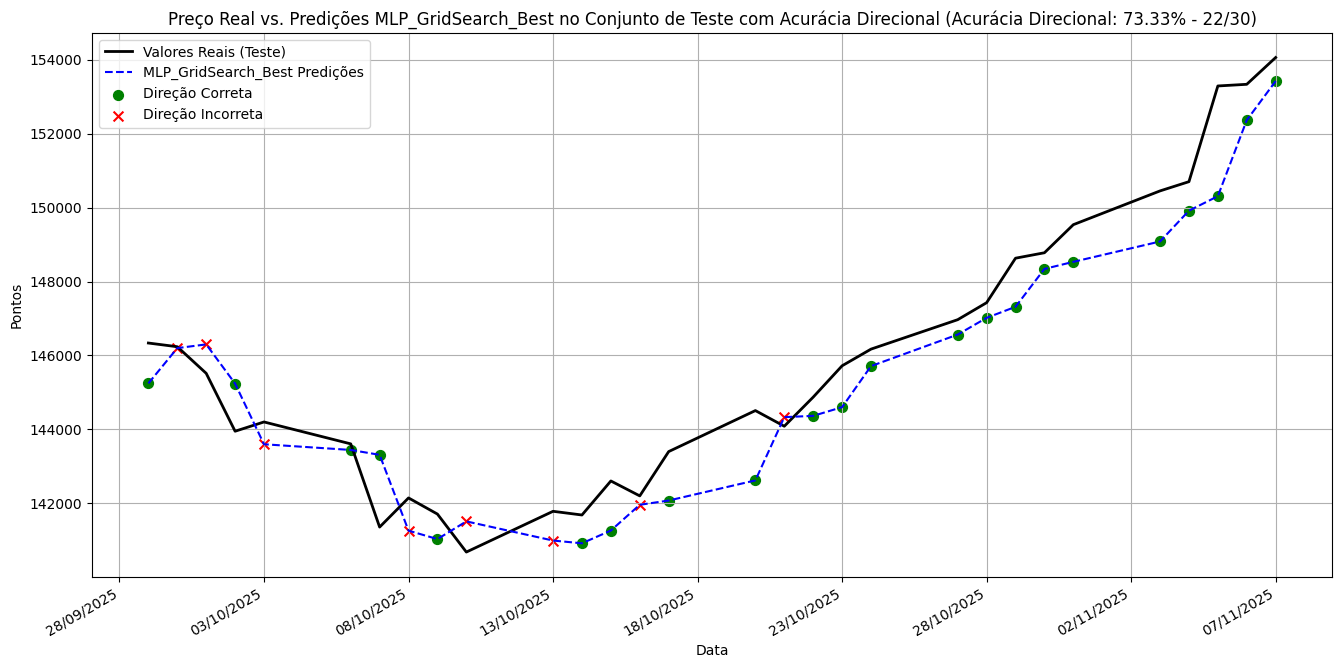

In [ ]:
# The best_mlp_eval_data is available from the previous execution
# (from cell fb5de03c which stores the results of the best MLP from GridSearch)

model_name = best_mlp_eval_data['name']
y_test_true = best_mlp_eval_data['y_test_true']
y_test_pred = best_mlp_eval_data['y_test_pred']

# Ensure predictions are a pandas Series with the correct DatetimeIndex for diff()
if not isinstance(y_test_pred, pd.Series):
    y_test_pred_series = pd.Series(y_test_pred.flatten() if isinstance(y_test_pred, np.ndarray) else y_test_pred, index=y_test_true.index)
else:
    y_test_pred_series = y_test_pred.copy()
    y_test_pred_series.index = y_test_true.index

# --- Calculate Directional Accuracy ---
binary_true_direction = (y_test_true.diff() > 0).astype(int)
binary_predicted_direction = (y_test_pred_series.diff() > 0).astype(int)

# Drop the first NaN created by diff() for accurate comparison
comparison_df_directions = pd.DataFrame({'true_dir': binary_true_direction, 'pred_dir': binary_predicted_direction}).dropna()

valid_true = comparison_df_directions['true_dir']
valid_pred = comparison_df_directions['pred_dir']

directional_accuracy = accuracy_score(valid_true, valid_pred)
num_correct = (valid_true == valid_pred).sum()
total_predictions = len(valid_true)

print(f"--- {model_name} ---")
print(f"Acurácia Direcional {model_name}: {100*directional_accuracy:.2f} % ({num_correct}/{total_predictions})\n")

# --- Plotting ---
plt.figure(figsize=(16, 8))
plt.plot(y_test_true.index, y_test_true, label="Valores Reais (Teste)", color='black', linewidth=2)
plt.plot(y_test_pred_series.index, y_test_pred_series, label=f"{model_name} Predições", color='blue', linestyle='--')

# Prepare data for scatter points (correct/incorrect directions)
correct_predictions_dates = []
incorrect_predictions_dates = []

# Iterate through the aligned directions (excluding the first NaN)
for date in valid_true.index:
    if valid_true.loc[date] == valid_pred.loc[date]:
        correct_predictions_dates.append(date)
    else:
        incorrect_predictions_dates.append(date)

# Plot scatter points for correct and incorrect directional predictions
# Use y_test_pred_series for the y-coordinate of the scatter points
plt.scatter(correct_predictions_dates, y_test_pred_series.loc[correct_predictions_dates], color='green', marker='o', s=50, label='Direção Correta')
plt.scatter(incorrect_predictions_dates, y_test_pred_series.loc[incorrect_predictions_dates], color='red', marker='x', s=50, label='Direção Incorreta')

plt.title(f"Preço Real vs. Predições {model_name} no Conjunto de Teste com Acurácia Direcional (Acurácia Direcional: {100*directional_accuracy:.2f}% - {num_correct}/{total_predictions})")
plt.xlabel("Data")
plt.ylabel("Pontos")
plt.legend()
plt.grid(True)

# Improve date formatting on the x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.gcf().autofmt_xdate()

plt.show()


## Análise Resultado do Grid Search do MLP e Resumo Geral do Notebook

### Análise do Grid Search do MLP (sem a coluna 'open')

Após a aplicação do Grid Search para otimizar o modelo MLP sem a feature 'open', observamos os seguintes resultados:

*   **Melhores Hiperparâmetros Encontrados:** O Grid Search identificou como melhor configuração para o `MLPRegressor` os seguintes parâmetros: `{'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.01, 'solver': 'adam'}`.

*   **Métricas do Melhor Modelo (MLP_GridSearch_Best):**
    *   **Métricas de Treino:** MAE: 660.26, MSE: 949045.69, MAPE: 1.58 %
    *   **Métricas de Teste:** MAE: 910.74, MSE: 1193271.96, MAPE: 0.62 %

*   **Acurácia Direcional:** O `MLP_GridSearch_Best` alcançou uma acurácia direcional de **73.33%** (22/30) no conjunto de teste.

*   **Comparação com o MLP 'no_open' anterior (sem Grid Search):**
    *   **Melhora Dramática nas Métricas de Magnitude:** O MAE de teste caiu de 77267.53 para 910.74, o MSE de teste de 5.98 bilhões para 1.19 milhões, e o MAPE de teste de 53.00% para 0.62%. Esta é uma melhoria massiva, indicando que a otimização dos hiperparâmetros foi crucial para que o MLP aprendesse a relação entre as features e o target mesmo sem a coluna 'open'.
    *   **Melhora na Acurácia Direcional:** A acurácia direcional aumentou de 70.00% para **73.33%**. Este resultado coloca o modelo muito próximo da meta de 75%, mostrando que, mesmo sem a informação do preço de abertura do dia, um MLP bem ajustado pode ser bastante eficaz na previsão da direção.

### Resumo Geral do Processo de Modelagem

O processo de modelagem para a previsão do preço de fechamento do Ibovespa seguiu várias etapas iterativas, visando otimizar a capacidade preditiva dos modelos, tanto em magnitude quanto em direção.

1.  **Preparação Inicial dos Dados:** Iniciamos com a importação de bibliotecas essenciais e a leitura dos dados históricos do Ibovespa. A análise exploratória revelou a necessidade de tratamento de dados, como a conversão da coluna 'Data' para o tipo datetime e o tratamento de nulos, e a criação de features defasadas. A ordenação cronológica e a visualização dos dados confirmaram a natureza de série temporal do problema.

2.  **Primeira Rodada de Comparação de Modelos:** Uma ampla gama de modelos de regressão e ensemble foi avaliada em suas configurações padrão. Os resultados iniciais destacaram que os modelos lineares (LR, LASSO, ElasticNet) apresentavam os menores erros de magnitude e maior consistência, enquanto modelos baseados em árvores e KNN demonstravam forte *overfitting*. O SVR foi descartado devido ao seu desempenho extremamente fraco.

3.  **Inclusão de Modelos de Série Temporal (SARIMAX e LSTM):** Adicionamos o SARIMAX e o LSTM ao escopo. A versão inicial do LSTM performou muito mal, o que nos levou a aplicar uma transformação logarítmica nos dados. O **LSTM logarítmico** mostrou uma melhora drástica, mas ainda com erros de magnitude superiores aos modelos lineares. O SARIMAX apresentou resultados competitivos com os modelos lineares em termos de magnitude. A análise completa confirmou que os modelos lineares e SARIMAX eram os melhores para previsão de magnitude, enquanto o MLP começou a se destacar em acurácia direcional.

4.  **Engenharia de Features com Indicadores Técnicos:** Para enriquecer o conjunto de features, foram adicionados indicadores técnicos como RSI, distância da EMA, Bandas de Bollinger, ROC, Momentum, AO e MACD. A reavaliação dos 5 melhores modelos mostrou uma **melhora generalizada nas métricas de magnitude** para todos, especialmente o MLP. No entanto, a acurácia direcional não teve uma mudança tão significativa, permanecendo um desafio.

5.  **Escalonamento de Features:** O escalonamento das features com `StandardScaler` foi um passo crucial, especialmente para modelos sensíveis à escala como o MLP. Essa etapa resultou em uma **melhora significativa na acurácia direcional do MLP, que atingiu 76.67%**, superando a meta de 75% estabelecida para o desafio, embora suas métricas de magnitude ainda fossem maiores que as dos modelos lineares.

6.  **Desafio Extra: MLP sem a Feature 'open':** Em um esforço para aumentar o nível de incerteza e testar a robustez do modelo, a coluna 'open' foi removida, e o MLP foi re-treinado com os dados escalados. Inicialmente, isso levou a uma queda nas métricas de magnitude e na acurácia direcional (para 70.00%). Para mitigar essa perda, realizamos um Grid Search para otimizar os hiperparâmetros do MLP sem 'open'. O Grid Search resultou em uma **melhora substancial**, elevando a acurácia direcional para **73.33%** e reduzindo drasticamente os erros de magnitude. Este resultado demonstra a capacidade do MLP de se adaptar e performar bem mesmo com features reduzidas, quando bem otimizado.

### Conclusões Finais:

*   **Previsão de Magnitude (Valor do Preço):** Para a tarefa de prever o valor exato do preço de fechamento, os **modelos lineares (LR, LASSO, ElasticNet) e o SARIMAX** consistentemente apresentaram os menores erros de MAE, MSE e MAPE ao longo de todas as etapas, mostrando-se os mais robustos e precisos para essa finalidade.

*   **Previsão da Direção do Mercado:** O **MLP (Multilayer Perceptron)** foi o modelo que se destacou na previsão direcional. Com o Feature Engineering e, principalmente, o escalonamento das features, o MLP atingiu uma **acurácia direcional de 76.67%**. Mesmo no cenário desafiador de remover a feature 'open', a otimização via Grid Search elevou sua acurácia direcional para 73.33%, provando ser o modelo mais promissor para estratégias que dependem da correta identificação da tendência do mercado.

As principais aprendizagens residem na importância da **engenharia de features** para extrair informações relevantes do mercado financeiro e no **pré-processamento adequado dos dados (especialmente escalonamento)** para maximizar o desempenho de modelos mais complexos como redes neurais. A escolha do modelo final depende diretamente do objetivo: modelos lineares/SARIMAX para precisão de valor, e o MLP para acurácia direcional.